# Laden des Datensatzes
In der folgenden Minichallenge will ich mit dem Datensatz `SVHN` arbeiten, der eine Sammlung von Bildern von Hausnummern von Google Street View enthält. Ziel ist es die Bilder zu klassifizieren und die Ziffern zu erkennen.

In [15]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import random

from torch.utils.tensorboard import SummaryWriter
import os

import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score

# Transformieren der Bilder in Tensoren und Normalisieren
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

In [16]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

g = torch.Generator()
g.manual_seed(SEED)

In [17]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [18]:
# Laden des SVHN-Datensatzes
train_dataset = torchvision.datasets.SVHN(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.SVHN(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

print(len(train_dataset))
print(len(test_dataset))

Using downloaded and verified file: ./data\train_32x32.mat
Using downloaded and verified file: ./data\test_32x32.mat
73257
26032


In [19]:
# DataLoader erstellen
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    generator=g
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    generator=g
)

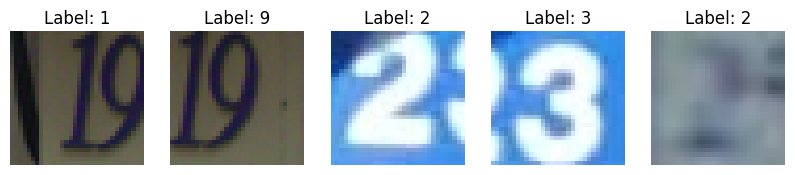

In [20]:
# Bilder anzeigen mit ihren Labels
plt.figure(figsize=(10, 2))

for i in range(5):
    image, label = train_dataset[i]

    # Denormalisieren für die Anzeige
    image = image.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5 

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(f'Label: {label}')
    plt.axis('off')

plt.show()

# Explorative Datenanalyse
Zuerst soll der Datensatz kurz analysiert werden, um ein besseres Verständnis für die Daten zu bekommen. Dazu wird die Anzahl der Bilder, die Verteilung der Klassen und details in den Bildern untersucht.

In [21]:
# Anzahl der Bilder und Bildgrösse
print("Anzahl Trainingsbilder:", len(train_dataset))
print("Anzahl Testbilder:", len(test_dataset))

image, label = train_dataset[0]

print("Bildgrösse:", image.shape)

Anzahl Trainingsbilder: 73257
Anzahl Testbilder: 26032
Bildgrösse: torch.Size([3, 32, 32])


## Anzahl Bilder
Der Datensatz enthält insgesamt 73.257 Bilder im Trainingsset und 26.032 Bilder im Testset. Die Bilder haben dabei eine Grösse von 32x32 Pixeln und sind in RGB-Farben dargestellt.

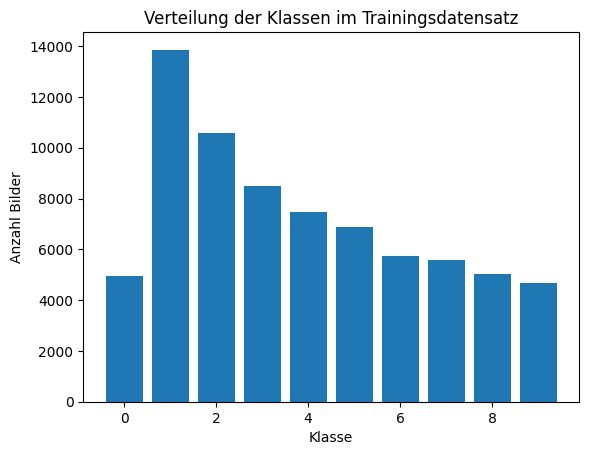

In [22]:
# Klassenverteilung
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
unique_labels, counts = np.unique(labels, return_counts=True)

plt.bar(unique_labels, counts)
plt.xlabel('Klasse')
plt.ylabel('Anzahl Bilder')
plt.title('Verteilung der Klassen im Trainingsdatensatz')
plt.show()

## Klassenverteilung
In der Klassenverteilung sieht man, dass die Klasse 1 am häufigsten vorkommt und danach absteigend die anderen Klassen. Dies ergibt durchaus Sinn, wenn man bedenkt woher die Bilder stammen. Hausnummern beginnen meistens bei 1 und bei danach werden die Zahlen immer seltener, da es zwar oft Hausnummern mit 11 oder 12 gibt aber selten eine 99 oder 100. Diese Imbalance könnte sich negativ auf die Performance des Modells auswirken. Es könnte deshalb im späteren verlauf auch sinnvoll sein mehr auf Metriken wie den F1-Score zu achten, da dieser die Imbalance besser berücksichtigt als die Accuracy.

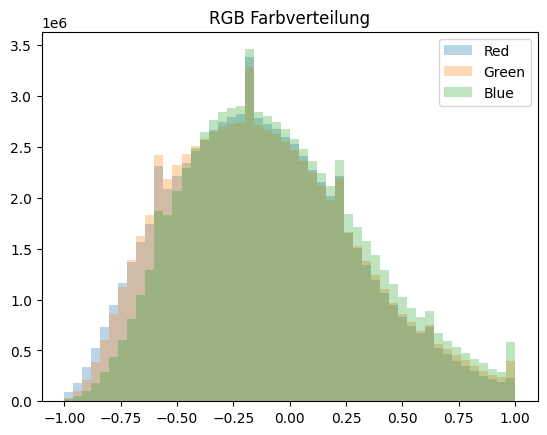

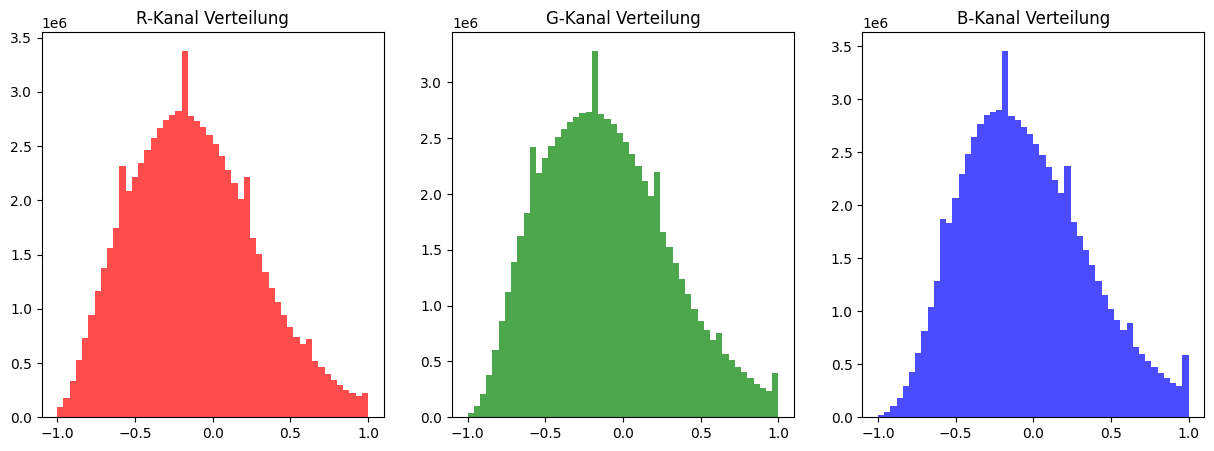

In [23]:
# Farbverteilung
all_pixels = []

for i in range(len(train_dataset)):
    img, _ = train_dataset[i]
    all_pixels.append(img.numpy())

all_pixels = np.concatenate(all_pixels, axis=1)

r = all_pixels[0].flatten()
g_channel = all_pixels[1].flatten()
b = all_pixels[2].flatten()

plt.hist(r, bins=50, alpha=0.3, label="Red")
plt.hist(g_channel, bins=50, alpha=0.3, label="Green")
plt.hist(b, bins=50, alpha=0.3, label="Blue")

plt.legend()
plt.title("RGB Farbverteilung")
plt.show()

# Detailplots für jede Farbe
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(r, bins=50, color='red', alpha=0.7)
plt.title("R-Kanal Verteilung")
plt.subplot(1, 3, 2)
plt.hist(g_channel, bins=50, color='green', alpha=0.7)
plt.title("G-Kanal Verteilung")
plt.subplot(1, 3, 3)
plt.hist(b, bins=50, color='blue', alpha=0.7)
plt.title("B-Kanal Verteilung")
plt.show()

## Farbverteilung
Die Bilder sind in RGB-Farben dargestellt, was bedeutet, dass jedes Bild aus drei Kanälen besteht: Rot, Grün und Blau. In der Darstellung der einzelnen Kanäle ist gut zu sehen, dass diese auf allen Kanälen relativ gleichmässig verteilt sind. Es gibt keine auffälligen Farbdominanzen.

## Identifizierte Probleme
- Es gibt eine Klassenimbalance, da die Klasse 1 am häufigsten vorkommt und danach absteigend die anderen Klassen. Dies könnte sich negativ auf die Performance des Modells auswirken.
- Einige Bilder beinhalten mehrere Ziffern. Diese sind dann etwas anders Zentriert und danach jeweils einzel gelabelt. So ist Beispielsweise ein Bild mit einer 19 zuerst mit einer 1 gelabelt und danach mit einer 9. Dies könnte es dem Modell erschweren die Ziffern zu erkennen, da diese nicht immer an der selben Stelle im Bild sind.
- Da die Bilder von Street View stammen, gibt es teilweise auch Bilder mit schlechter Qualität, beispielsweise durch schlechte Beleuchtung oder Unschärfe. Dies könnte es dem Modell erschweren die Ziffern zu erkennen, da diese teilweise schwer zu erkennen sind.

# Definieren der Evaluation Metriken
Um die Performance des Modells zu bewerten, werden folgende Metriken definiert:

Accuracy: Die Accuracy gibt an, wie viele der vorhergesagten Klassen korrekt sind.  
Formel: $\text{Accuracy} = \frac{\text{Anzahl der korrekt vorhergesagten Klassen}}{\text{Gesamtanzahl der Vorhersagen}}$

Precision: Die Precision gibt an, wie viele der vorhergesagten Klassen tatsächlich zur jeweiligen Klasse gehören.  
Formel: $\text{Precision} = \frac{\text{Anzahl der korrekt vorhergesagten Klassen}}{\text{Anzahl der vorhergesagten Klassen}} = \frac{TP}{TP + FP}$

Recall: Der Recall gibt an, wie viele der tatsächlichen Klassen korrekt vorhergesagt wurden.  
Formel: $\text{Recall} = \frac{\text{Anzahl der korrekt vorhergesagten Klassen}}{\text{Anzahl der tatsächlichen Klassen}} = \frac{TP}{TP + FN}$

F1-Score: Der F1-Score ist das Mittel von Precision und Recall und gibt eine ausgewogene Bewertung der Performance des Modells.  
Formel: $\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$

# Deep Learning Pipeline

## Baslinemodellierung
Das Baselinemodell besteht aus einem Convolutional Network, dass Zuerst ein Convolutional Layer mit 32 Filtern und einer Kernelgrösse von 3x3 hat, gefolgt von einer ReLU-Aktivierungsfunktion und einer einfachen Max-Pooling-Schicht. Danach folgt ein weiteres Convolutional Layer mit 64 Filtern und einer Kernelgrösse von 3x3, gefolgt von einer ReLU-Aktivierungsfunktion und einer Max-Pooling-Schicht. Die beiden Convolutional Layer haben jeweils ein Padding von 1, um die räumlichen Dimensionen der Bilder beizubehalten.

Im Anschluss folgt ein Fully Connected Layer mit 128 Neuronen und einer ReLU-Aktivierungsfunktion. Im Forward wird dann zuerst das Convolutional Layer und danach das Fully Connected Layer aufgerufen. Dies könnte auch gemeinsam in der Initialisierung gemacht werden, ich selbst finde es aber in dieser Form übersichtlicher.

In [24]:
class BaselineCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),        # 3 Input-Kanäle (RGB), 32 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),       # 32 Input-Kanäle (von vorheriger Schicht), 64 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),                       # Flacht 3D-Tensor ab
            nn.Linear(64*8*8,128),              # 64*8*8 Eingabekanäle, 128 Ausgabekanäle   
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):

        x = self.conv(x)                        # Durchlaufen der Convolutional Layers
        x = self.fc(x)                          # Durchlaufen der Fully Connected Layers

        return x

## Definieren des Trainingsprozesses
In `train_epoch` wird der Trainingsprozess definiert. Als eingabe muss das Modell, der Loader, der Optimizer sowie die Lossfunktion übergeben werden. Zudem wird auch das Gerät übergeben, damit die Daten und das Modell auf die GPU geladen werden können. In der Funktion werden dann jeweils die einzelnen Batches durchlaufen, die Daten auf die GPU geladen, danach wird ein Forward Pass gemacht. Danach wird der Loss berechnet, und ein Backward Pass gemacht, um die Gewichte zu aktualisieren. Am Ende der Funktion wird die durchschnittliche Loss über alle Batches zurückgegeben und die Accuracy über alle Batches berechnet und zurückgegeben.

In [25]:
def train_epoch(model, loader, optimizer, criterion, device, writer=None, epoch=0, clip_grad=False):

    model.train()       # Model wird in Trainingsmodus versetzt

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:       # Durchlaufen jedes Batches

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()           # Alte Gradienten werden zurückgesetzt auf 0

        outputs = model(images)         # Forward Pass durch das Modell

        loss = criterion(outputs, labels)   # Berechnen des Loss

        loss.backward()         # Backward Pass: Berechnen der Gradienten

        if clip_grad:           # Optionales Gradienten-Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()        # Updaten der Gewichte

        total_loss += loss.item()   # Loss zum totalen Loss hinzufügen

        preds = outputs.argmax(1)   # Vorhersagen durch Auswahl der Klasse mit höchster Wahrscheinlichkeit

        correct += (preds == labels).sum().item()   # Anzahl korrekter Vorhersagen
        total += labels.size(0)     # Gesamtanzahl der Bilder

    acc = correct / total       # Berechnen der Genauigkeit

    if writer:
        writer.add_scalar('Train/Loss', total_loss/len(loader), epoch)
        writer.add_scalar('Train/Accuracy', acc, epoch)

    return total_loss/len(loader), acc

## Definieren des Evaluationsprozesses
In `evaluate` wird der Evaluationsprozess definiert. Als eingabe muss wie beim training auch das Modell, der Loader, die Lossfunktion und das Gerät übergeben werden. In der Funktion werden dann die einzelnen Batches durchlaufen, die Daten auf die GPU geladen, danach wird ein Forward Pass gemacht. Der Unterschied zum Training ist, dass hier kein Backward Pass gemacht wird und auch keine Gewichte aktualisiert werden. Aber es werden zusätzlich zum Loss und der Accuracy auch die Precision, der Recall und der F1-Score berechnet und zurückgegeben. Am Ende der Funktion wird die durchschnittliche Loss über alle Batches zurückgegeben und die Accuracy, Precision, Recall und F1-Score über alle Batches berechnet und zurückgegeben. 

In [26]:
def evaluate(model, loader, criterion, device, writer=None, epoch=0):

    model.eval()            # Model wird in Evaluationsmodus versetzt

    total_loss = 0
    correct = 0
    total = 0

    all_preds = []   # Liste für alle Vorhersagen
    all_labels = []  # Liste für alle wahren Labels

    with torch.no_grad():   # Deaktivieren der Gradientenberechnung

        for images, labels in loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)     # Forward Pass durch das Modell

            loss = criterion(outputs, labels)   # Berechnen des Loss

            total_loss += loss.item()

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())   # Vorhersagen sammeln für spätere Analyse
            all_labels.extend(labels.cpu().numpy())  # Wahre Labels sammeln für spätere Analyse

    acc = correct / total

    # Precision, Recall, F1-Score
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    if writer:
        writer.add_scalar('Test/Loss', total_loss/len(loader), epoch)
        writer.add_scalar('Test/Accuracy', acc, epoch)
        writer.add_scalar('Test/Precision', precision, epoch)
        writer.add_scalar('Test/Recall', recall, epoch)
        writer.add_scalar('Test/F1', f1, epoch)

    return total_loss/len(loader), acc, precision, recall, f1

## Model Setup
Nachfolgend wird das Model definiert. Zuerst wird die GPU als Device eingeführt. Das CNN wird erstellt, die Loss Funktion definiert, ein SGD-Optimizer mit bestimmter learning Rate erstellt

In [27]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

model = BaselineCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.01)

cuda


## Overfitting
Im ersten Teil wird das Modell nur auf einem einzigen Bild trainiert, um zu sehen, ob es in der Lage ist, dieses Bild korrekt zu klassifizieren.

Im Anschluss soll das gleich noch mit einem kleinen Datensatz von einem Batch von 32 Bildern gemacht werden. Auch hier ist das Ziel, dass das Modell overfittet und die Bilder korrekt klassifiziert.

OVERFITTING TEST: Ein Sample


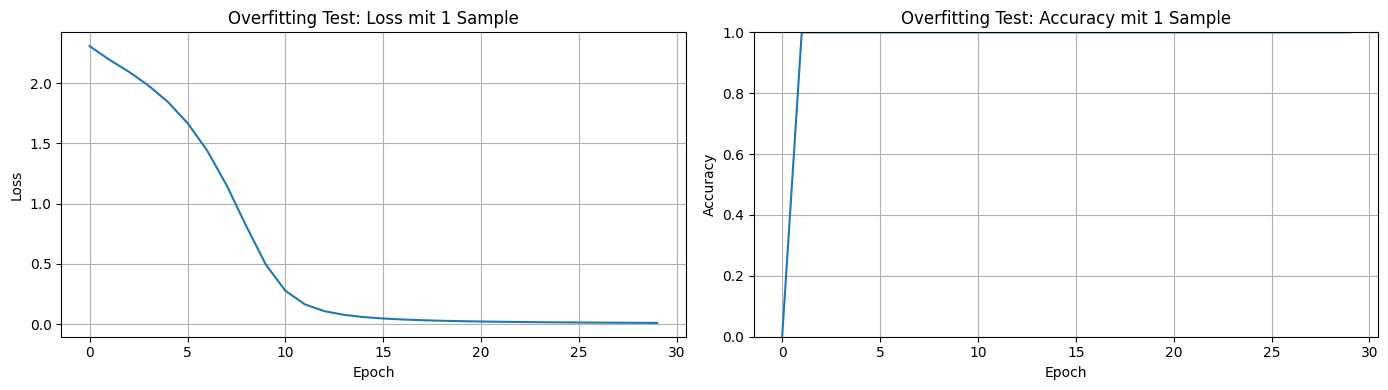

Finaler Loss mit 1 Sample: 0.0098
Finale Accuracy mit 1 Sample: 1.0000


In [28]:
# Overfit Test: Trainiere nur auf einem Sample
print("=" * 50)
print("OVERFITTING TEST: Ein Sample")
print("=" * 50)

model_test = BaselineCNN().to(device)
optimizer_test = optim.SGD(model_test.parameters(), lr=0.01)

# Einen Sample nehmen
sample_image, sample_label = train_dataset[0]
sample_image = sample_image.unsqueeze(0)
sample_label = torch.tensor([sample_label])

# DataLoader für das Sample erstellen
from torch.utils.data import TensorDataset
sample_dataset = TensorDataset(sample_image, sample_label)
sample_loader = DataLoader(sample_dataset, batch_size=1, shuffle=False, generator=g)

# Mit diesem einen Sample für viele Epochen trainieren
test_epochs = 30
test_losses = []
test_accs = []

for epoch in range(test_epochs):
    loss, acc= train_epoch(model_test, sample_loader, optimizer_test, criterion, device)
    test_losses.append(loss)
    test_accs.append(acc)

# Visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(test_losses)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Overfitting Test: Loss mit 1 Sample")
axes[0].grid()

axes[1].plot(test_accs)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Overfitting Test: Accuracy mit 1 Sample")
axes[1].grid()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"Finaler Loss mit 1 Sample: {test_losses[-1]:.4f}")
print(f"Finale Accuracy mit 1 Sample: {test_accs[-1]:.4f}")


OVERFITTING TEST: Ein Batch


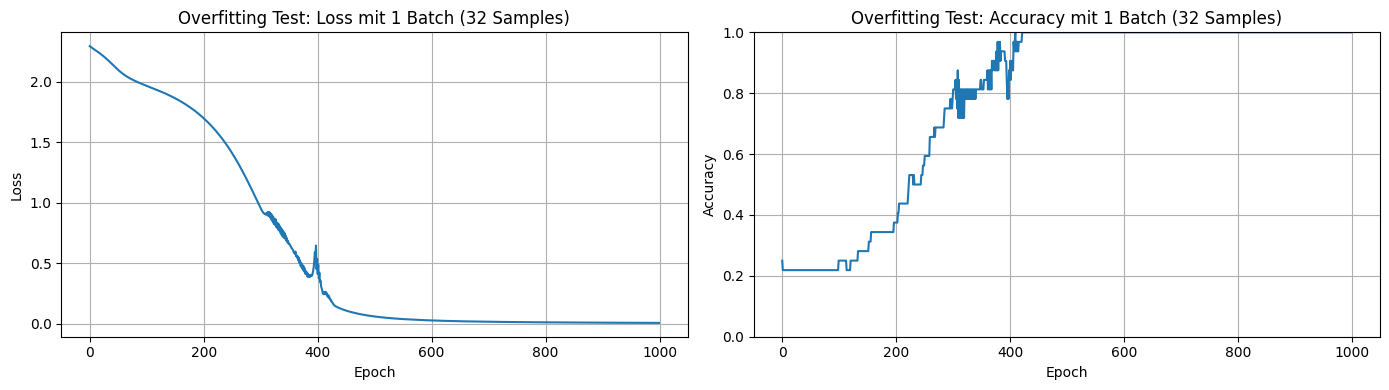

Finaler Loss mit 1 Batch: 0.0061
Finale Accuracy mit 1 Batch: 1.0000
Basisfunktionalität bestätigt: Model kann Daten überfitten


In [29]:
# Overfit Test: Trainiere nur auf einem Batch von 32 Samples
print("\n" + "=" * 50)
print("OVERFITTING TEST: Ein Batch")
print("=" * 50)

model_test = BaselineCNN().to(device)
optimizer_test = optim.SGD(model_test.parameters(), lr=0.01)
criterion_test = nn.CrossEntropyLoss()

# Einen Batch nehmen
batch_images, batch_labels = next(iter(DataLoader(train_dataset, batch_size=32)))

# DataLoader für den Batch erstellen
batch_dataset = TensorDataset(batch_images, batch_labels)
batch_loader = DataLoader(batch_dataset, batch_size=32, shuffle=False, generator=g)

test_epochs = 1000
test_losses_batch = []
test_accs_batch = []

for epoch in range(test_epochs):
    loss, acc = train_epoch(model_test, batch_loader, optimizer_test, criterion, device)
    test_losses_batch.append(loss)
    test_accs_batch.append(acc)

# Visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(test_losses_batch)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Overfitting Test: Loss mit 1 Batch (32 Samples)")
axes[0].grid()

axes[1].plot(test_accs_batch)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Overfitting Test: Accuracy mit 1 Batch (32 Samples)")
axes[1].grid()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"Finaler Loss mit 1 Batch: {test_losses_batch[-1]:.4f}")
print(f"Finale Accuracy mit 1 Batch: {test_accs_batch[-1]:.4f}")
print("Basisfunktionalität bestätigt: Model kann Daten überfitten")

Es ist in beiden Fällen (1 Bild und 32 Bilder) gut zu sehen, dass das Modell in der Lage ist, die Bilder korrekt zu klassifizieren. Bei einem Bild ist die Accuracy bereits nach zwei Epochen bei 100%. Bei einem Batch von 32 Bildern dauert es etwas länger, dort werden etwa 400 Epochen benötigt um eine Accuracy von 100% zu erreichen. Es zeigt aber gut auf, dass das Modell in der Lage ist zu overfitten und die Bilder korrekt zu klassifizieren, wenn es genügend Zeit hat.

# Hyperparameter Tuning

Systematische Evaluation von Learning Rates und Batch Sizes ohne automatische Hyperparameter-Suche.

## Parameter Grid:
Als Hyperparameter werden folgende Werte definiert:
- Learning Rates: [0.1, 0.01, 0.001]
- Batch Sizes: [32, 64, 128]
- Training: 30 Epochen pro Kombination
- Evaluation auf Testdatensatz

In [30]:
# Hyperparameter Tuning

learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 64, 128]
epochs = 30

# Dictionary für Ergebnisse speichern
results = {}

for lr in learning_rates:
    for bs in batch_sizes:
        writer = SummaryWriter(log_dir=f"./runs/baseline/baseline_lr{lr}_bs{bs}")
        print(f"\nTraining mit LR={lr}, Batch Size={bs}")
        print("-" * 40)
        
        # DataLoader mit aktueller Batch Size
        train_loader_tuning = DataLoader(
            train_dataset, 
            batch_size=bs, 
            shuffle=True,
            generator=g
        )
        test_loader_tuning = DataLoader(
            test_dataset, 
            batch_size=bs, 
            shuffle=False,
            generator=g
        )
        
        # Neues Modell
        model = BaselineCNN().to(device)
        optimizer = optim.SGD(model.parameters(), lr=lr)
        
        # Training
        train_losses = []
        train_accs = []
        test_losses = []
        test_accs = []
        test_precisions = []
        test_recalls = []
        test_f1s = []
        
        for epoch in range(epochs):
            train_loss, train_acc = train_epoch(
                model, train_loader_tuning, optimizer, criterion, device,
                writer=writer, epoch=epoch
            )
            test_loss, test_acc, test_precision, test_recall, test_f1 = evaluate(
                model, test_loader_tuning, criterion, device,
                writer=writer, epoch=epoch
            )
            
            train_losses.append(train_loss)
            train_accs.append(train_acc)
            test_losses.append(test_loss)
            test_accs.append(test_acc)
            test_precisions.append(test_precision)
            test_recalls.append(test_recall)
            test_f1s.append(test_f1)

            if epoch % 2 == 0:
                print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, Test Precision={test_precision:.4f}, Test Recall={test_recall:.4f}, Test F1={test_f1:.4f}")

        writer.close()
        
        # Speichern
        results[(lr, bs)] = {
            'train_loss': train_losses,
            'train_acc': train_accs,
            'test_loss': test_losses,
            'test_acc': test_accs,
            'test_precisions': test_precisions,
            'test_recalls': test_recalls,
            'test_f1s': test_f1s
        }

print("\n" + "=" * 50)
print("TUNING ABGESCHLOSSEN")
print("=" * 50)


Training mit LR=0.1, Batch Size=32
----------------------------------------
Epoch 0: Train Acc=0.6929, Test Acc=0.7818, Test Precision=0.8323, Test Recall=0.7818, Test F1=0.7839
Epoch 2: Train Acc=0.9140, Test Acc=0.8828, Test Precision=0.8863, Test Recall=0.8828, Test F1=0.8837
Epoch 4: Train Acc=0.9443, Test Acc=0.8969, Test Precision=0.8976, Test Recall=0.8969, Test F1=0.8966
Epoch 6: Train Acc=0.9618, Test Acc=0.8931, Test Precision=0.8945, Test Recall=0.8931, Test F1=0.8929
Epoch 8: Train Acc=0.9745, Test Acc=0.8837, Test Precision=0.8870, Test Recall=0.8837, Test F1=0.8843
Epoch 10: Train Acc=0.9787, Test Acc=0.8744, Test Precision=0.8783, Test Recall=0.8744, Test F1=0.8742
Epoch 12: Train Acc=0.9854, Test Acc=0.8886, Test Precision=0.8899, Test Recall=0.8886, Test F1=0.8885
Epoch 14: Train Acc=0.9844, Test Acc=0.8819, Test Precision=0.8833, Test Recall=0.8819, Test F1=0.8821
Epoch 16: Train Acc=0.9873, Test Acc=0.8734, Test Precision=0.8789, Test Recall=0.8734, Test F1=0.8746
E

In [31]:
# Ergebnisse als Tabelle anzeigen
print("\nErgebnisse Zusammenfassung:")
print("-" * 130)
print(f"{'LR':<10} {'BS':<10} {'Final Test Acc':<20} {'Last 10 Test Acc':<20} {'Final Precision':<20} {'Final Recall':<20} {'Final F1-Score':<20}")
print("-" * 130)

for (lr, bs), res in sorted(results.items()):
    final_acc = res['test_acc'][-1]
    final_precision = res['test_precisions'][-1]
    final_recall = res['test_recalls'][-1]
    final_f1 = res['test_f1s'][-1]
    
    last_10_acc = np.mean(res['test_acc'][-10:])

    
    print(f"{lr:<10} {bs:<10} {final_acc:<20.4f} {last_10_acc:<20.4f} {final_precision:<20.4f} {final_recall:<20.4f} {final_f1:<20.4f}")


Ergebnisse Zusammenfassung:
----------------------------------------------------------------------------------------------------------------------------------
LR         BS         Final Test Acc       Last 10 Test Acc     Final Precision      Final Recall         Final F1-Score      
----------------------------------------------------------------------------------------------------------------------------------
0.001      32         0.8337               0.8239               0.8383               0.8337               0.8345              
0.001      64         0.6492               0.4657               0.6490               0.6492               0.6315              
0.001      128        0.2187               0.2037               0.1933               0.2187               0.1011              
0.01       32         0.8737               0.8737               0.8829               0.8737               0.8753              
0.01       64         0.8753               0.8718               0.8768    

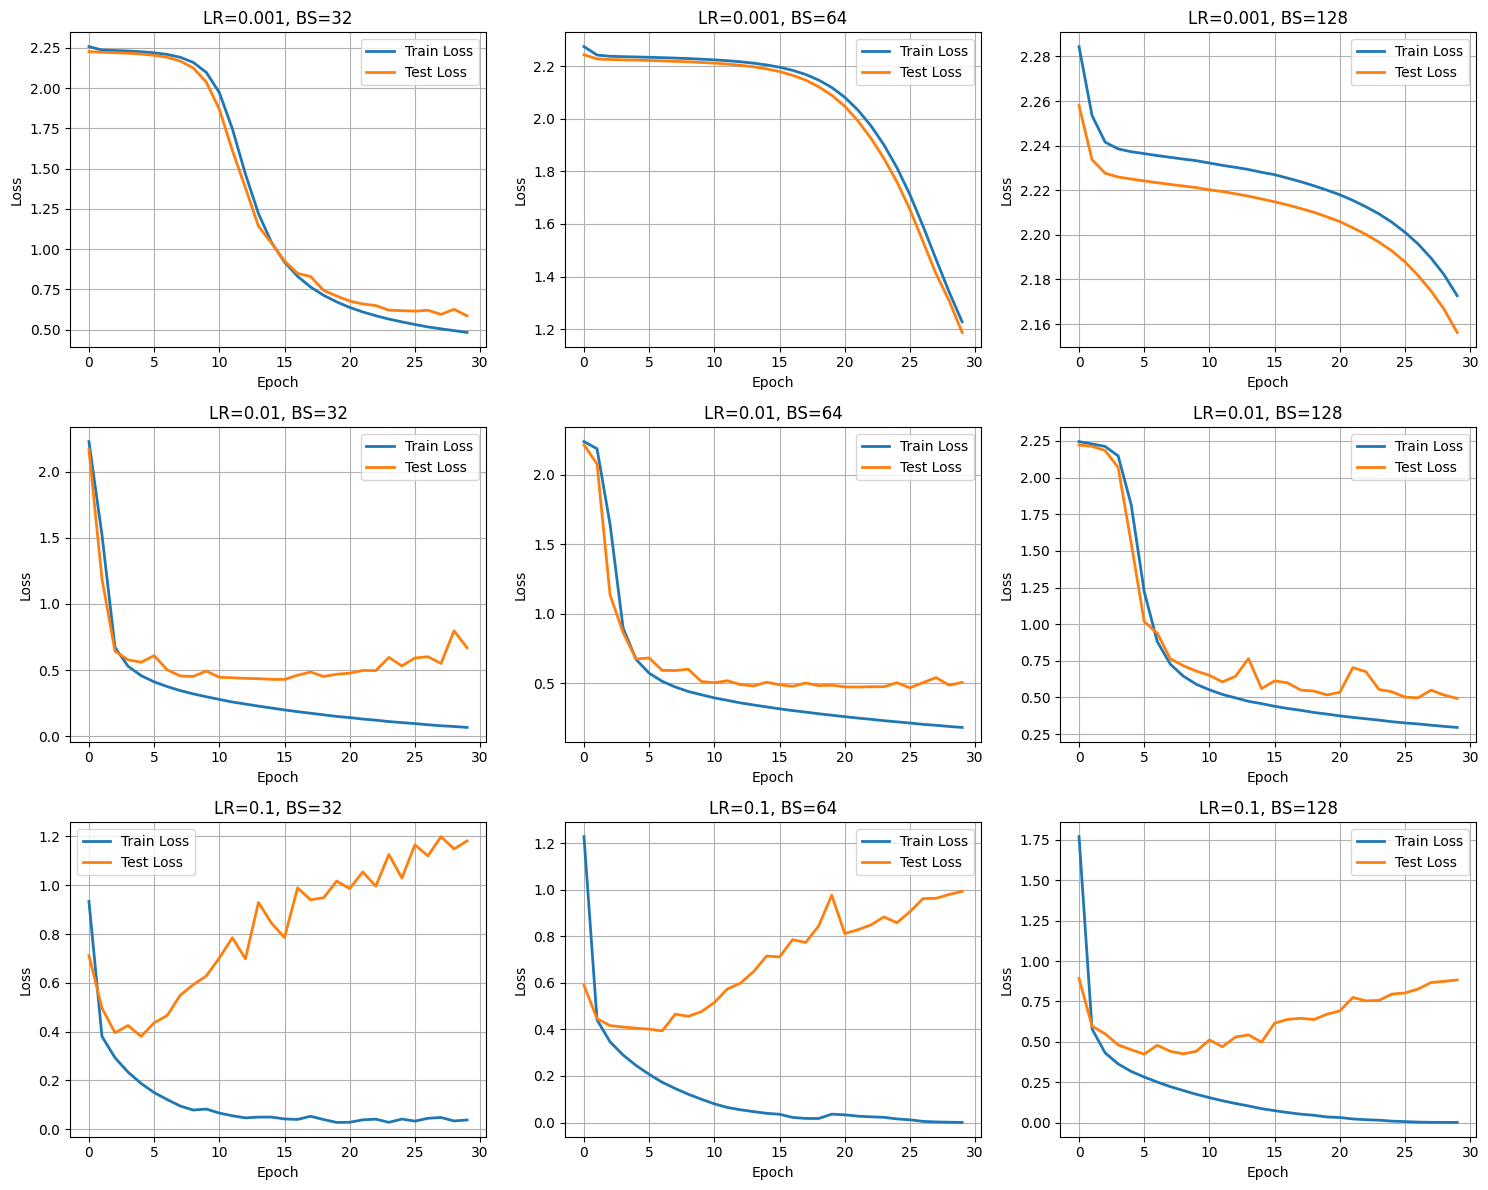

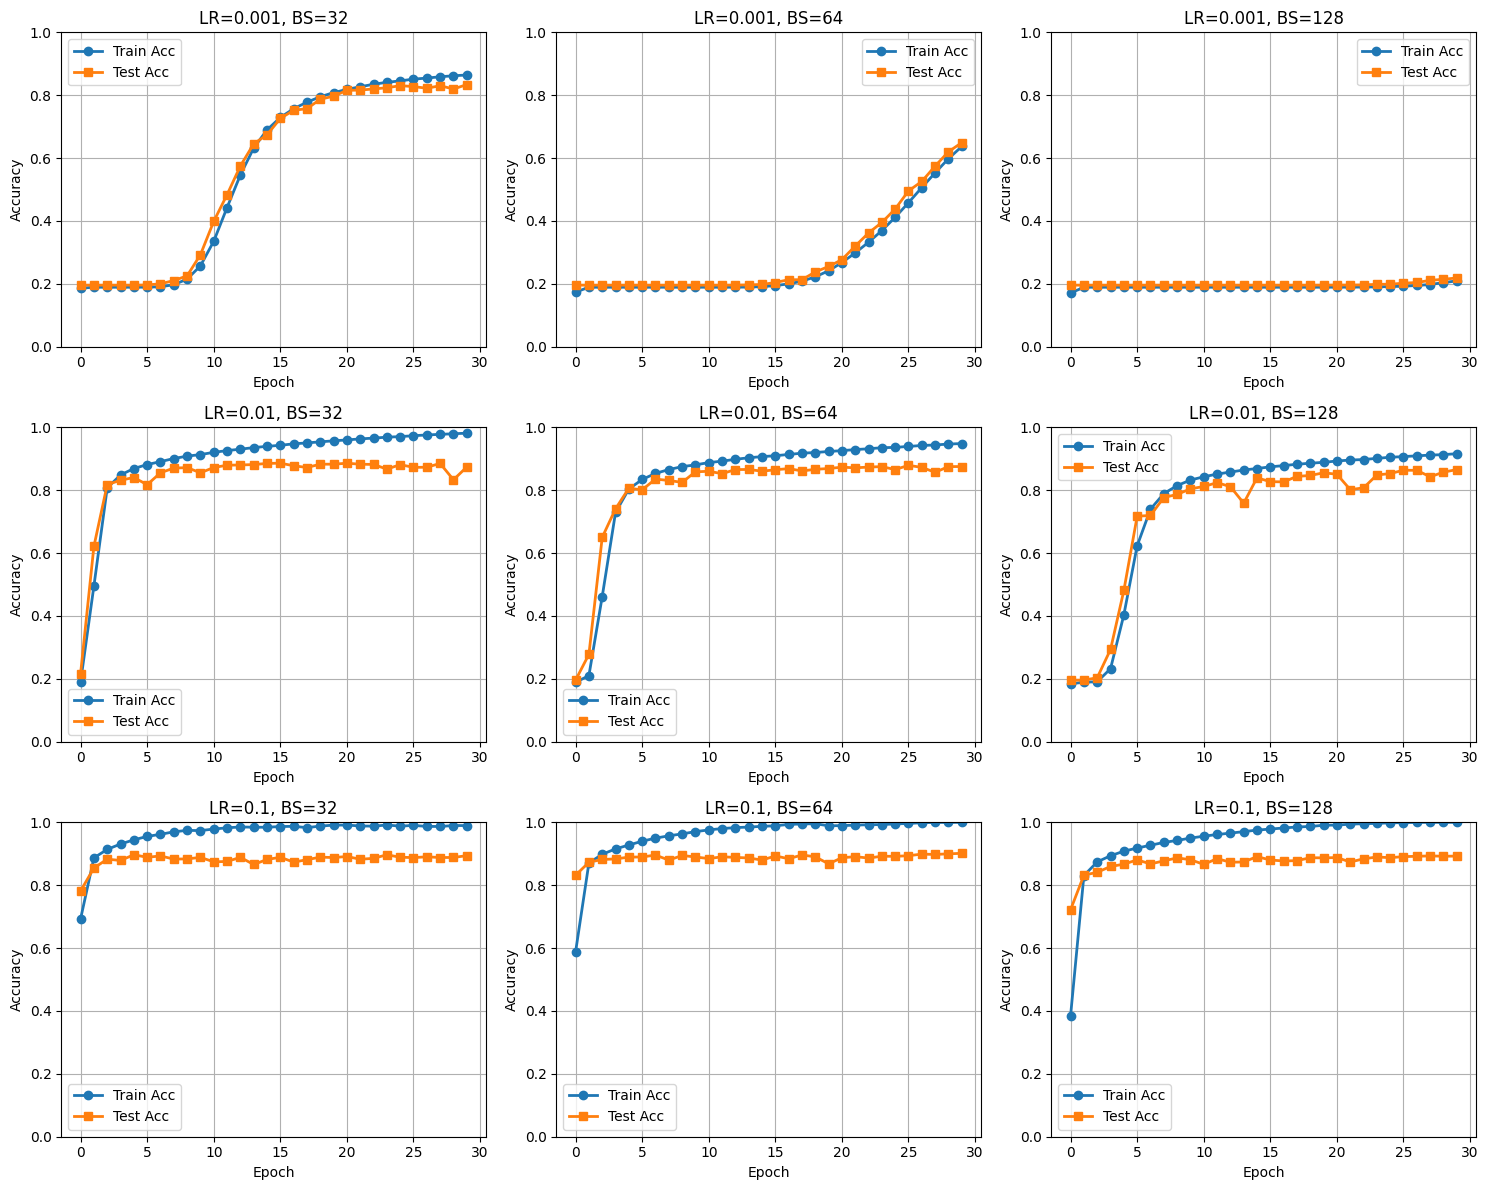

In [32]:
# Lernkurven für alle Kombinationen plotten
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, (lr, bs) in enumerate(sorted(results.keys())):
    res = results[(lr, bs)]
    
    ax = axes[idx]
    epochs_range = range(len(res['train_loss']))
    
    ax.plot(epochs_range, res['train_loss'], label='Train Loss', linewidth=2)
    ax.plot(epochs_range, res['test_loss'], label='Test Loss', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'LR={lr}, BS={bs}')
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.savefig('learning_curves_loss.png', dpi=150)
plt.show()

# Genauigkeitskurven
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, (lr, bs) in enumerate(sorted(results.keys())):
    res = results[(lr, bs)]
    
    ax = axes[idx]
    epochs_range = range(len(res['train_acc']))
    
    ax.plot(epochs_range, res['train_acc'], label='Train Acc', linewidth=2, marker='o')
    ax.plot(epochs_range, res['test_acc'], label='Test Acc', linewidth=2, marker='s')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'LR={lr}, BS={bs}')
    ax.legend()
    ax.grid()
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('learning_curves_accuracy.png', dpi=150)
plt.show()

## Auswertung der Hyperparameter:
Es zeigt sich, dass die Lernrate von 0.001 noch viele weitere Epochen benötigt um zu konvergieren. Je grösser dazu noch die Batch Size ist, desto schlechter ist die Performance. Dies könnte daran liegen, dass es noch weniger Updates gibt, da die Batch Size grösser ist. Was man aber gerade im zweiten Plot sieht, ist dass sich die Accuracy vom Trainings und Testdatensatz nicht grösser unterscheidet.

Bei den beiden grösseren Lernraten konvergiert der Loss auf dem Trainingsdatensatz deutlich besser, auch wird hier eine hohe Accuracy erreicht, welche teilweise fast 100% auf den Trainingsdaten erreicht. Auf den Testdaten sieht man aber, dass kein Modell die Accuracy über 90% bringt. Zudem sieht man auch, dass die Lossfunktion auf den Testdaten meistens sogar ansteigt und nicht konvergiert. Dies könnte ein Anzeichen dafür sein, dass die Modelle überfitten. Was auffällt, ist dass die Accuracy auf den Testdaten stabil bleibst aber die Lossfunktion ansteigt. Dies könnte daran liegen, dass die Modelle zwar die Bilder korrekt klassifizieren, aber mit einer sehr hohen Unsicherheit, was sich in einem hohen Loss widerspiegelt oder dass die Modelle die falsch klassifizierten Bilder nicht nur ein bisschen falsch klassifizieren, sondern komplett falsch, was sich wiederum auch in einem hohen Loss widerspiegelt.



In [33]:
# Beste Parameter finden
best_params = max(results.items(), key=lambda x: np.mean(x[1]['test_acc'][-10:]))
best_lr, best_bs = best_params[0]
best_result = best_params[1]

print("\n" + "=" * 50)
print("BESTE HYPERPARAMETER")
print("=" * 50)
print(f"Learning Rate: {best_lr}")
print(f"Batch Size: {best_bs}")
print(f"Finale Test Accuracy: {best_result['test_acc'][-1]:.4f}")
print(f"Accuracy (letzte 10 Epochen): {np.mean(best_result['test_acc'][-10:]):.4f}")
print(f"Finale Precision: {best_result['test_precisions'][-1]:.4f}")
print(f"Finale Recall: {best_result['test_recalls'][-1]:.4f}")
print(f"Finale F1-Score: {best_result['test_f1s'][-1]:.4f}")


BESTE HYPERPARAMETER
Learning Rate: 0.1
Batch Size: 64
Finale Test Accuracy: 0.9014
Accuracy (letzte 10 Epochen): 0.8940
Finale Precision: 0.9016
Finale Recall: 0.9014
Finale F1-Score: 0.9014


## Beste Hyperparameter-Kombination:
Die beste Hyperparameter-Kombination wird hier ausgewählt um im anschluss einen K-Fold Cross Validation zu machen. Dabei wird als Kriterium die Accuracy auf den zehn letzten Epochen genommen, um eine gewisse Stabilität zu gewährleisten. Es ist mir aber auch bewusst, dass es sicherlich noch bessere Hyperparameter gäbe, wenn die Epochenzahl erhöht werden würde und noch weitere Kombinationen ausprobiert werden würden. Aus zeitgründen gebe ich mich aber mit dieser Kombination für das Baseline Modell zufrieden und werde später noch versuchen die Hyperparameter zu optimieren, um die Performance zu verbessern.

# Statistische Fehleranalyse mit K-Fold Cross-Validation
Hier soll geprüft werden, ob die Ergebnisse des Modells stabil sind oder ob sie stark von der Aufteilung der Daten abhängen. Dazu wird K-Fold Cross-Validation verwendet, um das Modell auf verschiedenen Datenaufteilungen zu trainieren und zu evaluieren. Ich arbeite dabei mit 5 Folds.

In [34]:
print("\n" + "=" * 50)
print("K-Fold Cross-Validation (mit besten Parametern)")
print("=" * 50)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracies = []
cv_results = []

fold = 0
for train_idx, val_idx in kf.split(train_dataset):
    fold += 1
    print(f"\nFold {fold}/5")
    print("-" * 40)
    
    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(train_dataset, val_idx)
    
    train_loader_cv = DataLoader(train_subset, batch_size=best_bs, shuffle=True, generator=g)
    val_loader_cv = DataLoader(val_subset, batch_size=best_bs, shuffle=False, generator=g)
    
    model = BaselineCNN().to(device)
    optimizer = optim.SGD(model.parameters(), lr=best_lr)

    writer_cv = SummaryWriter(log_dir=f"./runs/cv/fold_{fold}")
    
    fold_train_accs = []
    fold_val_accs = []
    
    for epoch in range(30):
        train_loss, train_acc = train_epoch(
            model, train_loader_cv, optimizer, criterion, device, writer=writer_cv, epoch=epoch
        )
        val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
            model, val_loader_cv, criterion, device, writer=writer_cv, epoch=epoch
        )
        
        fold_train_accs.append(train_acc)
        fold_val_accs.append(val_acc)
    
    final_val_acc = fold_val_accs[-1]
    cv_accuracies.append(final_val_acc)
    
    cv_results.append({
        'fold': fold,
        'train_accs': fold_train_accs,
        'val_accs': fold_val_accs,
        'final_acc': final_val_acc
    })
    
    print(f"Finale Val Accuracy: {final_val_acc:.4f}")
    print(f"Finale Val Precision: {val_precision:.4f}")
    print(f"Finale Val Recall: {val_recall:.4f}")
    print(f"Finale Val F1-Score: {val_f1:.4f}")

    writer_cv.close()

# Statistisch Fehler berechnen
mean_acc = np.mean(cv_accuracies)
std_acc = np.std(cv_accuracies)
ci_95 = 1.96 * std_acc / np.sqrt(len(cv_accuracies))

print("\n" + "=" * 50)
print("CROSS-VALIDATION ERGEBNISSE")
print("=" * 50)
print(f"Mean Accuracy: {mean_acc:.4f}")
print(f"Std Abweichung: {std_acc:.4f}")
print(f"95% Konfidenzintervall: [{mean_acc - ci_95:.4f}, {mean_acc + ci_95:.4f}]")
print(f"\nAccuracies pro Fold: {[f'{acc:.4f}' for acc in cv_accuracies]}")


K-Fold Cross-Validation (mit besten Parametern)

Fold 1/5
----------------------------------------
Finale Val Accuracy: 0.9051
Finale Val Precision: 0.9053
Finale Val Recall: 0.9051
Finale Val F1-Score: 0.9051

Fold 2/5
----------------------------------------
Finale Val Accuracy: 0.8963
Finale Val Precision: 0.8963
Finale Val Recall: 0.8963
Finale Val F1-Score: 0.8961

Fold 3/5
----------------------------------------
Finale Val Accuracy: 0.9031
Finale Val Precision: 0.9032
Finale Val Recall: 0.9031
Finale Val F1-Score: 0.9029

Fold 4/5
----------------------------------------
Finale Val Accuracy: 0.9070
Finale Val Precision: 0.9069
Finale Val Recall: 0.9070
Finale Val F1-Score: 0.9069

Fold 5/5
----------------------------------------
Finale Val Accuracy: 0.9087
Finale Val Precision: 0.9086
Finale Val Recall: 0.9087
Finale Val F1-Score: 0.9086

CROSS-VALIDATION ERGEBNISSE
Mean Accuracy: 0.9040
Std Abweichung: 0.0043
95% Konfidenzintervall: [0.9003, 0.9078]

Accuracies pro Fold: ['0.

C:\Users\adria\AppData\Local\Temp\ipykernel_106404\2001227263.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(cv_accuracies, labels=['K-Fold CV'])


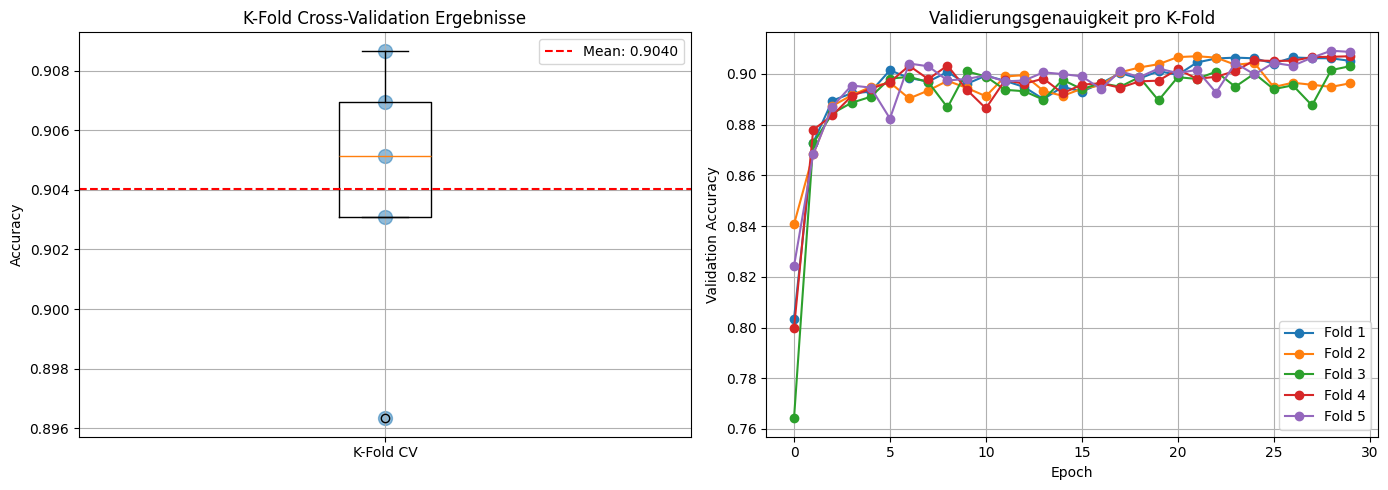

In [35]:
# K-Fold Ergebnisse visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
ax1 = axes[0]
ax1.boxplot(cv_accuracies, labels=['K-Fold CV'])
ax1.scatter([1]*len(cv_accuracies), cv_accuracies, alpha=0.5, s=100)
ax1.axhline(y=mean_acc, color='r', linestyle='--', label=f'Mean: {mean_acc:.4f}')
ax1.set_ylabel('Accuracy')
ax1.set_title('K-Fold Cross-Validation Ergebnisse')
ax1.legend()
ax1.grid()

# Lernkurven pro Fold
ax2 = axes[1]
for result in cv_results:
    epochs_range = range(len(result['val_accs']))
    ax2.plot(epochs_range, result['val_accs'], marker='o', label=f"Fold {result['fold']}")

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy')
ax2.set_title('Validierungsgenauigkeit pro K-Fold')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.savefig('cross_validation_results.png', dpi=150)
plt.show()

## Beurteilung der K-Fold Cross-Validation:
Es ist in den beiden Plots zu sehen, dass die Performance des Modells auf den verschiedenen Folds relativ stabil ist. Es gibt zwar leichte Unterschiede in der Accuracy aber diese sind nicht sehr gross. Einzig verwunderlich ist, dass es an manchen Stellen kleinere Spikes in gewissen Folds gibt. Diese könnten mit kleineren Lernraten vielleicht behoben werden, da diese vielleicht stabiler konvergieren würden.

## Interpretation des Baselinemodells

Das Modell konnte schnell definiert werden und besteht aus einem CNN mit zwei Convolutionalen Layern, welche jeweils von einer ReLU und einem Maxpooling gefolgt werden. Das Modell Overfittet gut auf einem einzelnen Bild und auch auf einem einzelnen Batch.  Im Training mit verschiedenen Lernraten und Batchsizes ist zu sehen, dass das Modell bei einer kleinen Lernrate noch deutlich mehr Epochen bräuchte. Auffallend ist aber auch, dass bei einer hohen Lernrate der Loss beim Testset nach wenigen Epochen ansteigt. Und auch die Accuracy nicht sonderlich verbessert wird nach den ersten par Trainingsepochen.

In der K-Fold Crossvalidation sieht man zudem, dass zwar alle einzelnen Folds ungefähr gleich gut trainieren, jedoch ist auch auffallend, dass die Accuracy an gewissen Punkten enorm schwankt während des Trainings. Die Accuracy erreichte in allen Folds knapp 0.9 und variiert auch nicht sonderlich unter den Folds.



# Hypothesen
In diesem Abschnitt sollen 10 Hypothesen aufgestellt werden, welche danach in einzelnen Experimenten überprüft werden sollen.

**1. Hypothese:**
Mithilfe von kleineren Lernraten und einer Längerer Trainingszeit, welche mithilfe von Early Stopping reguliert wird, könnte die Performance des Modells verbessert werden, da das Modell dadurch stabiler konvergieren könnte.

**2. Hypothese:**
Durch eine vergrösserung der Anzahl an Convolutional Layern könnte die Performance des Modells verbessert werden, da das Modell dadurch in der Lage wäre, komplexere Muster in den Bildern zu erkennen. Dazu sollen weitere Convolutional Layer mit einer grösseren Anzahl an Filtern hinzugefügt werden.

**3. Hypothese:**
Durch eine Vergrösserung der Anzahl an Fully Connected Layern könnte die Performance des Modells verbessert werden. Die Klassifikation aus den Convolutional Layern wird durch die Fully Connected Layer gemacht, weshalb es sinnvoll sein könnte hier mehr Layer hinzuzufügen, damit das Modell die Klassifikation besser lernen kann.

**4. Hypothese:**
Durch eine Vergrösserung der Filterkernels auf 5x5 könnte die Performance des Modells verbessert werden, da das Modell dadurch in der Lage wäre, grössere Muster in den Bildern zu erkennen.

**5. Hypothese:**
Durch die Verwendung von Dropout könnte die Performance des Modells verbessert werden. Dadurch sollte das Modell weniger overfitten und besser auf den Testdaten performen. Durch Dropout soll das Modell gezwungen werden besser zu generalisieren.

**6. Hypothese:**
Die Bilder sollen mit verschiedenen Augmentationstechniken wie Rotation, Skalierung und Verschiebung augmentiert werden, um die Performance des Modells zu verbessern. Wichtig dabei ist, dass die Augmentationstechniken so gewählt werden, dass sie realistische Variationen der Bilder erzeugen (Beispielsweise kein Flippen). Durch die Augmentation soll die Anzahl der Trainingsbeispiele erhöht werden und auch die Robustheit des Modells verbessert werden weil das Modell dadurch besser mit Variation umgehen kann.

**7. Hypothese:**
Durch die Verwendung von Batch Normalization soll die Performance des Modells verbessert werden, da dadurch die Trainingsstabilität erhöht wird und das Modell schneller konvergieren könnte. Diese stabilität geschieht bei Batch Normalization dadurch, dass die Verteilung der Aktivierungen in den einzelnen Layern normalisiert wird, was dazu führt, dass das Modell schneller und stabiler konvergieren kann.

**8. Hypothese:**
Die gewichte sollen zufällig mit einer Normalverteilung initialisiert werden. Hierbei wird das Modell schlechter als mit der Standard Initialisierung des Frameworks performen, da die Gewichte nicht optimal initialisiert werden und das Modell dadurch länger braucht um zu konvergieren und in den ersten Layern nicht gross geupdatet wird von der Backpropagation.

**9. Hypothese:**
Durch die Verwendung von einem anderen Optimizer wie Adam könnte die Performance des Modells verbessert werden, da Adam adaptiv die Lernrate anpasst und dadurch schneller konvergieren könnte.

**10. Hypothese:**
Durch die Verwendung von einem anderen Loss wie Focal Loss könnte die Performance des Modells verbessert werden. Da in den Daten eine Klassenimbalance besteht, könnte Focal Loss besser performen, da es die schwer zu klassifizierenden Beispiele stärker gewichtet und dadurch das Modell besser lernt, diese Beispiele korrekt zu klassifizieren.

# Experimente
## Experiment 1: Kleinere Lernrate und Early Stopping
**Hypothese:**
Mithilfe von kleineren Lernraten und einer längerer Trainingszeit, welche mithilfe von Early Stopping reguliert wird, könnte die Performance des Modells verbessert werden, da das Modell dadurch stabiler konvergieren könnte.

In diesem Experiment soll überprüft werden, ob die Performance des Modells durch die Verwendung von kleineren Lernraten und Early Stopping verbessert werden kann. Im Baselinemodell wurde bereits klar, dass eine Lernrate von 0.001 nach 30 Epochen noch nicht konvergiert ist. Das Ziel ist nun, eine Bessere Performance zu erzielen, indem verschiedene eher kleinere Lernraten und Early Stopping-Konfigurationen ausprobiert werden. Das Modell soll erst stoppen, wenn der Loss auf den Testdaten für 5 bzw. 10 Epochen nicht mehr sinkt (Early Stopping nach 5 oder 10 Epochen).

Dazu muss folgendes gemacht werden:
- Early Stopping implementieren, welches den Loss auf den Testdaten überwacht und das Training stoppt, wenn der Loss für x Epochen nicht mehr sinkt.
- Das Modell mit den verschiedenen Hyperparametern trainieren und die Performance auf den Testdaten überwachen.


In [36]:
# Hyperparameter
lr_exp1 = [0.01, 0.005, 0.001, 0.0005]
patiences = [5, 10]
results_exp1 = {}
max_epochs = 200

for lr in lr_exp1:
        for pat in patiences:
            torch.manual_seed(42)  
            model_early_stopping = BaselineCNN().to(device)
            loader_early_stopping = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
            optimizer_early_stopping = optim.SGD(model_early_stopping.parameters(), lr=lr)
            criterion_early_stopping = nn.CrossEntropyLoss()
            device_early_stopping = device
            writer_early_stopping = SummaryWriter(log_dir=f"./runs/experiment1/experiment1_lr{lr}_pat{pat}")

            best_val_loss = float('inf')        # Beste Validierungsverlust bisher
            patience_counter = 0    # Zähler für die Anzahl der Epochen ohne Verbesserung
            best_epoch = 0

            history = {
                'train_loss': [],
                'train_acc': [],
                'val_loss': [],
                'val_acc': [],
                'val_precision': [],
                'val_recall': [],
                'val_f1': []
                }

            for epoch in range(max_epochs):
                # Training
                train_loss, train_acc = train_epoch(
                    model_early_stopping,
                    loader_early_stopping,
                    optimizer_early_stopping,
                    criterion_early_stopping,
                    device_early_stopping,
                    writer=writer_early_stopping,
                    epoch=epoch
                )

                # Evaluation
                val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
                    model_early_stopping,
                    test_loader,
                    criterion_early_stopping,
                    device_early_stopping,
                    writer=writer_early_stopping,
                    epoch=epoch
                )

                history['train_loss'].append(train_loss)
                history['train_acc'].append(train_acc)
                history['val_loss'].append(val_loss)
                history['val_acc'].append(val_acc)
                history['val_precision'].append(val_precision)
                history['val_recall'].append(val_recall)
                history['val_f1'].append(val_f1)

                # Early Stopping Logik
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_epoch = epoch
                    patience_counter = 0  # Reset des Zählers bei Verbesserung
                else:
                    patience_counter += 1  # Erhöhe den Zähler bei keiner Verbesserung

                if patience_counter >= pat:
                    print(f"Early Stopping bei Epoch {epoch} - Keine Verbesserung seit {pat} Epochen")
                    break

                if epoch == max_epochs - 1:
                    print(f"Maximale Anzahl von {max_epochs} Epochen erreicht, Training wird gestoppt ohne Early Stopping.")

            results_exp1[(lr, pat)] = {
                 **history,
                'best_val_loss': best_val_loss,
                'best_epoch': epoch - patience_counter,
                'stopped_at_epoch': epoch
            }
            writer_early_stopping.close()

Early Stopping bei Epoch 13 - Keine Verbesserung seit 5 Epochen
Early Stopping bei Epoch 25 - Keine Verbesserung seit 10 Epochen
Early Stopping bei Epoch 23 - Keine Verbesserung seit 5 Epochen
Early Stopping bei Epoch 33 - Keine Verbesserung seit 10 Epochen
Early Stopping bei Epoch 64 - Keine Verbesserung seit 5 Epochen
Early Stopping bei Epoch 71 - Keine Verbesserung seit 10 Epochen
Early Stopping bei Epoch 85 - Keine Verbesserung seit 5 Epochen
Early Stopping bei Epoch 119 - Keine Verbesserung seit 10 Epochen


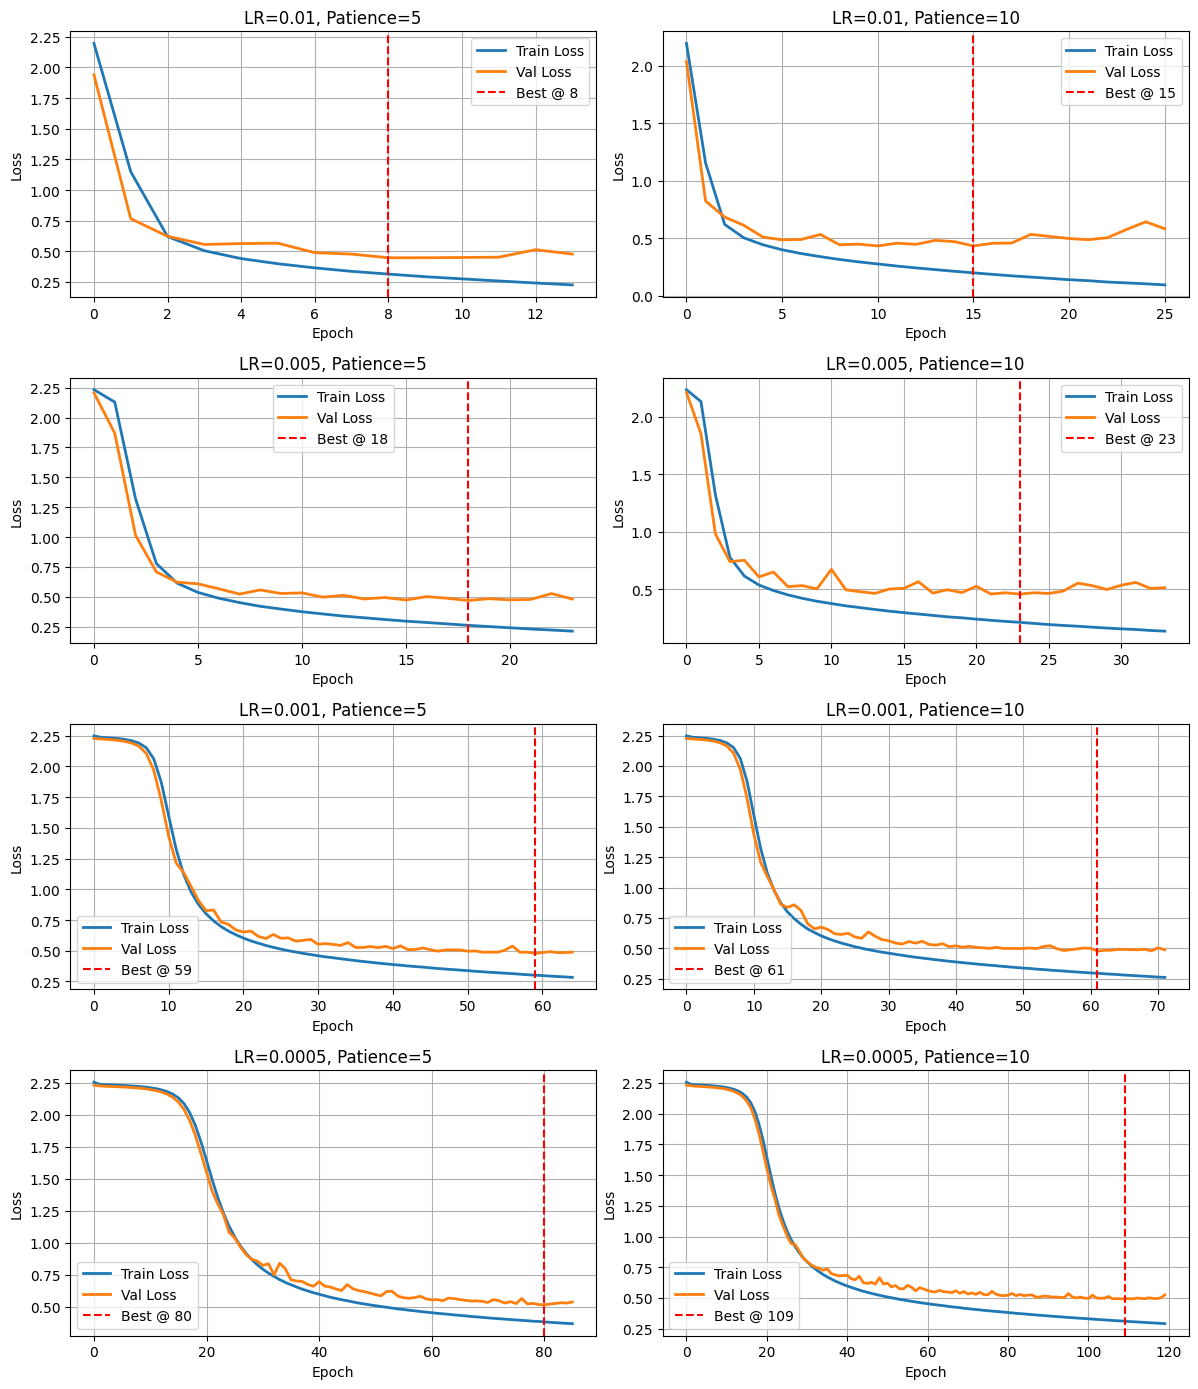

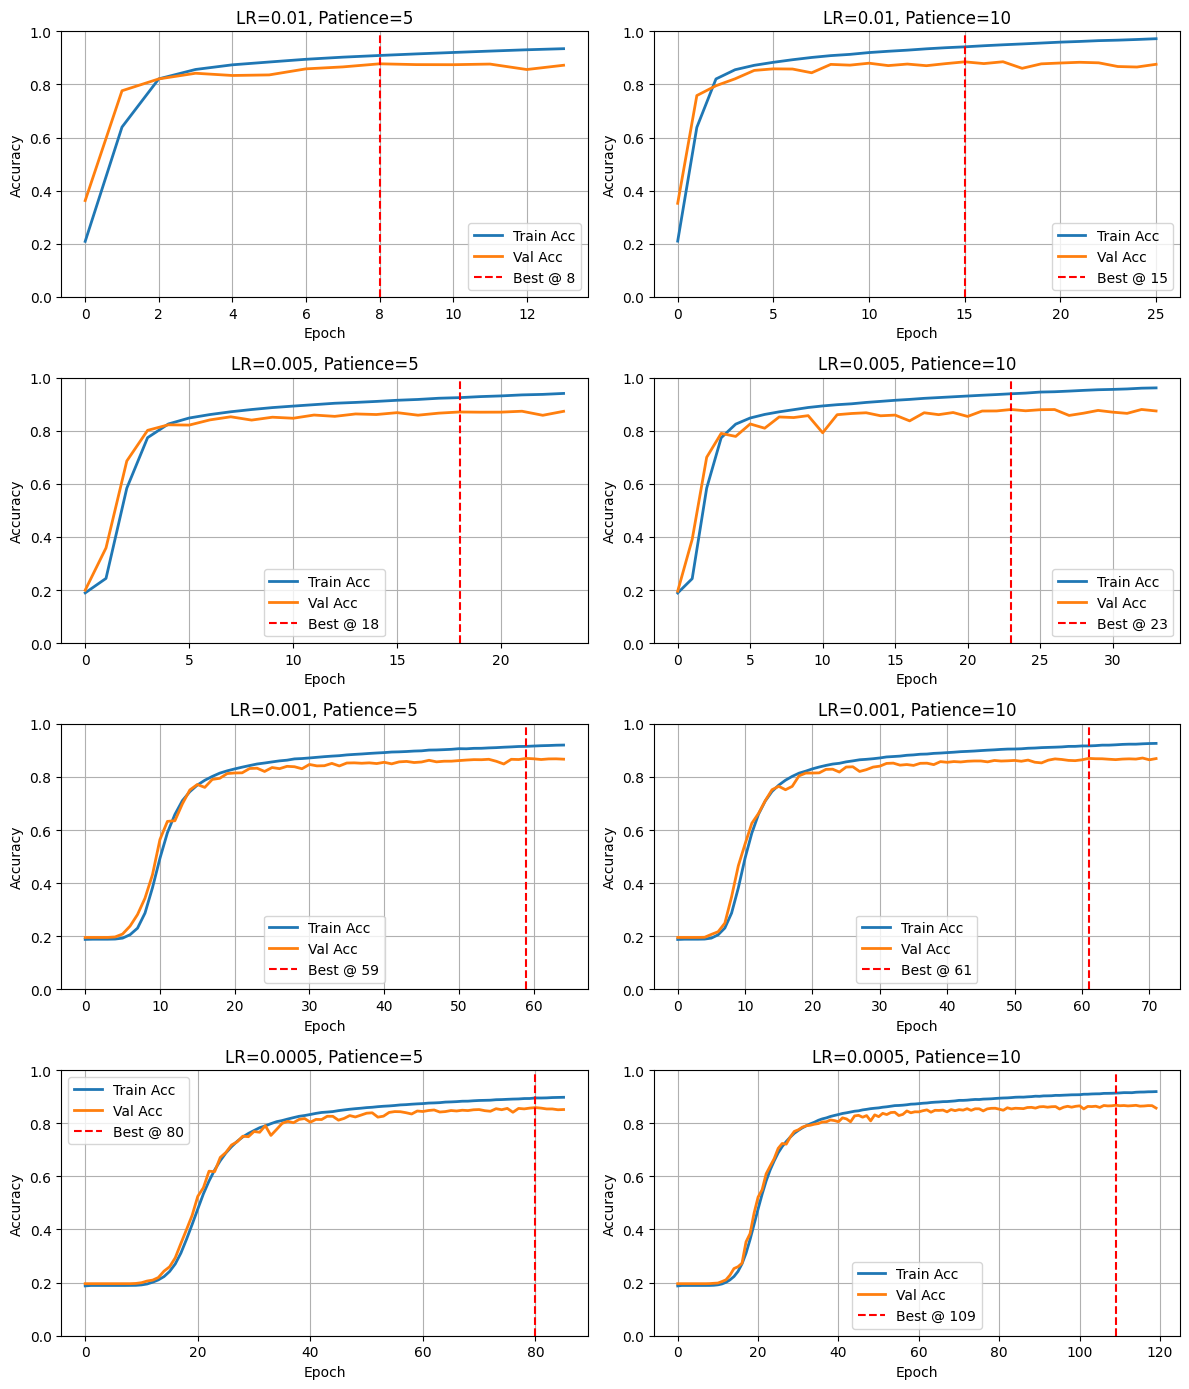

In [37]:
# Loss Kurven
fig, axes = plt.subplots(len(lr_exp1), len(patiences), figsize=(12, 14))

for i, lr in enumerate(lr_exp1):
    for j, pat in enumerate(patiences):
        res = results_exp1[(lr, pat)]
        ax = axes[i, j]
        epochs_range = range(len(res['train_loss']))

        ax.plot(epochs_range, res['train_loss'], label='Train Loss', linewidth=2)
        ax.plot(epochs_range, res['val_loss'],   label='Val Loss',   linewidth=2)
        ax.axvline(res['best_epoch'], color='r', linestyle='--',
                   label=f"Best @ {res['best_epoch']}")
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(f'LR={lr}, Patience={pat}')
        ax.legend()
        ax.grid()

plt.tight_layout()
plt.savefig('exp1_loss_curves.png', dpi=150)
plt.show()

# Accuracy Kurven
fig, axes = plt.subplots(len(lr_exp1), len(patiences), figsize=(12, 14))

for i, lr in enumerate(lr_exp1):
    for j, pat in enumerate(patiences):
        res = results_exp1[(lr, pat)]
        ax = axes[i, j]
        epochs_range = range(len(res['train_acc']))

        ax.plot(epochs_range, res['train_acc'], label='Train Acc', linewidth=2)
        ax.plot(epochs_range, res['val_acc'],   label='Val Acc',   linewidth=2)
        ax.axvline(res['best_epoch'], color='r', linestyle='--',
                   label=f"Best @ {res['best_epoch']}")
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'LR={lr}, Patience={pat}')
        ax.set_ylim([0, 1])
        ax.legend()
        ax.grid()

plt.tight_layout()
plt.savefig('exp1_accuracy_curves.png', dpi=150)
plt.show()

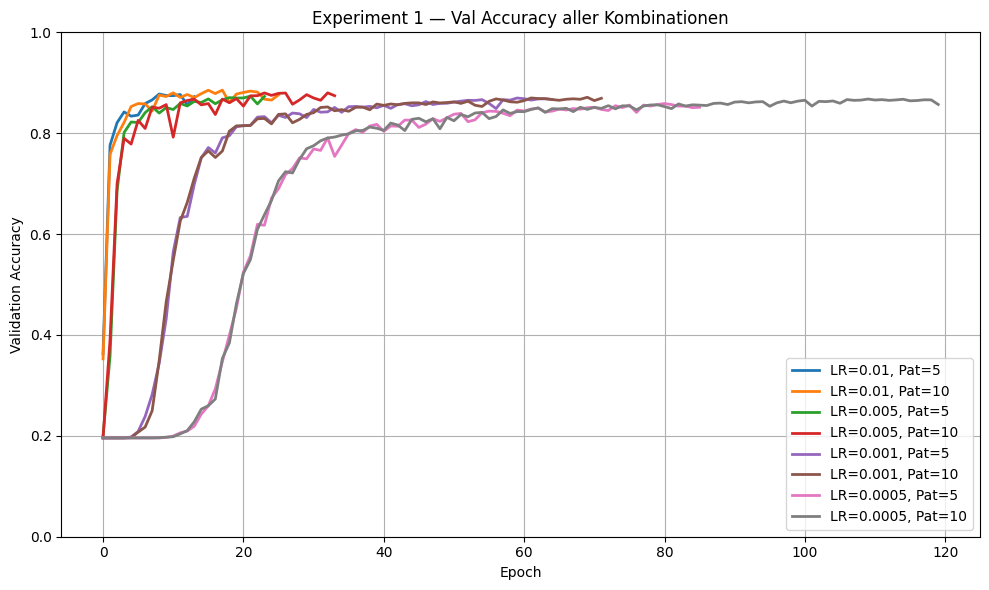

In [38]:
plt.figure(figsize=(10, 6))

for (lr, pat), res in results_exp1.items():
    epochs_range = range(len(res['val_acc']))
    plt.plot(epochs_range, res['val_acc'],
             label=f'LR={lr}, Pat={pat}', linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Experiment 1 — Val Accuracy aller Kombinationen')
plt.legend()
plt.grid()
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('exp1_val_acc_comparison.png', dpi=150)
plt.show()

In [39]:
# Tabelare Zusammenfassung
print("\n" + "=" * 50)
print("EXPERIMENT 1 ERGEBNISSE")
print("=" * 50)
print(f"{'LR':<10} {'Patience':<10} {'Best Val Acc':<20} {'Best Epoch':<15} {'Stopped At Epoch':<20}")
print("-" * 75)
for (lr, pat), res in results_exp1.items():
    best_val_acc = res['val_acc'][res['best_epoch']]
    print(f"{lr:<10} {pat:<10} {best_val_acc:<20.4f} {res['best_epoch']:<15} {res['stopped_at_epoch']:<20}")


EXPERIMENT 1 ERGEBNISSE
LR         Patience   Best Val Acc         Best Epoch      Stopped At Epoch    
---------------------------------------------------------------------------
0.01       5          0.8777               8               13                  
0.01       10         0.8852               15              25                  
0.005      5          0.8705               18              23                  
0.005      10         0.8799               23              33                  
0.001      5          0.8698               59              64                  
0.001      10         0.8699               61              71                  
0.0005     5          0.8588               80              85                  
0.0005     10         0.8677               109             119                 


### Auswertung Experiment 1:
Es zeigt sich das eine kleinere Lernrate zwar die anzahl der benötigten Epochen erhöht, aber die Performance auf den Testdaten nicht wirklich verbessert wird. Es ist auffallend, dass eine halb so grosse Lernrate eigentlich immer die doppelte Epochenanzahl benötigt, um zu konvergieren. Dies könnte darauf hindeuten, dass in beiden Fällen das gleiche Optimum gefunden wird, aber die kleinere Lernrate einfach länger braucht um dorthin zu konvergieren. 

Bei der unterschiedlichen Patience ist kein sonderlich grosser Unterschied zu sehen. Jedoch wirkt eine Patience von 10 Epochen etwas stabiler.

Aufgrund der Ergebnisse aus diesem Experiment entscheide ich mich für eine Lernrate von 0.01 und eine Patience von 10 Epochen für mein Finales Modell. Zudem wird von nun an die Lernrate bei allen weiteren Experimenten auf 0.01 gesetzt.

## Experiment 2: Mehr Convolutional Layer
**Hypothese:**
Durch eine vergrösserung der Anzahl an Convolutional Layern könnte die Performance des Modells verbessert werden, da das Modell dadurch in der Lage wäre, komplexere Muster in den Bildern zu erkennen. Dazu sollen weitere Convolutional Layer mit einer grösseren Anzahl an Filtern hinzugefügt werden.

In diesem Experiment soll überprüft werden, ob die Performance des Modells durch die Verwendung von mehr Convolutional Layern verbessert werden kann. Im Baselinemodell wurden bereits zwei Convolutional Layer verwendet. Das Ziel ist nun, eine Bessere Performance zu erzielen, indem weitere Convolutional Layer mit einer grösseren Anzahl an Filtern hinzugefügt werden. Als Hyperparameter sollen erneut die Parameter gneommen werden, welche im Hyperparameter Tuning als beste Kombination herausgekommen sind, also eine Lernrate von 0.1 und eine Batch Size von 32.

Die Filter sollen dabei jeweils verdoppelt werden, gestartet wird mit 32 Filtern und danach werden 4 weitere Convolutional Layer hinzugefügt, welche jeweils die doppelte Anzahl an Filtern haben wie der vorherige Layer. Am Ende sollen so 512 Filter im letzten Convolutional Layer sein.

Deshalb muss auch das FC angepasst werden. Das FC wird aber bewusst nicht grösser gemacht, um die beiden CNN direkt vergleichen zu können. Im nächsten Experiment wird dies dann auch noch genauer betrachtet.

Dazu muss folgendes gemacht werden:
- Das Baseline CNN muss erweitert werden, indem weitere Convolutional Layer mit einer grösseren Anzahl an Filtern hinzugefügt werden.

In [40]:
class MoreLayerCNN(nn.Module):

    def __init__(self, num_conv_blocks=2, start_filters=32, fc_hidden=128):

        super().__init__()

        layers = []
        in_channels = 3
        out_channels = start_filters

        for _ in range(num_conv_blocks):
            layers.append(nn.Conv2d(in_channels, out_channels, 3, padding=1))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2))
            in_channels = out_channels
            out_channels *= 2

        

        self.conv = nn.Sequential(*layers)

        # FC Automatisch berechnen

        spatial = start_filters // (2 ** num_conv_blocks)

        fc_input = in_channels * spatial * spatial

        self.fc = nn.Sequential(
            nn.Flatten(),                       # Flacht 3D-Tensor ab
            nn.Linear(fc_input, fc_hidden),     # Automatisch berechnete Eingabekanäle, 512 Ausgabekanäle
            nn.ReLU(),
            nn.Linear(fc_hidden,10)
        )

    def forward(self,x):

        x = self.conv(x)                        # Durchlaufen der Convolutional Layers
        x = self.fc(x)                          # Durchlaufen der Fully Connected Layers

        return x

In [41]:
# Experiment 2 Trainieren mit standard Hyperparametern, aber mehr Layern
# Hyperparameter
num_blocks_exp2 = [2, 3, 4, 5]
results_exp2 = {}
max_epochs = 30

for n_blocks in num_blocks_exp2:
    torch.manual_seed(42)  
    model_more_layers = MoreLayerCNN(num_conv_blocks=n_blocks).to(device)
    loader_more_layers = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
    optimizer_more_layers = optim.SGD(model_more_layers.parameters(), lr=0.01)
    criterion_more_layers = nn.CrossEntropyLoss()
    device_more_layers = device
    writer_more_layers = SummaryWriter(log_dir=f"./runs/experiment2/experiment2_blocks{n_blocks}")

    n_params = sum(p.numel() for p in model_more_layers.parameters())
    print(f"\nTraining mit {n_blocks} Convolutional Blocks - Anzahl Parameter: {n_params}")

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_precision': [],
        'val_recall': [],
        'val_f1': []
        }

    for epoch in range(max_epochs):
        # Training
        train_loss, train_acc = train_epoch(
            model_more_layers,
            loader_more_layers,
            optimizer_more_layers,
            criterion_more_layers,
            device_more_layers,
            writer=writer_more_layers,
            epoch=epoch
        )

        # Evaluation
        val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
            model_more_layers,
            test_loader,
            criterion_more_layers,
            device_more_layers,
            writer=writer_more_layers,
            epoch=epoch
        )

        # History befüllen
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_precision'].append(val_precision)
        history['val_recall'].append(val_recall)
        history['val_f1'].append(val_f1)

        if epoch % 2 == 0:
            print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, "
                f"Precision={val_precision:.4f}, Recall={val_recall:.4f}, F1={val_f1:.4f}")
            
    writer_more_layers.close()

    results_exp2[n_blocks] = {
        **history,
        'final_val_acc': val_acc,
        'final_precision': val_precision,
        'final_recall': val_recall,
        'final_f1': val_f1,
        'n_params': n_params
    }


Training mit 2 Convolutional Blocks - Anzahl Parameter: 545098
Epoch 0: Train Acc=0.2093, Val Acc=0.3340, Precision=0.4140, Recall=0.3340, F1=0.2358
Epoch 2: Train Acc=0.8179, Val Acc=0.8355, Precision=0.8368, Recall=0.8355, F1=0.8347
Epoch 4: Train Acc=0.8714, Val Acc=0.8387, Precision=0.8534, Recall=0.8387, F1=0.8405
Epoch 6: Train Acc=0.8939, Val Acc=0.8691, Precision=0.8708, Recall=0.8691, F1=0.8687
Epoch 8: Train Acc=0.9096, Val Acc=0.8745, Precision=0.8771, Recall=0.8745, F1=0.8745
Epoch 10: Train Acc=0.9208, Val Acc=0.8690, Precision=0.8740, Recall=0.8690, F1=0.8692
Epoch 12: Train Acc=0.9303, Val Acc=0.8846, Precision=0.8847, Recall=0.8846, F1=0.8842
Epoch 14: Train Acc=0.9395, Val Acc=0.8782, Precision=0.8835, Recall=0.8782, F1=0.8785
Epoch 16: Train Acc=0.9467, Val Acc=0.8743, Precision=0.8791, Recall=0.8743, F1=0.8742
Epoch 18: Train Acc=0.9532, Val Acc=0.8848, Precision=0.8861, Recall=0.8848, F1=0.8848
Epoch 20: Train Acc=0.9600, Val Acc=0.8835, Precision=0.8860, Recall=0.

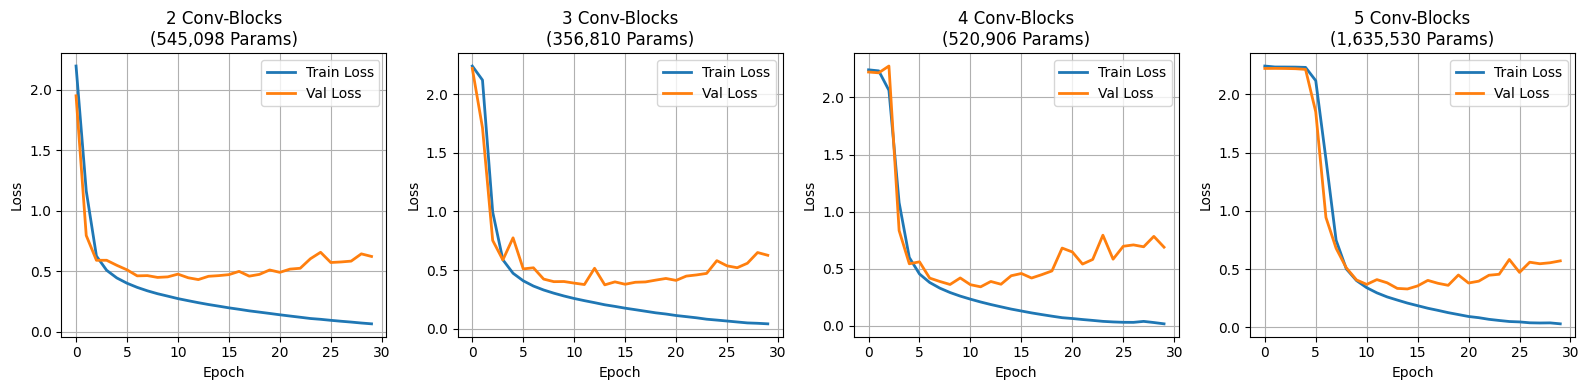

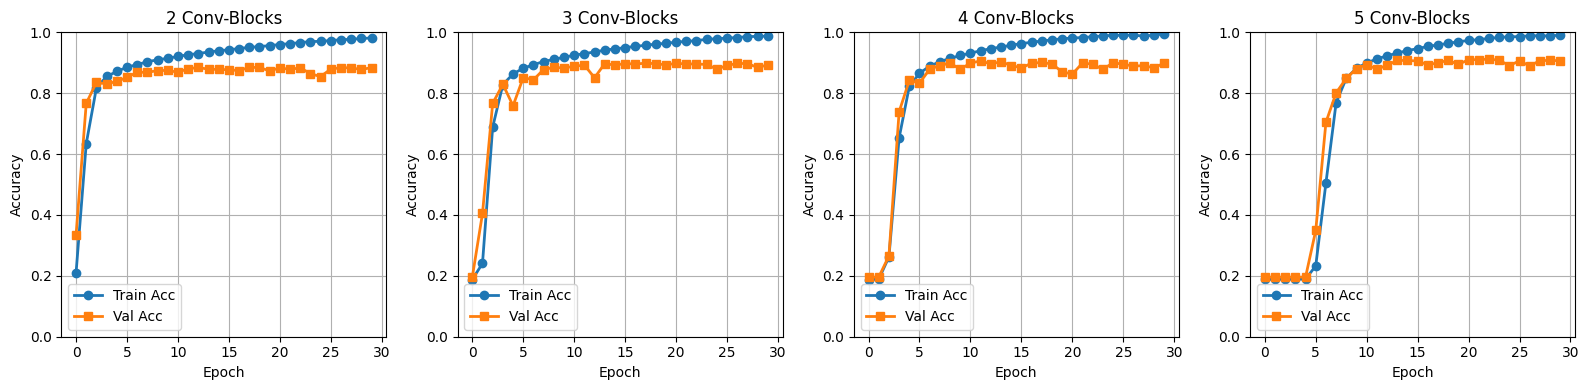

In [42]:
# Loss Kurven
fig, axes = plt.subplots(1, len(num_blocks_exp2), figsize=(16, 4))

for idx, n_blocks in enumerate(num_blocks_exp2):
    res = results_exp2[n_blocks]
    ax = axes[idx]
    epochs_range = range(len(res['train_loss']))

    ax.plot(epochs_range, res['train_loss'], label='Train Loss', linewidth=2)
    ax.plot(epochs_range, res['val_loss'],   label='Val Loss',   linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{n_blocks} Conv-Blocks\n({res["n_params"]:,} Params)')
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.savefig('exp2_loss_curves.png', dpi=150)
plt.show()

# Accuracy Kurven
fig, axes = plt.subplots(1, len(num_blocks_exp2), figsize=(16, 4))

for idx, n_blocks in enumerate(num_blocks_exp2):
    res = results_exp2[n_blocks]
    ax = axes[idx]
    epochs_range = range(len(res['train_acc']))

    ax.plot(epochs_range, res['train_acc'], label='Train Acc', linewidth=2, marker='o')
    ax.plot(epochs_range, res['val_acc'],   label='Val Acc',   linewidth=2, marker='s')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{n_blocks} Conv-Blocks')
    ax.set_ylim([0, 1])
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.savefig('exp2_accuracy_curves.png', dpi=150)
plt.show()

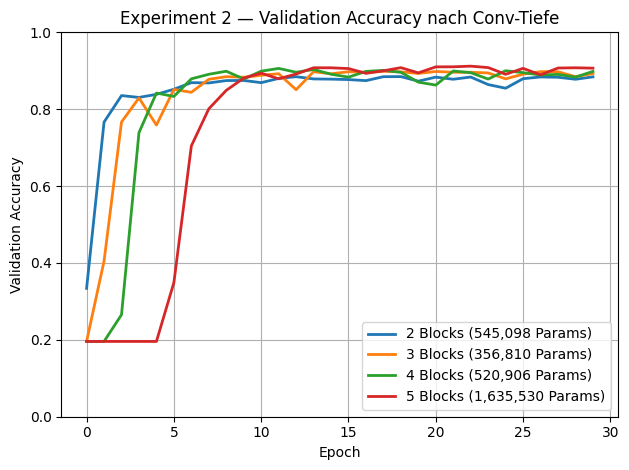

In [43]:
for n_blocks, res in results_exp2.items():
    plt.plot(res['val_acc'],
             label=f'{n_blocks} Blocks ({res["n_params"]:,} Params)',
             linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Experiment 2 — Validation Accuracy nach Conv-Tiefe')
plt.legend()
plt.grid()
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('exp2_val_acc_comparison.png', dpi=150)
plt.show()

In [44]:
# Tabellarische Zusammenfassung
print("\n" + "=" * 50)
print("EXPERIMENT 2 ERGEBNISSE")
print("=" * 50)
print(f"{'Conv Blocks':<15} {'# Params':<15} {'Final Val Acc':<20} {'Final Precision':<20} {'Final Recall':<20} {'Final F1-Score':<20}")
print("-" * 110)
for n_blocks, res in results_exp2.items():
    print(f"{n_blocks:<15} {res['n_params']:<15,} {res['final_val_acc']:<20.4f} "
          f"{res['final_precision']:<20.4f} {res['final_recall']:<20.4f} {res['final_f1']:<20.4f}")


EXPERIMENT 2 ERGEBNISSE
Conv Blocks     # Params        Final Val Acc        Final Precision      Final Recall         Final F1-Score      
--------------------------------------------------------------------------------------------------------------
2               545,098         0.8841               0.8857               0.8841               0.8845              
3               356,810         0.8928               0.8945               0.8928               0.8931              
4               520,906         0.8984               0.8996               0.8984               0.8986              
5               1,635,530       0.9068               0.9082               0.9068               0.9071              


### Auswertung Experiment 2:
Es ist schnell ersichtlich, dass bei Modellen mit mehr Convolutional Layern es mehr anlaufzeit benötigt, bis die Modelle konvergieren. Nach ca 15 Epochen sind jedoch alle Modelle sehr ähnlich zueinander. Bei den Modellen mit mehr Convolutional Layern gibt es teilweise sogar kleinere Auschläge in der Accuracy, und der Loss auf den Testdaten steigt sogar etwas mehr an. Die tiefernen Modelle mit 4 und 5 Convolutional Layern performen zwar etwas besser, benötigen aber deutlich mehr Parameter und auch Zeit um zu trainieren. Der Unterschied ist in meinen Augen zu klein um eine so grosse Erhöhung der Anzahl an Convolutional Layern zu rechtfertigen. Ein kleiner Unterschied ist aber zu erkennen zwischen 2 und 3 Convolutional Layern, da das Modell mit 3 Convolutional Layern etwas etwas besser Performt.

Auf Grund der besseren Performance des Modells mit 3 Convolutional Layern und der gleichzeitig immer noch kleineren Anzahl an Parametern entscheide ich mich für dieses Modell für das Finale Modell. Ich will aber trotzdem auch im Finalen Modell versuche die Anzahl der Convolutional Layer auf 5 zu erhöhen, da diese zwar am komplexesten sind aber auch am besten Performen.

## Experiment 3: Mehr Fully Connected Layer
**Hypothese:**
Durch eine Vergrösserung der Anzahl an Fully Connected Layern könnte die Performance des Modells verbessert werden. Die Klassifikation aus den Convolutional Layern wird durch die Fully Connected Layer gemacht, weshalb es sinnvoll sein könnte hier mehr Layer hinzuzufügen, damit das Modell die Klassifikation besser lernen kann.

Um die Klassifikation aus den Convolutional Layern zu machen, werden die Fully Connected Layer verwendet. Im Baseline Modell wurde bereits ein Fully Connected Layer mit 128 Neuronen verwendet, welche danach direkt mit der Ausgabe von 10 Neuronen verbunden ist, welche die 10 Klassen repräsentieren. Das Ziel ist nun, eine bessere Performance zu erzielen, indem weitere Fully Connected Layer hinzugefügt werden.

Es sollen zwei weitere Fully Connected Layer hinzugefügt werden, welche jeweils aus 64 Neuronen bestehen. Der erste Fully Connected Layer soll wie ursprünglich mit der Ausgabe der Convolutional Layer verbunden werden, danach sollen die zwei hinzugefügten Fully Connected Layer mit dem ersten Fully Connected Layer verbunden werden und danach soll der letzte Fully Connected Layer mit der Ausgabe von 10 Neuronen verbunden werden, welche die 10 Klassen repräsentieren.

Dazu muss folgendes gemacht werden:
- Das Baseline CNN muss erweitert werden, indem weitere Fully Connected Layer hinzugefügt werden.

In [45]:
class FlexibleFCCNN(nn.Module):
    def __init__(self, num_fc_layers=2):
        super().__init__()
        
        # Conv
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Hidden-Layer-Breiten: erste 128, alle weiteren 64
        hidden_widths = []
        if num_fc_layers >= 2:
            hidden_widths.append(128)
        if num_fc_layers >= 3:
            hidden_widths.extend([64] * (num_fc_layers - 2))
        
        layers = [nn.Flatten()]
        in_features = 64 * 8 * 8
        
        for width in hidden_widths:
            layers.append(nn.Linear(in_features, width))
            layers.append(nn.ReLU())
            in_features = width
        
        layers.append(nn.Linear(in_features, 10))   # Output-Layer
        self.fc = nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [46]:
# Experiment 3: Standard Hyperparameter, aber mehr Fully Connected Layer
# Hyperparameter
num_fc_layers_exp3 = [1, 2, 3, 4, 5]
results_exp3 = {}
max_epochs = 30

for n_fc in num_fc_layers_exp3:
    torch.manual_seed(42)
    
    model_more_FC = FlexibleFCCNN(num_fc_layers=n_fc).to(device)
    loader_more_FC = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
    optimizer_more_FC = optim.SGD(model_more_FC.parameters(), lr=0.01)
    criterion_more_FC = nn.CrossEntropyLoss()
    device_more_FC = device
    writer_more_FC = SummaryWriter(log_dir=f"./runs/experiment3/experiment3_fc{n_fc}")

    n_params = sum(p.numel() for p in model_more_FC.parameters())
    print(f"\nTraining mit {n_fc} FC-Layern ({n_params:,} Parameter)")
    print("-" * 50)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_precision': [],
        'val_recall': [],
        'val_f1': []
    }

    for epoch in range(max_epochs):
        train_loss, train_acc = train_epoch(
            model_more_FC,
            loader_more_FC,
            optimizer_more_FC,
            criterion_more_FC,
            device_more_FC,
            writer=writer_more_FC,
            epoch=epoch
        )

        val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
            model_more_FC,
            test_loader,
            criterion_more_FC,
            device_more_FC,
            writer=writer_more_FC,
            epoch=epoch
        )

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_precision'].append(val_precision)
        history['val_recall'].append(val_recall)
        history['val_f1'].append(val_f1)

        if epoch % 2 == 0:
            print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, "
                  f"Precision={val_precision:.4f}, Recall={val_recall:.4f}, F1={val_f1:.4f}")
            
    writer_more_FC.close()

    results_exp3[n_fc] = {
        **history,
        'final_val_acc': val_acc,
        'final_precision': val_precision,
        'final_recall': val_recall,
        'final_f1': val_f1,
        'n_params': n_params
    }


Training mit 1 FC-Layern (60,362 Parameter)
--------------------------------------------------
Epoch 0: Train Acc=0.3830, Val Acc=0.6491, Precision=0.7184, Recall=0.6491, F1=0.6507
Epoch 2: Train Acc=0.8219, Val Acc=0.8063, Precision=0.8202, Recall=0.8063, F1=0.8053
Epoch 4: Train Acc=0.8560, Val Acc=0.8359, Precision=0.8440, Recall=0.8359, F1=0.8360
Epoch 6: Train Acc=0.8702, Val Acc=0.8088, Precision=0.8477, Recall=0.8088, F1=0.8125
Epoch 8: Train Acc=0.8793, Val Acc=0.8553, Precision=0.8580, Recall=0.8553, F1=0.8555
Epoch 10: Train Acc=0.8866, Val Acc=0.8496, Precision=0.8580, Recall=0.8496, F1=0.8484
Epoch 12: Train Acc=0.8925, Val Acc=0.8473, Precision=0.8603, Recall=0.8473, F1=0.8492
Epoch 14: Train Acc=0.8955, Val Acc=0.8634, Precision=0.8649, Recall=0.8634, F1=0.8632
Epoch 16: Train Acc=0.9004, Val Acc=0.8589, Precision=0.8656, Recall=0.8589, F1=0.8588
Epoch 18: Train Acc=0.9046, Val Acc=0.8621, Precision=0.8658, Recall=0.8621, F1=0.8621
Epoch 20: Train Acc=0.9070, Val Acc=0.8

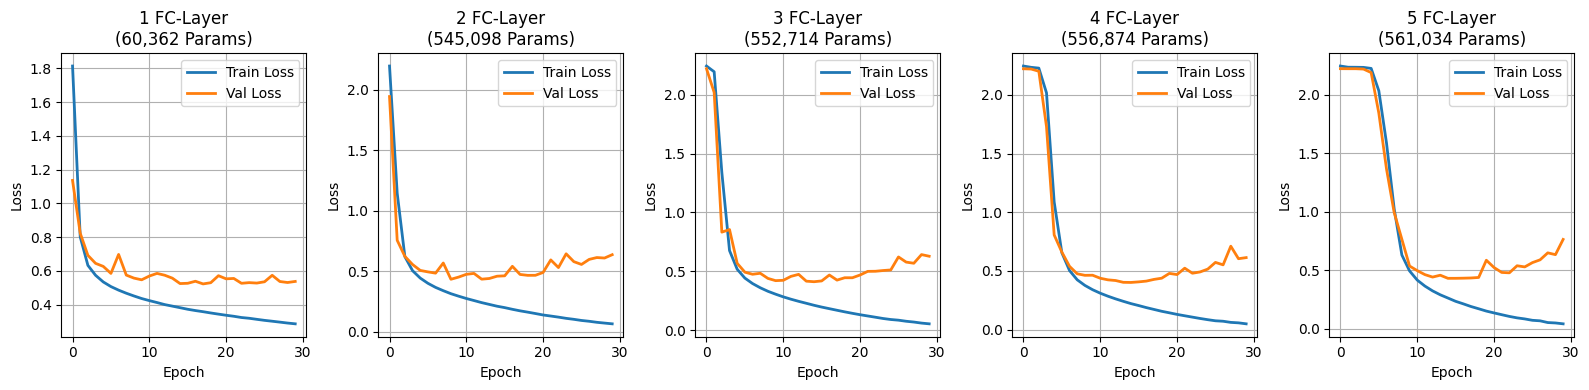

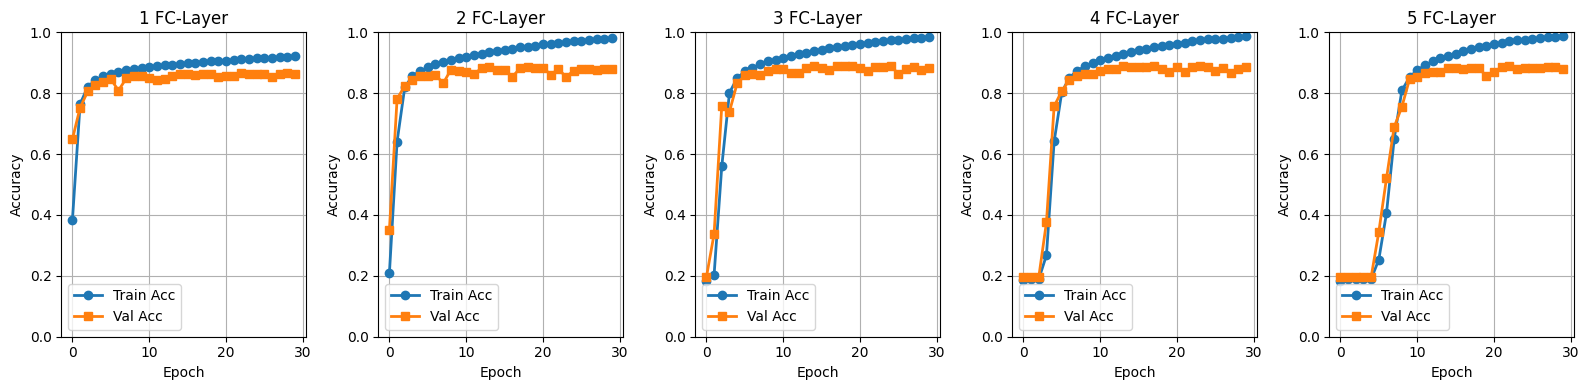

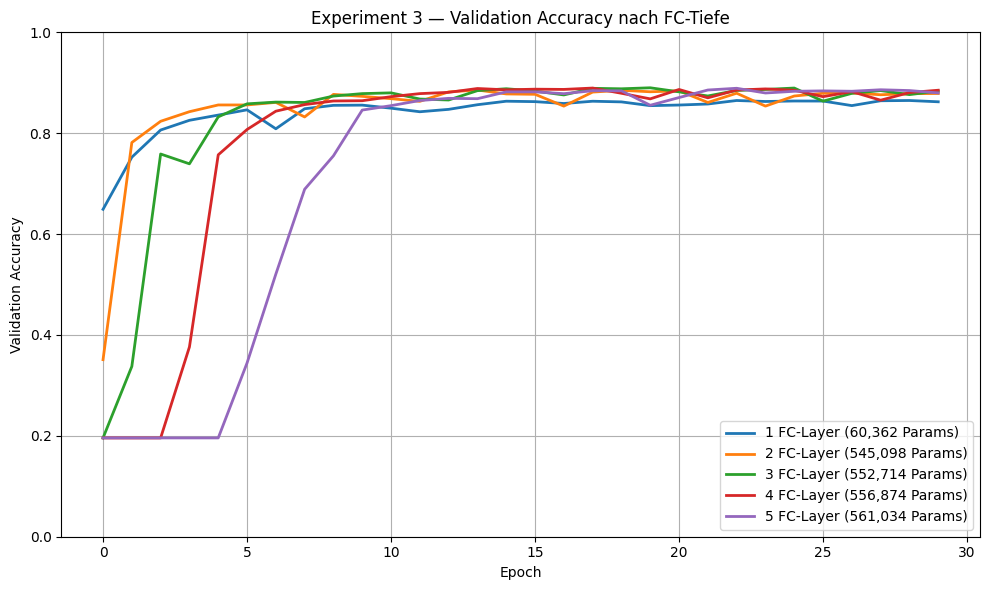

In [47]:
# Loss Kurven
fig, axes = plt.subplots(1, len(num_fc_layers_exp3), figsize=(16, 4))

for idx, n_fc in enumerate(num_fc_layers_exp3):
    res = results_exp3[n_fc]
    ax = axes[idx]
    epochs_range = range(len(res['train_loss']))

    ax.plot(epochs_range, res['train_loss'], label='Train Loss', linewidth=2)
    ax.plot(epochs_range, res['val_loss'],   label='Val Loss',   linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{n_fc} FC-Layer\n({res["n_params"]:,} Params)')
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.savefig('exp3_loss_curves.png', dpi=150)
plt.show()

# Accuracy Kurven
fig, axes = plt.subplots(1, len(num_fc_layers_exp3), figsize=(16, 4))

for idx, n_fc in enumerate(num_fc_layers_exp3):
    res = results_exp3[n_fc]
    ax = axes[idx]
    epochs_range = range(len(res['train_acc']))

    ax.plot(epochs_range, res['train_acc'], label='Train Acc', linewidth=2, marker='o')
    ax.plot(epochs_range, res['val_acc'],   label='Val Acc',   linewidth=2, marker='s')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{n_fc} FC-Layer')
    ax.set_ylim([0, 1])
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.savefig('exp3_accuracy_curves.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 6))

for n_fc, res in results_exp3.items():
    plt.plot(res['val_acc'],
             label=f'{n_fc} FC-Layer ({res["n_params"]:,} Params)',
             linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Experiment 3 — Validation Accuracy nach FC-Tiefe')
plt.legend()
plt.grid()
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('exp3_val_acc_comparison.png', dpi=150)
plt.show()

In [48]:
# Tabelare Zusammenfassung
print("\n" + "=" * 50)
print("EXPERIMENT 3 ERGEBNISSE")
print("=" * 50)
print(f"{'FC Layers':<15} {'# Params':<15} {'Final Val Acc':<20} {'Final Precision':<20} {'Final Recall':<20} {'Final F1-Score':<20}")
print("-" * 110)
for n_fc, res in results_exp3.items():
    print(f"{n_fc:<15} {res['n_params']:<15,} {res['final_val_acc']:<20.4f} "
          f"{res['final_precision']:<20.4f} {res['final_recall']:<20.4f} {res['final_f1']:<20.4f}")


EXPERIMENT 3 ERGEBNISSE
FC Layers       # Params        Final Val Acc        Final Precision      Final Recall         Final F1-Score      
--------------------------------------------------------------------------------------------------------------
1               60,362          0.8623               0.8666               0.8623               0.8627              
2               545,098         0.8788               0.8814               0.8788               0.8792              
3               552,714         0.8836               0.8850               0.8836               0.8838              
4               556,874         0.8852               0.8865               0.8852               0.8855              
5               561,034         0.8799               0.8817               0.8799               0.8795              


### Auswertung Experiment 3:
Es ist klar zu sehen, dass die Modelle mit mehr Fully Connected Layern deutlich mehr Parameter haben. Zwischen 2 und 4 Fully Connected Layern gibt es aber keinen grossen Unterschied in der Performance. Es ist jedoch klar ersichtlich, dass das Modell mit nur einem Fully Connected Layer deutlich schlechter Performt. Zudem fällt auf, dass der Loss auf den Testdaten weniger stark ansteigt je mehr Fully Connected Layer hinzugefügt werden. Dies aber bei gleichbleibender Accuracy. Daraus schliesse ich, das wir hier vielleicht ein ähnliches Phänomen wie zu beginn sehen, wo die Accuracy auf den Testdaten stabil bleibt aber der Loss ansteigt, also die falsch klassifizierten Bilder vielleicht mit einer höheren Unsicherheit klassifiziert werden.

Ich nehme deshalb 3 Fully Connected Layer für das finale Modell, da diese leicht besser Performen als nur ein und zwei Fully Connected Layer, aber gleichzeitig das Modell nicht unnötig kompliziert machen. Zudem ist auch ersichtlich, dass die Modelle mit 2 bis 4 FC im Training noch eine deutlich bessere Accuracy erreichen als das Modell mit nur einem FC.

## Experiment 4: Grössere Filterkernels
**Hypothese:**
Durch eine Vergrösserung der Filterkernels auf 5x5 oder 7x7 könnte die Performance des Modells verbessert werden, da das Modell dadurch in der Lage wäre, grössere Muster in den Bildern zu erkennen.

In diesem Experiment soll überprüft werden, ob die Performance des Modells durch die Verwendung von grösseren Filterkernels verbessert werden kann. Im Baselinemodell wurden bereits Filterkernels von 3x3 verwendet. Das Ziel ist nun, eine Bessere Performance zu erzielen, indem die Filterkernels auf 5x5 und 7x7 vergrössert werden.

Dabei sollen die restlichen Hyperparameter sowie die Architektur des Modells gleich bleiben, wie sie es im Baseline Modell sind, ausser dass die Filterkernels von 3x3 auf 5x5 vergrössert werden. Zudem wird das Padding so angepasst, dass die räumlichen Dimensionen der Bilder beibehalten werden, also von 1 auf 2 bzw. 3 erhöht.

Dazu muss folgendes gemacht werden:
- Das Baseline CNN muss erweitert werden, indem die Filterkernels von 3x3 auf 5x5 vergrössert werden.

In [49]:
class LargerFilterCNN(nn.Module):

    def __init__(self, kernel_size=3):

        super().__init__()

        pad = kernel_size // 2

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,kernel_size,padding=pad),        # 3 Input-Kanäle (RGB), 32 Filter mit 5x5, Padding 2
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size,padding=pad),       # 32 Input-Kanäle (von vorheriger Schicht), 64 Filter mit 5x5, Padding 2
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),                       # Flacht 3D-Tensor ab
            nn.Linear(64*8*8,128),              # 64*8*8 Eingabekanäle, 128 Ausgabekanäle   
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):

        x = self.conv(x)                        # Durchlaufen der Convolutional Layers
        x = self.fc(x)                          # Durchlaufen der Fully Connected Layers

        return x

In [50]:
# Experiment 4: Standard Hyperparameter, aber grössere Filter (5x5 statt 3x3)
# Hyperparameter
kernel_sizes_exp4 = [3, 5, 7]
results_exp4 = {}
max_epochs = 30
for k in kernel_sizes_exp4:
    torch.manual_seed(42)
    
    model_kernel = LargerFilterCNN(kernel_size=k).to(device)
    loader_kernel = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
    optimizer_kernel = optim.SGD(model_kernel.parameters(), lr=0.01)
    criterion_kernel = nn.CrossEntropyLoss()
    device_kernel = device
    writer_kernel = SummaryWriter(log_dir=f"./runs/experiment4/experiment4_kernel{k}")

    n_params = sum(p.numel() for p in model_kernel.parameters())
    print(f"\nTraining mit Kernel-Größe {k}x{k} ({n_params:,} Parameter)")
    print("-" * 50)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_precision': [],
        'val_recall': [],
        'val_f1': []
    }

    for epoch in range(max_epochs):
        train_loss, train_acc = train_epoch(
            model_kernel,
            loader_kernel,
            optimizer_kernel,
            criterion_kernel,
            device_kernel,
            writer=writer_kernel,
            epoch=epoch
        )

        val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
            model_kernel,
            test_loader,
            criterion_kernel,
            device_kernel,
            writer=writer_kernel,
            epoch=epoch
        )

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_precision'].append(val_precision)
        history['val_recall'].append(val_recall)
        history['val_f1'].append(val_f1)

        if epoch % 2 == 0:
            print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, "
                  f"Precision={val_precision:.4f}, Recall={val_recall:.4f}, F1={val_f1:.4f}")
    writer_kernel.close()
    
    results_exp4[k] = {
        **history,
        'final_val_acc': val_acc,
        'final_precision': val_precision,
        'final_recall': val_recall,
        'final_f1': val_f1,
        'n_params': n_params
    }


Training mit Kernel-Größe 3x3 (545,098 Parameter)
--------------------------------------------------
Epoch 0: Train Acc=0.2103, Val Acc=0.3559, Precision=0.3953, Recall=0.3559, F1=0.2565
Epoch 2: Train Acc=0.8215, Val Acc=0.8279, Precision=0.8354, Recall=0.8279, F1=0.8285
Epoch 4: Train Acc=0.8727, Val Acc=0.8572, Precision=0.8588, Recall=0.8572, F1=0.8572
Epoch 6: Train Acc=0.8953, Val Acc=0.8670, Precision=0.8698, Recall=0.8670, F1=0.8672
Epoch 8: Train Acc=0.9093, Val Acc=0.8654, Precision=0.8713, Recall=0.8654, F1=0.8664
Epoch 10: Train Acc=0.9215, Val Acc=0.8821, Precision=0.8829, Recall=0.8821, F1=0.8820
Epoch 12: Train Acc=0.9311, Val Acc=0.8838, Precision=0.8846, Recall=0.8838, F1=0.8837
Epoch 14: Train Acc=0.9406, Val Acc=0.8710, Precision=0.8797, Recall=0.8710, F1=0.8731
Epoch 16: Train Acc=0.9482, Val Acc=0.8831, Precision=0.8856, Recall=0.8831, F1=0.8832
Epoch 18: Train Acc=0.9541, Val Acc=0.8855, Precision=0.8857, Recall=0.8855, F1=0.8853
Epoch 20: Train Acc=0.9609, Val A

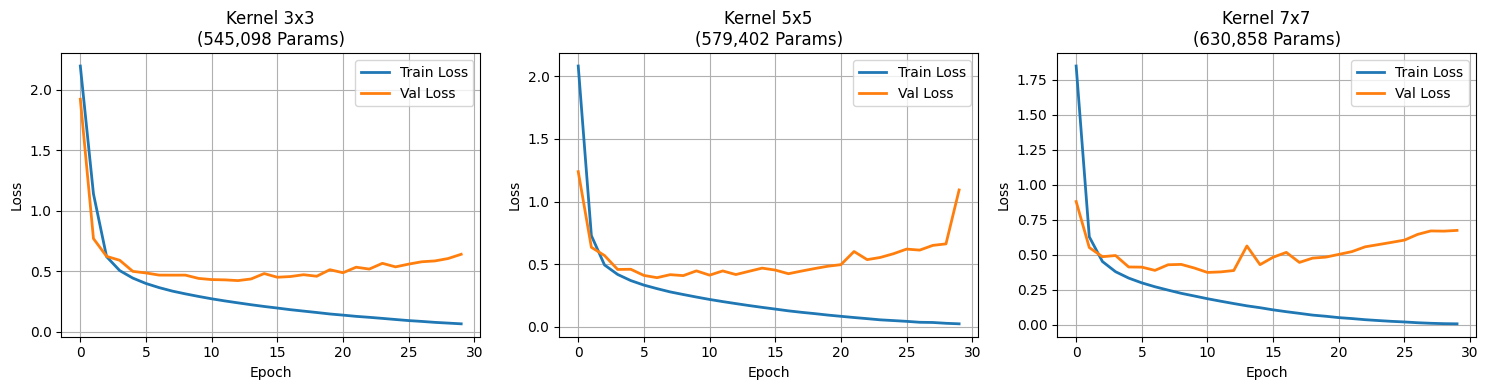

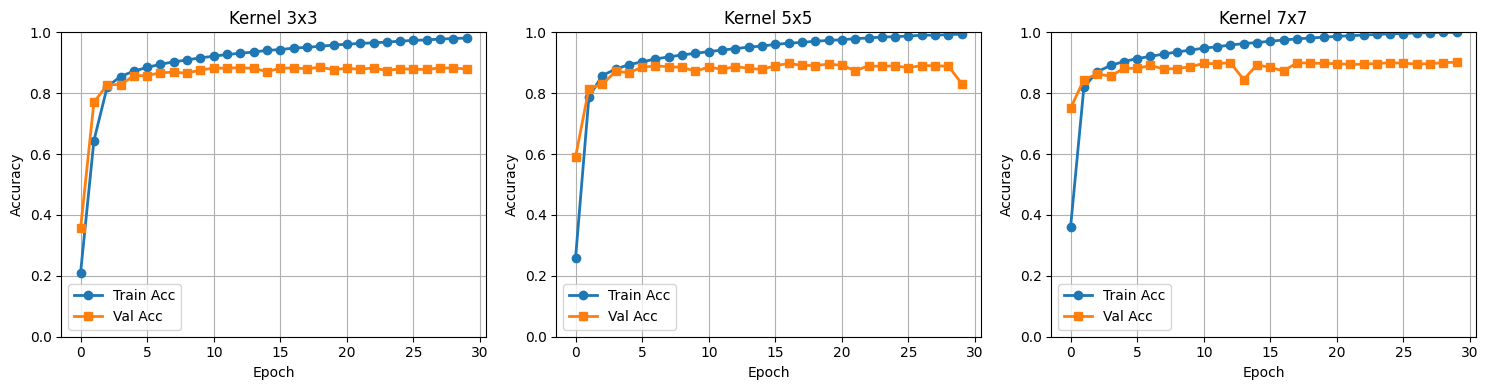

In [51]:
# Loss Kurven
fig, axes = plt.subplots(1, len(kernel_sizes_exp4), figsize=(15, 4))

for idx, k in enumerate(kernel_sizes_exp4):
    res = results_exp4[k]
    ax = axes[idx]
    epochs_range = range(len(res['train_loss']))

    ax.plot(epochs_range, res['train_loss'], label='Train Loss', linewidth=2)
    ax.plot(epochs_range, res['val_loss'],   label='Val Loss',   linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'Kernel {k}x{k}\n({res["n_params"]:,} Params)')
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.savefig('exp4_loss_curves.png', dpi=150)
plt.show()

# Accuracy Kurven
fig, axes = plt.subplots(1, len(kernel_sizes_exp4), figsize=(15, 4))

for idx, k in enumerate(kernel_sizes_exp4):
    res = results_exp4[k]
    ax = axes[idx]
    epochs_range = range(len(res['train_acc']))

    ax.plot(epochs_range, res['train_acc'], label='Train Acc', linewidth=2, marker='o')
    ax.plot(epochs_range, res['val_acc'],   label='Val Acc',   linewidth=2, marker='s')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Kernel {k}x{k}')
    ax.set_ylim([0, 1])
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.savefig('exp4_accuracy_curves.png', dpi=150)
plt.show()

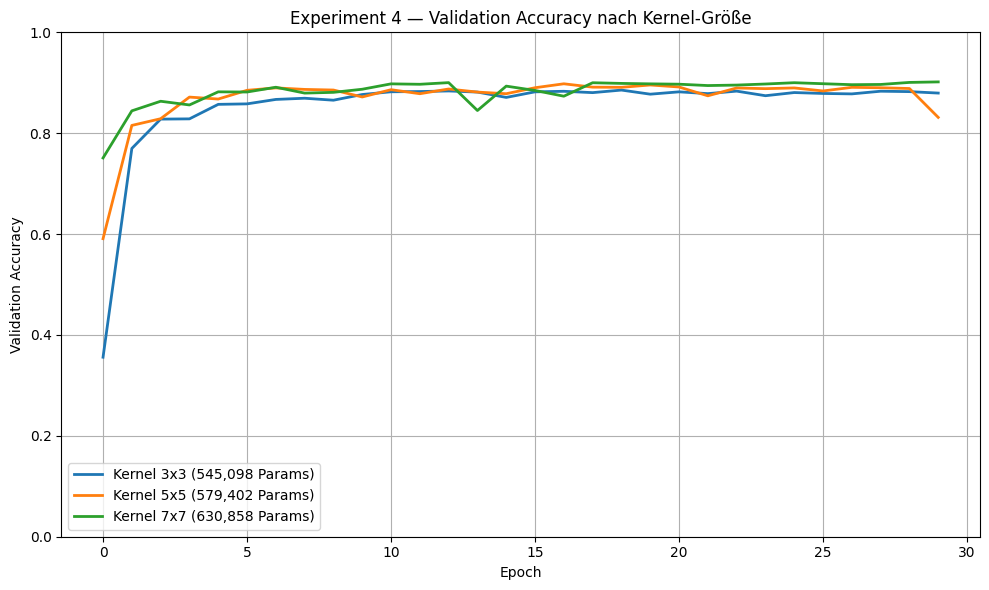

In [52]:
# Validation Accuracy aller Kernels
plt.figure(figsize=(10, 6))

for k, res in results_exp4.items():
    plt.plot(res['val_acc'],
             label=f'Kernel {k}x{k} ({res["n_params"]:,} Params)',
             linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Experiment 4 — Validation Accuracy nach Kernel-Größe')
plt.legend()
plt.grid()
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('exp4_val_acc_comparison.png', dpi=150)
plt.show()

In [53]:
# Tabelare Zusammenfassung
print("\n" + "=" * 50)
print("EXPERIMENT 4 ERGEBNISSE")
print("=" * 50)
print(f"{'Kernel':<10} {'Best Val Acc':<20} {'Final Precision':<20} {'Final Recall':<20} {'Final F1-Score':<20} {'# Params':<15}")
print("-" * 110)
for k, res in results_exp4.items():
    print(f"{f'{k}x{k}':<10} {res['final_val_acc']:<20.4f} {res['final_precision']:<20.4f} "
          f"{res['final_recall']:<20.4f} {res['final_f1']:<20.4f} {res['n_params']:<15,}")


EXPERIMENT 4 ERGEBNISSE
Kernel     Best Val Acc         Final Precision      Final Recall         Final F1-Score       # Params       
--------------------------------------------------------------------------------------------------------------
3x3        0.8796               0.8815               0.8796               0.8798               545,098        
5x5        0.8314               0.8517               0.8314               0.8284               579,402        
7x7        0.9017               0.9023               0.9017               0.9019               630,858        


### Auswertung Experiment 4:
Es ist zu sehen, dass die Performance des Modells mit grösseren Filterkernels etwas besser wird. Ich werde im finalen Modell Filterkernels von 5x5 verwenden, da diese etwas besser Performen als die Filterkernels von 3x3, aber gleichzeitig nicht so viele Parameter haben wie die Filterkernels von 7x7.

## Experiment 5: Dropout
**Hypothese:**
Durch die Verwendung von Dropout könnte die Performance des Modells verbessert werden. Dadurch sollte das Modell weniger overfitten und besser auf den Testdaten performen. Durch Dropout soll das Modell gezwungen werden besser zu generalisieren.

In diesem Experiment soll überprüft werden, ob die Performance des Modells durch die Verwendung von Dropout verbessert werden kann. Im Baselinemodell wurde kein Dropout verwendet. Verwendet wird auch hier wieder alles aus dem Baseline Modell, ausser dass Dropout mit verschiedenen Dropoutratenhinzugefügt wird. Das Dropout soll dabei in den Conv sowie in den FC Layern hinzugefügt werden. 

Dazu muss folgendes gemacht werden:
- Das Baseline CNN muss erweitert werden, indem Dropout hinzugefügt wird.

In [54]:
class DropoutCNN(nn.Module):

    def __init__(self, dropout_conv=0.25, dropout_fc=0.5):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),        # 3 Input-Kanäle (RGB), 32 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.Dropout(dropout_conv),                   # Dropout mit 25% Wahrscheinlichkeit
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),       # 32 Input-Kanäle (von vorheriger Schicht), 64 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.Dropout(dropout_conv),                   # Dropout mit 25% Wahrscheinlichkeit
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),                       # Flacht 3D-Tensor ab
            nn.Linear(64*8*8,128),              # 64*8*8 Eingabekanäle, 128 Ausgabekanäle   
            nn.ReLU(),
            nn.Dropout(dropout_fc),                    # Dropout mit 50% Wahrscheinlichkeit
            nn.Linear(128,10)
        )

    def forward(self,x):

        x = self.conv(x)                        # Durchlaufen der Convolutional Layers
        x = self.fc(x)                          # Durchlaufen der Fully Connected Layers

        return x

In [55]:
# Experiment 5: Dropout hinzufügen
# Hyperparameter
conv_dropouts_exp5 = [0.0, 0.25, 0.5]
fc_dropouts_exp5 = [0.0, 0.25, 0.5]
results_exp5 = {}
model_dropout = DropoutCNN().to(device)
loader_dropout = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
optimizer_dropout = optim.SGD(model_dropout.parameters(), lr=0.01)
criterion_dropout = nn.CrossEntropyLoss()
device_dropout = device

max_epochs = 30

for conv_p in conv_dropouts_exp5:
    for fc_p in fc_dropouts_exp5:
        torch.manual_seed(42)
        
        model_dropout = DropoutCNN(dropout_conv=conv_p, dropout_fc=fc_p).to(device)
        loader_dropout = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
        optimizer_dropout = optim.SGD(model_dropout.parameters(), lr=0.01)
        criterion_dropout = nn.CrossEntropyLoss()
        device_dropout = device
        writer_dropout = SummaryWriter(log_dir=f"./runs/experiment5/dropout_experiment5_conv{conv_p}_fc{fc_p}")
        
        print(f"\nTraining mit Conv-Dropout={conv_p}, FC-Dropout={fc_p}")
        print("-" * 50)

        history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'val_precision': [],
            'val_recall': [],
            'val_f1': []
        }

        for epoch in range(max_epochs):
            train_loss, train_acc = train_epoch(
                model_dropout,
                loader_dropout,
                optimizer_dropout,
                criterion_dropout,
                device_dropout,
                writer=writer_dropout,
                epoch=epoch
            )

            val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
                model_dropout,
                test_loader,
                criterion_dropout,
                device_dropout,
                writer=writer_dropout,
                epoch=epoch
            )

            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['val_precision'].append(val_precision)
            history['val_recall'].append(val_recall)
            history['val_f1'].append(val_f1)

            if epoch % 2 == 0:
                print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, "
                      f"Precision={val_precision:.4f}, Recall={val_recall:.4f}, F1={val_f1:.4f}")
                
        writer_dropout.close()

        results_exp5[(conv_p, fc_p)] = {
            **history,
            'final_val_acc': val_acc,
            'final_precision': val_precision,
            'final_recall': val_recall,
            'final_f1': val_f1
        }


Training mit Conv-Dropout=0.0, FC-Dropout=0.0
--------------------------------------------------
Epoch 0: Train Acc=0.2086, Val Acc=0.2916, Precision=0.3246, Recall=0.2916, F1=0.2008
Epoch 2: Train Acc=0.8186, Val Acc=0.7835, Precision=0.8068, Recall=0.7835, F1=0.7878
Epoch 4: Train Acc=0.8729, Val Acc=0.8443, Precision=0.8583, Recall=0.8443, F1=0.8466
Epoch 6: Train Acc=0.8940, Val Acc=0.8617, Precision=0.8653, Recall=0.8617, F1=0.8612
Epoch 8: Train Acc=0.9090, Val Acc=0.8724, Precision=0.8747, Recall=0.8724, F1=0.8723
Epoch 10: Train Acc=0.9204, Val Acc=0.8757, Precision=0.8789, Recall=0.8757, F1=0.8760
Epoch 12: Train Acc=0.9308, Val Acc=0.8773, Precision=0.8798, Recall=0.8773, F1=0.8774
Epoch 14: Train Acc=0.9387, Val Acc=0.8856, Precision=0.8859, Recall=0.8856, F1=0.8852
Epoch 16: Train Acc=0.9463, Val Acc=0.8811, Precision=0.8821, Recall=0.8811, F1=0.8809
Epoch 18: Train Acc=0.9535, Val Acc=0.8826, Precision=0.8837, Recall=0.8826, F1=0.8822
Epoch 20: Train Acc=0.9607, Val Acc=0

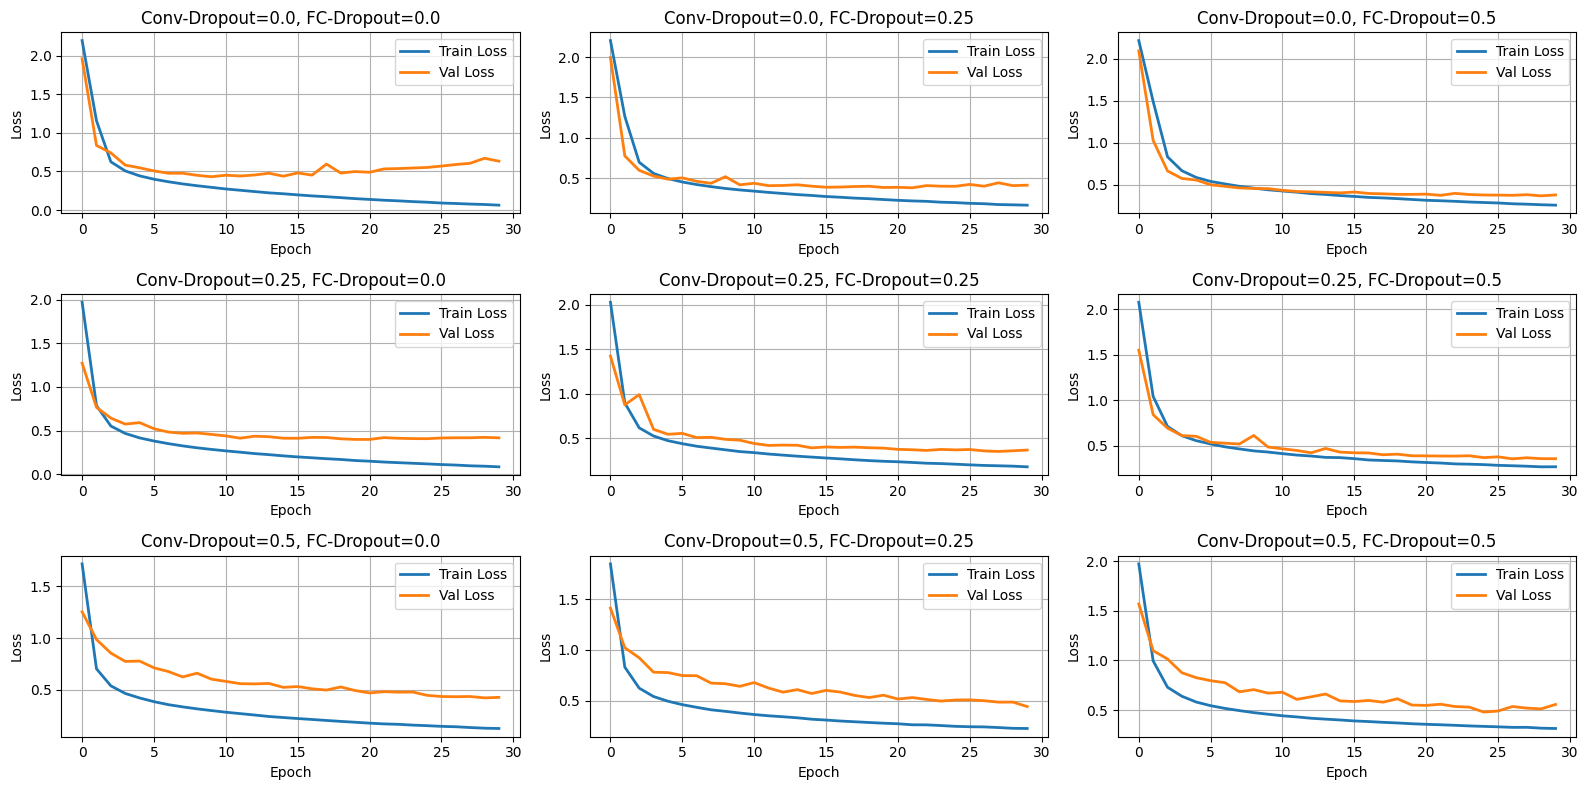

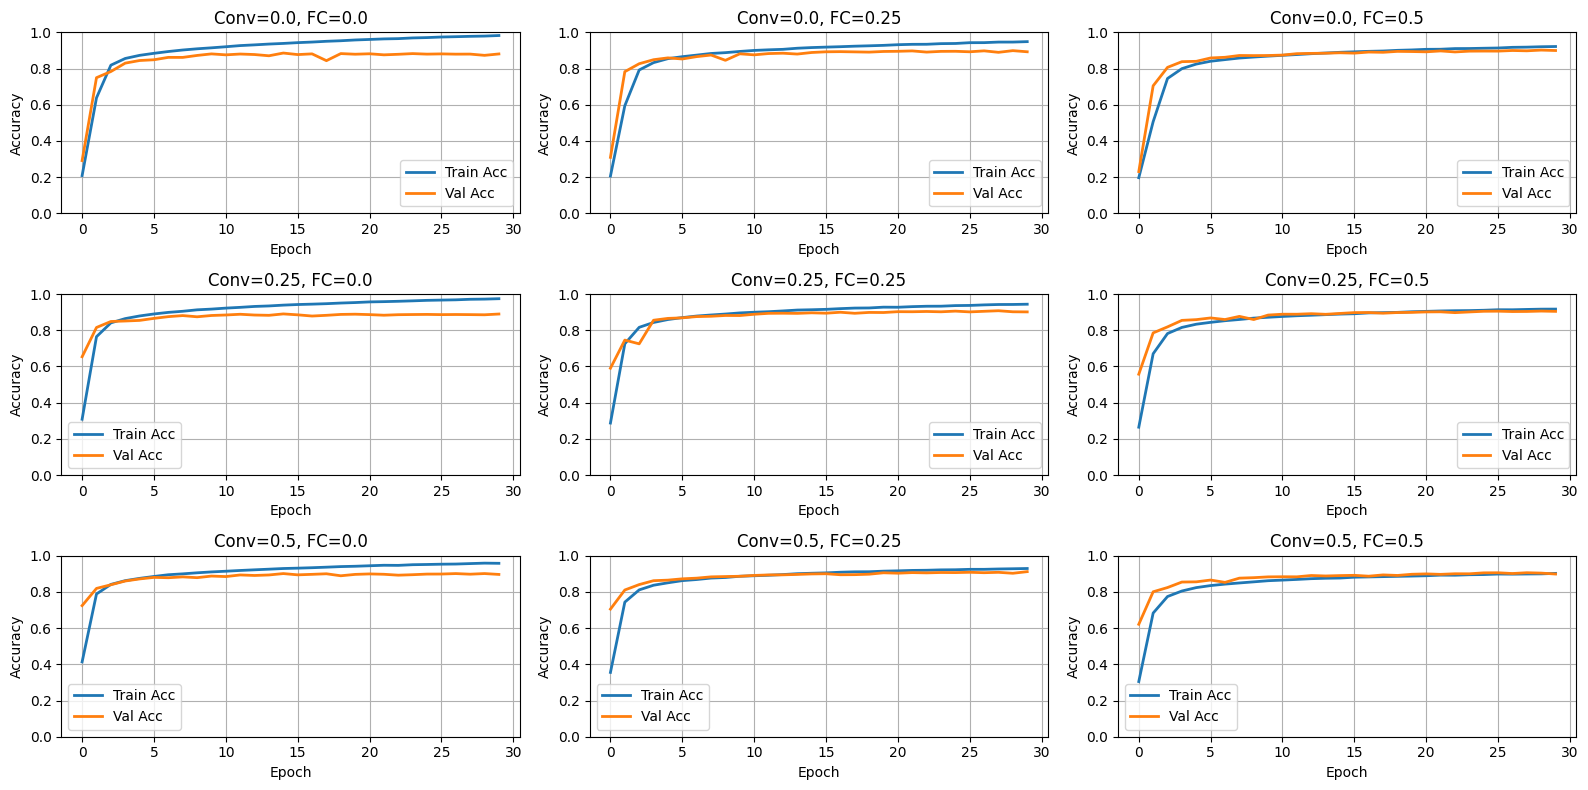

In [56]:
# Loss Kurven
fig, axes = plt.subplots(len(conv_dropouts_exp5), len(fc_dropouts_exp5), figsize=(16, 8))

for i, conv_p in enumerate(conv_dropouts_exp5):
    for j, fc_p in enumerate(fc_dropouts_exp5):
        res = results_exp5[(conv_p, fc_p)]
        ax = axes[i, j]
        epochs_range = range(len(res['train_loss']))
        
        ax.plot(epochs_range, res['train_loss'], label='Train Loss', linewidth=2)
        ax.plot(epochs_range, res['val_loss'],   label='Val Loss',   linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(f'Conv-Dropout={conv_p}, FC-Dropout={fc_p}')
        ax.legend()
        ax.grid()

plt.tight_layout()
plt.savefig('exp5_loss_curves.png', dpi=150)
plt.show()

# Accuracy Kurven
fig, axes = plt.subplots(len(conv_dropouts_exp5), len(fc_dropouts_exp5), figsize=(16, 8))

for i, conv_p in enumerate(conv_dropouts_exp5):
    for j, fc_p in enumerate(fc_dropouts_exp5):
        res = results_exp5[(conv_p, fc_p)]
        ax = axes[i, j]
        epochs_range = range(len(res['train_acc']))
        
        ax.plot(epochs_range, res['train_acc'], label='Train Acc', linewidth=2)
        ax.plot(epochs_range, res['val_acc'],   label='Val Acc',   linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'Conv={conv_p}, FC={fc_p}')
        ax.set_ylim([0, 1])
        ax.legend()
        ax.grid()

plt.tight_layout()
plt.savefig('exp5_accuracy_curves.png', dpi=150)
plt.show()

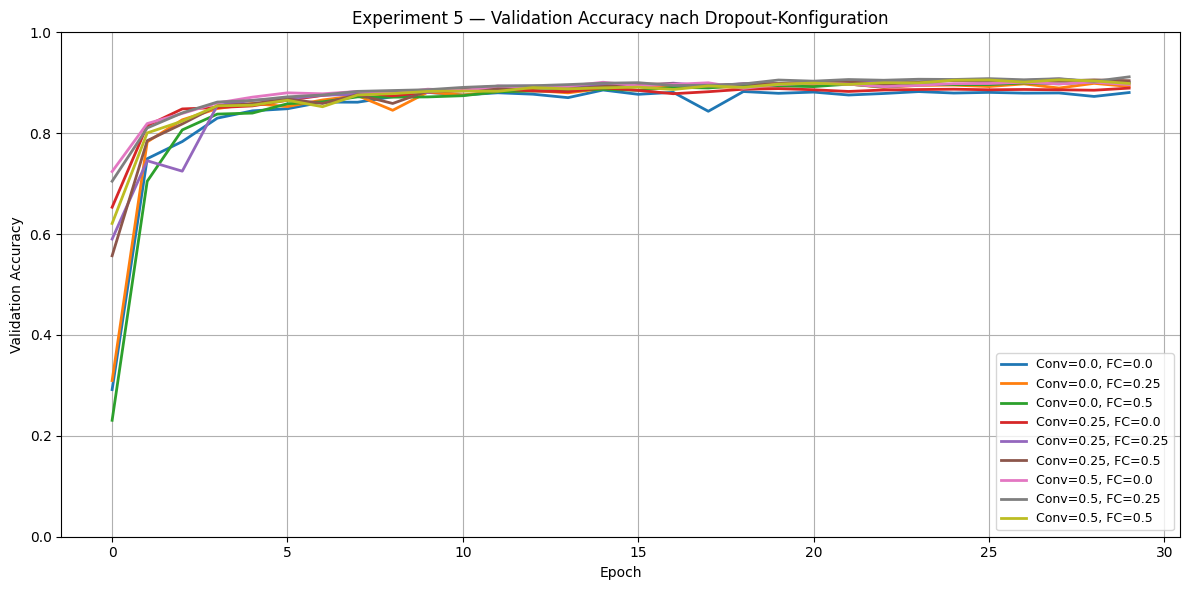

In [57]:
plt.figure(figsize=(12, 6))

for (conv_p, fc_p), res in results_exp5.items():
    plt.plot(res['val_acc'],
             label=f'Conv={conv_p}, FC={fc_p}',
             linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Experiment 5 — Validation Accuracy nach Dropout-Konfiguration')
plt.legend(loc='lower right', fontsize=9)
plt.grid()
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('exp5_val_acc_comparison.png', dpi=150)
plt.show()

In [58]:
# Tabelare Zusammenfassung
print("\n" + "=" * 50)
print("EXPERIMENT 5 ERGEBNISSE")
print("=" * 50)
print(f"{'Modell':<20} {'Final Val Acc':<20} {'Final Precision':<20} {'Final Recall':<20} {'Final F1-Score':<20}")
print("-" * 100)
for (conv_p, fc_p), res in results_exp5.items():
    model_name = f"Conv={conv_p}, FC={fc_p}"
    print(f"{model_name:<20} {res['final_val_acc']:<20.4f} {res['final_precision']:<20.4f} "
          f"{res['final_recall']:<20.4f} {res['final_f1']:<20.4f}")


EXPERIMENT 5 ERGEBNISSE
Modell               Final Val Acc        Final Precision      Final Recall         Final F1-Score      
----------------------------------------------------------------------------------------------------
Conv=0.0, FC=0.0     0.8806               0.8826               0.8806               0.8811              
Conv=0.0, FC=0.25    0.8926               0.8938               0.8926               0.8924              
Conv=0.0, FC=0.5     0.8996               0.9000               0.8996               0.8992              
Conv=0.25, FC=0.0    0.8894               0.8899               0.8894               0.8894              
Conv=0.25, FC=0.25   0.9011               0.9030               0.9011               0.9015              
Conv=0.25, FC=0.5    0.9041               0.9045               0.9041               0.9040              
Conv=0.5, FC=0.0     0.8964               0.8992               0.8964               0.8968              
Conv=0.5, FC=0.25    0.9118       

### Auswertung Experiment 5:
Es ist klar zu sehen, dass die generalisierung des Modells mit hilfe von Dropout deutlich verbessert wird. Die beiden Kurven sind jeweils deutlich näher beieinander, was darauf hindeutet, dass das Modell weniger overfittet. Zudem ist auch die Performance des Modells auf den Testdaten deutlich besser. Was auffällt, ist dass eine höhere Dropoutrate im FC und eine niedrigere Dropoutrate in den Conv Layern zu einer besseren Performance führt. Dies könnte daran liegen, dass die Fully Connected Layer mehr Parameter haben und dadurch eher zum overfitten neigen, weshalb hier eine höhere Dropoutrate sinnvoll ist.

Für das finale Modell werde ich definitiv dropout verwenden. Dabei werde ich eine Dropoutrate von 0.5 im Fully Connected Layer und eine Dropoutrate von 0.25 in den Convolutional Layern verwenden, da diese Kombination die beste Performance erzielt hat.

## Experiment 6: Augmentation
**Hypothese:**
Die Bilder sollen mit verschiedenen Augmentationstechniken wie Rotation, Skalierung und Verschiebung augmentiert werden, um die Performance des Modells zu verbessern. Wichtig dabei ist, dass die Augmentationstechniken so gewählt werden, dass sie realistische Variationen der Bilder erzeugen (Beispielsweise kein Flippen). Durch die Augmentation soll die Anzahl der Trainingsbeispiele erhöht werden und auch die Robustheit des Modells verbessert werden weil das Modell dadurch besser mit Variation umgehen kann.

In diesem Experiment soll überprüft werden, ob die Performance des Modells durch die Verwendung von Augmentation verbessert werden kann. Durch die Augmentation soll die Anzahl der Trainingsbeispiele erhöht werden und auch die Robustheit des Modells verbessert werden weil das Modell dadurch besser mit Variation umgehen kann.

Dazu muss folgendes gemacht werden:
- Es müssen verschiedene Augmentationstechniken wie Rotation, Skalierung und Verschiebung implementiert werden, um die Bilder zu augmentieren. Dabei sollten die Augmentationstechniken so gewählt werden, dass sie realistische Variationen der Bilder erzeugen (Beispielsweise kein Flippen).

Epoch 0: Train Acc=0.1888, Test Acc=0.1958, Test Precision=0.0384, Test Recall=0.1958, Test F1=0.0642
Epoch 2: Train Acc=0.2052, Test Acc=0.2651, Test Precision=0.2428, Test Recall=0.2651, Test F1=0.1666
Epoch 4: Train Acc=0.3553, Test Acc=0.5937, Test Precision=0.5954, Test Recall=0.5937, Test F1=0.5685
Epoch 6: Train Acc=0.5274, Test Acc=0.6947, Test Precision=0.7161, Test Recall=0.6947, Test F1=0.6929
Epoch 8: Train Acc=0.6265, Test Acc=0.7355, Test Precision=0.7455, Test Recall=0.7355, Test F1=0.7324
Epoch 10: Train Acc=0.6829, Test Acc=0.7528, Test Precision=0.7629, Test Recall=0.7528, Test F1=0.7502
Epoch 12: Train Acc=0.7170, Test Acc=0.8087, Test Precision=0.8154, Test Recall=0.8087, Test F1=0.8075
Epoch 14: Train Acc=0.7451, Test Acc=0.8061, Test Precision=0.8101, Test Recall=0.8061, Test F1=0.7989
Epoch 16: Train Acc=0.7636, Test Acc=0.8331, Test Precision=0.8368, Test Recall=0.8331, Test F1=0.8306
Epoch 18: Train Acc=0.7793, Test Acc=0.8471, Test Precision=0.8495, Test Recal

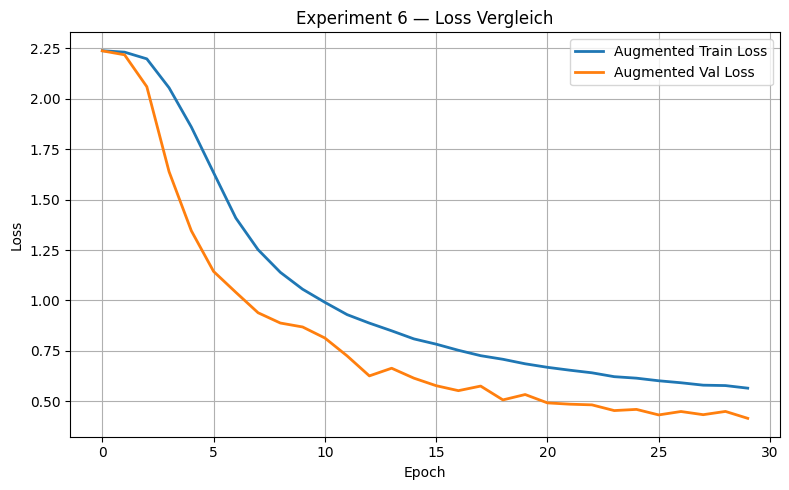

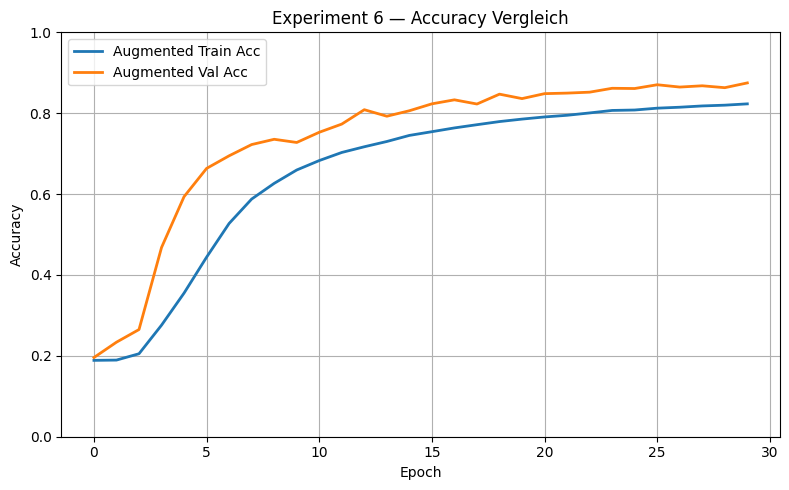

In [59]:
# Experiment 6: Datenaugmentation hinzufügen
# Trainingsdatensatz mit Augmentation
transform_augmented = transforms.Compose([
    transforms.RandomRotation(30),          # Zufällige Rotation um bis zu 30 Grad
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)), # Zufällige Verschiebung um bis zu 20% in x- und y-Richtung
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Zufällige Farbänderungen
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Keine Augmentation für den Testdatensatz
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Erzeugen der neuen Datensätze
train_dataset_augmented = torchvision.datasets.SVHN(
    root='./data',
    split='train',
    transform=transform_augmented
)

test_dataset_augmented = torchvision.datasets.SVHN(
    root='./data',
    split='test',
    transform=transform_test
)

# DataLoader für die augmentierten Datensätze
train_loader_augmented = DataLoader(train_dataset_augmented, batch_size=32, shuffle=True, generator=g)
test_loader_augmented = DataLoader(test_dataset_augmented, batch_size=32, shuffle=False, generator=g)

model_augmented = BaselineCNN().to(device)
optimizer_augmented = optim.SGD(model_augmented.parameters(), lr=0.01)
criterion_augmented = nn.CrossEntropyLoss()
device_augmented = device
writer_augmented = SummaryWriter(log_dir="./runs/experiment6/augmented_experiment6")

max_epochs = 30

history_aug = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': []
}

for epoch in range(max_epochs):
    train_loss, train_acc = train_epoch(
        model_augmented,
        train_loader_augmented,
        optimizer_augmented,
        criterion_augmented,
        device_augmented,
        writer=writer_augmented,
        epoch=epoch
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model_augmented,
        test_loader_augmented,
        criterion_augmented,
        device_augmented,
        writer=writer_augmented,
        epoch=epoch
    )

    history_aug['train_loss'].append(train_loss)
    history_aug['train_acc'].append(train_acc)
    history_aug['val_loss'].append(val_loss)
    history_aug['val_acc'].append(val_acc)
    history_aug['val_precision'].append(val_precision)
    history_aug['val_recall'].append(val_recall)
    history_aug['val_f1'].append(val_f1)

    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={val_acc:.4f}, Test Precision={val_precision:.4f}, Test Recall={val_recall:.4f}, Test F1={val_f1:.4f}")

results_exp6 = {**history_aug, 
                'final_val_acc': val_acc,
                'final_precision': val_precision,
                'final_recall': val_recall,
                'final_f1': val_f1
                 }
writer_augmented.close()

# Loss Kurve
plt.figure(figsize=(8, 5))
plt.plot(results_exp6['train_loss'], label='Augmented Train Loss', linewidth=2)
plt.plot(results_exp6['val_loss'],   label='Augmented Val Loss',   linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Experiment 6 — Loss Vergleich')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('exp6_loss_comparison.png', dpi=150)
plt.show()

# Accuracy Kurve
plt.figure(figsize=(8, 5))
plt.plot(results_exp6['train_acc'], label='Augmented Train Acc', linewidth=2)
plt.plot(results_exp6['val_acc'], label='Augmented Val Acc', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Experiment 6 — Accuracy Vergleich')
plt.legend()
plt.grid()
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('exp6_accuracy_comparison.png', dpi=150)
plt.show()


In [60]:
# Tabelare Zusammenfassung
print("\n" + "=" * 50)
print("EXPERIMENT 6 ERGEBNISSE")
print("=" * 50)
print(f"{'Modell':<20} {'Final Val Acc':<20} {'Final Precision':<20} {'Final Recall':<20} {'Final F1-Score':<20}")
print("-" * 100)
model_name = "Mit Datenaugmentation"
print(f"{model_name:<20} {results_exp6['final_val_acc']:<20.4f} {results_exp6['final_precision']:<20.4f} "      f"{results_exp6['final_recall']:<20.4f} {results_exp6['final_f1']:<20.4f}")


EXPERIMENT 6 ERGEBNISSE
Modell               Final Val Acc        Final Precision      Final Recall         Final F1-Score      
----------------------------------------------------------------------------------------------------
Mit Datenaugmentation 0.8749               0.8759               0.8749               0.8747              


### Auswertung Experiment 6:
Durch die Augmentation konnte die Performance des Modells nicht verbessert werden. Die Augmentation könnte die Bilder zu stark verändern, weshalb das Modell Schwierigkeiten hat die Muster in den Bildern zu erkennen. Ich verwerfe deshalb für das finale Modell die Augmentation, da diese in diesem Fall nicht zu einer besseren Performance geführt hat.

## Experiment 7: Batch Normalization hinzufügen
**Hypothese:**
Durch die Verwendung von Batch Normalization soll die Performance des Modells verbessert werden, da dadurch die Trainingsstabilität erhöht wird und das Modell schneller konvergieren könnte. Diese stabilität geschieht bei Batch Normalization dadurch, dass die Verteilung der Aktivierungen in den einzelnen Layern normalisiert wird, was dazu führt, dass das Modell schneller und stabiler konvergieren kann.

Die restlichen Parameter bleiben auch hier gleich wie im Baseline Modell, ausser dass Batch Normalization in den Convolutional Layern hinzugefügt wird. Dabei wird Batch Normalization jeweils nach der ReLU Aktivierungsfunktion hinzugefügt.

Dazu muss folgendes gemacht werden:
- Das Baseline CNN muss erweitert werden, indem Batch Normalization in den Convolutional Layern hinzugefügt wird.

In [61]:
class BatchNormCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),        # 3 Input-Kanäle (RGB), 32 Filter mit 3x3, Padding 1
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),       # 32 Input-Kanäle (von vorheriger Schicht), 64 Filter mit 3x3, Padding 1
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),                       # Flacht 3D-Tensor ab
            nn.Linear(64*8*8,128),              # 64*8*8 Eingabekanäle, 128 Ausgabekanäle   
            nn.ReLU(),
            nn.Dropout(0.5),                    # Dropout mit 50% Wahrscheinlichkeit
            nn.Linear(128,10)
        )

    def forward(self,x):

        x = self.conv(x)                        # Durchlaufen der Convolutional Layers
        x = self.fc(x)                          # Durchlaufen der Fully Connected Layers

        return x

Epoch 0: Train Acc=0.6457, Test Acc=0.7798, Test Precision=0.8064, Test Recall=0.7798, Test F1=0.7799
Epoch 2: Train Acc=0.8315, Test Acc=0.8561, Test Precision=0.8582, Test Recall=0.8561, Test F1=0.8548
Epoch 4: Train Acc=0.8565, Test Acc=0.8651, Test Precision=0.8652, Test Recall=0.8651, Test F1=0.8639
Epoch 6: Train Acc=0.8716, Test Acc=0.8807, Test Precision=0.8810, Test Recall=0.8807, Test F1=0.8800
Epoch 8: Train Acc=0.8793, Test Acc=0.8856, Test Precision=0.8857, Test Recall=0.8856, Test F1=0.8851
Epoch 10: Train Acc=0.8896, Test Acc=0.8926, Test Precision=0.8931, Test Recall=0.8926, Test F1=0.8921
Epoch 12: Train Acc=0.8983, Test Acc=0.8903, Test Precision=0.8912, Test Recall=0.8903, Test F1=0.8902
Epoch 14: Train Acc=0.9014, Test Acc=0.8885, Test Precision=0.8918, Test Recall=0.8885, Test F1=0.8885
Epoch 16: Train Acc=0.9093, Test Acc=0.8946, Test Precision=0.8952, Test Recall=0.8946, Test F1=0.8946
Epoch 18: Train Acc=0.9143, Test Acc=0.9004, Test Precision=0.9013, Test Recal

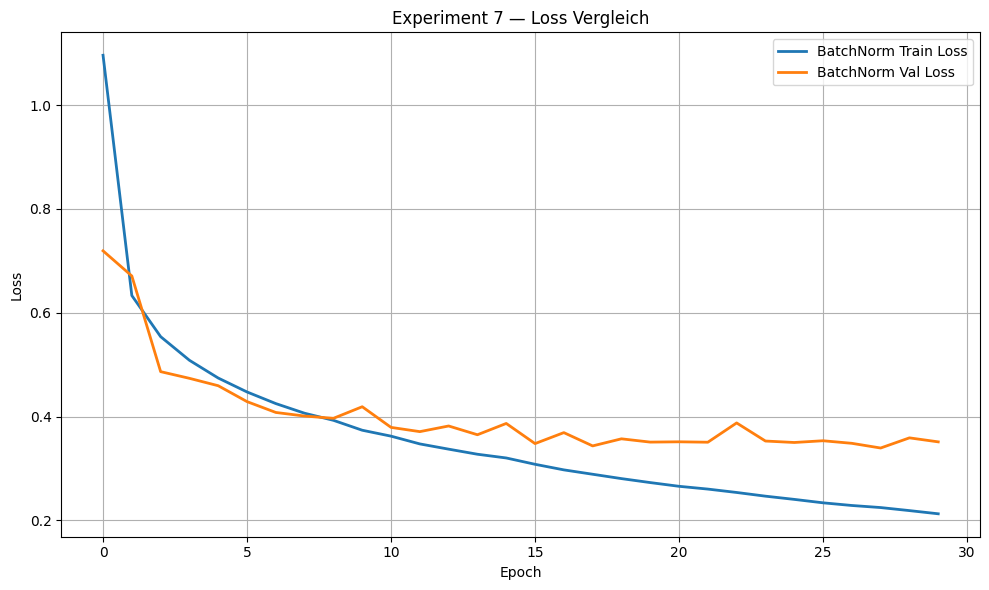

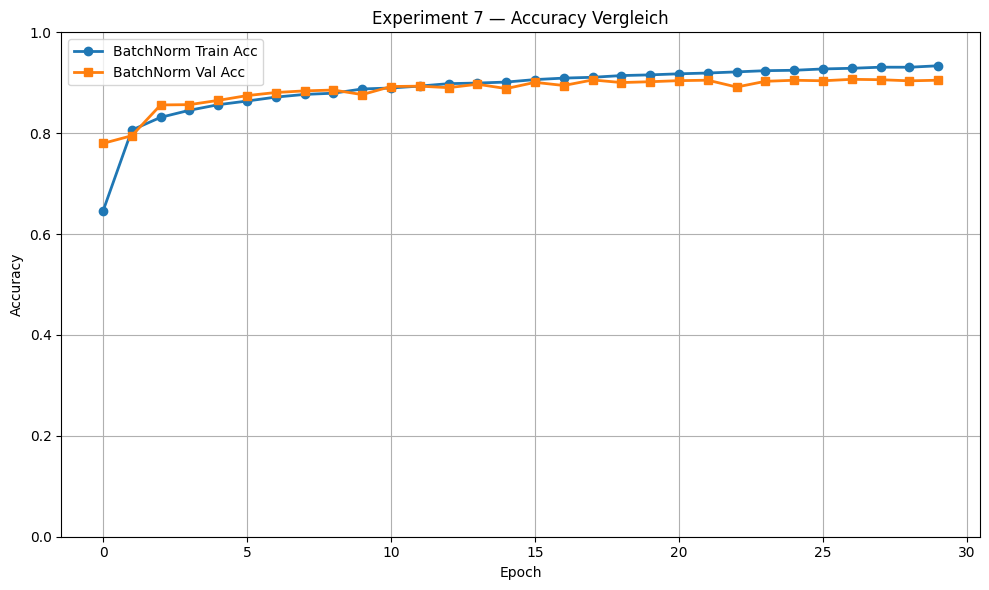

In [62]:
# Experiment 7: Batch Normalization hinzufügen
model_batchnorm = BatchNormCNN().to(device)
loader_batchnorm = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
optimizer_batchnorm = optim.SGD(model_batchnorm.parameters(), lr=0.01)
criterion_batchnorm = nn.CrossEntropyLoss()
device_batchnorm = device
writer_batchnorm = SummaryWriter(log_dir="./runs/experiment7/batchnorm_experiment7")

max_epochs = 30

history_bn = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': []
}

for epoch in range(max_epochs):
    train_loss, train_acc = train_epoch(
        model_batchnorm,
        loader_batchnorm,
        optimizer_batchnorm,
        criterion_batchnorm,
        device_batchnorm,
        writer=writer_batchnorm,
        epoch=epoch
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model_batchnorm,
        test_loader,
        criterion_batchnorm,
        device_batchnorm,
        writer=writer_batchnorm,
        epoch=epoch
    )

    history_bn['train_loss'].append(train_loss)
    history_bn['train_acc'].append(train_acc)
    history_bn['val_loss'].append(val_loss)
    history_bn['val_acc'].append(val_acc)
    history_bn['val_precision'].append(val_precision)
    history_bn['val_recall'].append(val_recall)
    history_bn['val_f1'].append(val_f1)

    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={val_acc:.4f}, Test Precision={val_precision:.4f}, Test Recall={val_recall:.4f}, Test F1={val_f1:.4f}")

results_exp7 = {**history_bn,
                'final_val_acc': val_acc,
                'final_precision': val_precision,
                'final_recall': val_recall,
                'final_f1': val_f1
                 }
writer_batchnorm.close()

# Loss Kurven
plt.figure(figsize=(10, 6))
plt.plot(results_exp7['train_loss'], label='BatchNorm Train Loss', linewidth=2)
plt.plot(results_exp7['val_loss'],   label='BatchNorm Val Loss',   linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Experiment 7 — Loss Vergleich')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('exp7_loss_comparison.png', dpi=150)
plt.show()

# Accuracy Kurven
plt.figure(figsize=(10, 6))
plt.plot(results_exp7['train_acc'], label='BatchNorm Train Acc', linewidth=2, marker='o')
plt.plot(results_exp7['val_acc'], label='BatchNorm Val Acc', linewidth=2, marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Experiment 7 — Accuracy Vergleich')
plt.legend()
plt.grid()
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('exp7_accuracy_comparison.png', dpi=150)
plt.show()

In [63]:
# Tabelare Zusammenfassung
print("\n" + "=" * 50)
print("EXPERIMENT 7 ERGEBNISSE")
print("=" * 50)
print(f"{'Modell':<20} {'Final Val Acc':<20} {'Final Precision':<20} {'Final Recall':<20} {'Final F1-Score':<20}")
print("-" * 100)
print(f"{'BatchNorm':<20} {results_exp7['final_val_acc']:<20.4f} "
      f"{results_exp7['final_precision']:<20.4f} "
      f"{results_exp7['final_recall']:<20.4f} "
      f"{results_exp7['final_f1']:<20.4f}")


EXPERIMENT 7 ERGEBNISSE
Modell               Final Val Acc        Final Precision      Final Recall         Final F1-Score      
----------------------------------------------------------------------------------------------------
BatchNorm            0.9051               0.9056               0.9051               0.9046              


### Auswertung Experiment 7:
Es ist zu sehen, dass die Performance des Modells mit Batch Normalization deutlich verbessert wird. Es ist zudem auffallend, dass die Kurven von Training und Test deutlich näher beieinander liegen, was darauf hindeutet, dass das Modell mit Batch Normalization weniger overfittet. Das Modell sieht auch so aus, als ob es nach 30 Epochen noch nicht vollständig konvergiert ist, weshalb es durchaus sein könnte, dass die Performance mit einer längeren Trainingszeit noch weiter verbessert werden könnte. Aufgrund der besseren Performance des Modells mit Batch Normalization, werde ich Batch Normalization in meinem finalen Modell verwenden.

## Experiment 8: Gewichtsinitialisierung
**Hypothese:**
Die gewichte sollen zufällig mit einer Normalverteilung initialisiert werden. Hierbei wird das Modell schlechter als mit der Standard Initialisierung des Frameworks performen, da die Gewichte nicht optimal initialisiert werden und das Modell dadurch länger braucht um zu konvergieren und in den ersten Layern nicht gross geupdatet wird von der Backpropagation.

In diesem Experiment soll die Initialisierung der Gewichte überschrieben werden. Normalerweise wird in PyTorch die Initialisierung der Gewichte automatisch gemacht. Laut (https://apxml.com/courses/pytorch-for-tensorflow-developers/chapter-2-pytorch-nn-module-for-keras-users/weight-initialization-pytorch/) werden die Gewichte in den Linear und Conv Layern mit Kaiman Initialisierung initialisiert. Der Bias wird normalerweise mit 0 initialisiert. Das Ziel ist nun herauszufinden ob und um wie viel sich das Modell verschlechtert, wenn anstatt der Kaiman Initialisierung eine zufällige Initialisierung mit einer Normalverteilung gemacht wird. 

Dabei soll die Initialisierung der Gewichte in den Convolutional und Fully Connected Layern überschrieben werden, indem die Gewichte mit einer Normalverteilung mit einem Mittelwert von 0 und einer Standardabweichung von 1 initialisiert werden. Der Bias soll weiterhin mit 0 initialisiert werden. Die restliche Architektur sowie die Hyperparameter des Modells sollen gleich bleiben wie im Baseline Modell.

Dazu muss folgendes gemacht werden:
- Neue Initialisierung der Gewichte im Conv Layer
- Neue Initialisierung der Gewichte im FC Layer
- Initialisierung des Bias mit 0

In [64]:
class CustomInitCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),        # 3 Input-Kanäle (RGB), 32 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),       # 32 Input-Kanäle (von vorheriger Schicht), 64 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),                       # Flacht 3D-Tensor ab
            nn.Linear(64*8*8,128),              # 64*8*8 Eingabekanäle, 128 Ausgabekanäle   
            nn.ReLU(),
            nn.Linear(128,10)
        )

        # Angepasste Initialisierung der Gewichte
        self.__init_weights()

    def __init_weights(self):
        """Initialisiert alle Gewichte mit Normalverteilung (mu=0, sigma=1)"""
        for layer in self.modules():
            if isinstance(layer, nn.Conv2d):
                nn.init.normal_(layer.weight, mean=0.0, std=1.0)
                if layer.bias is not None:
                    nn.init.constant_(layer.bias, 0.0)
            
            elif isinstance(layer, nn.Linear):
                nn.init.normal_(layer.weight, mean=0.0, std=1.0)
                if layer.bias is not None:
                    nn.init.constant_(layer.bias, 0.0)

    def forward(self,x):

        x = self.conv(x)                        # Durchlaufen der Convolutional Layers
        x = self.fc(x)                          # Durchlaufen der Fully Connected Layers

        return x


Epoch 0: Train Acc=0.1124, Test Acc=0.1313, Test Precision=0.1306, Test Recall=0.1313, Test F1=0.1298
Epoch 2: Train Acc=0.1319, Test Acc=0.1303, Test Precision=0.1309, Test Recall=0.1303, Test F1=0.1295
Epoch 4: Train Acc=0.1309, Test Acc=0.1288, Test Precision=0.1303, Test Recall=0.1288, Test F1=0.1290
Epoch 6: Train Acc=0.1343, Test Acc=0.1406, Test Precision=0.1215, Test Recall=0.1406, Test F1=0.1056
Epoch 8: Train Acc=0.1595, Test Acc=0.1568, Test Precision=0.1122, Test Recall=0.1568, Test F1=0.0516
Epoch 10: Train Acc=0.1596, Test Acc=0.1109, Test Precision=0.1217, Test Recall=0.1109, Test F1=0.0274
Epoch 12: Train Acc=0.1608, Test Acc=0.1588, Test Precision=0.1194, Test Recall=0.1588, Test F1=0.0470
Epoch 14: Train Acc=0.1589, Test Acc=0.1589, Test Precision=0.1210, Test Recall=0.1589, Test F1=0.0463
Epoch 16: Train Acc=0.1580, Test Acc=0.0914, Test Precision=0.0878, Test Recall=0.0914, Test F1=0.0170
Epoch 18: Train Acc=0.1622, Test Acc=0.1589, Test Precision=0.1020, Test Recal

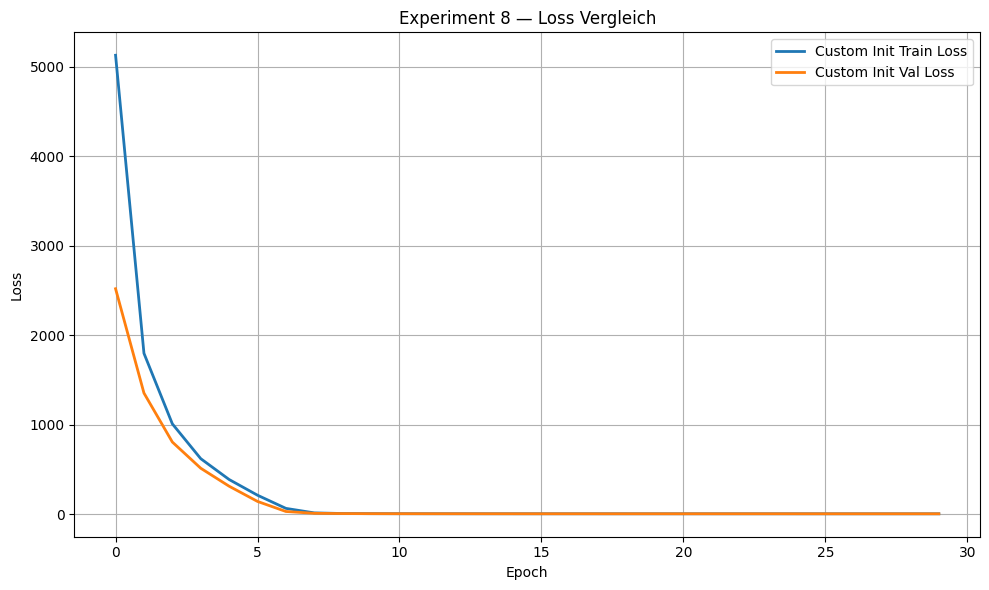

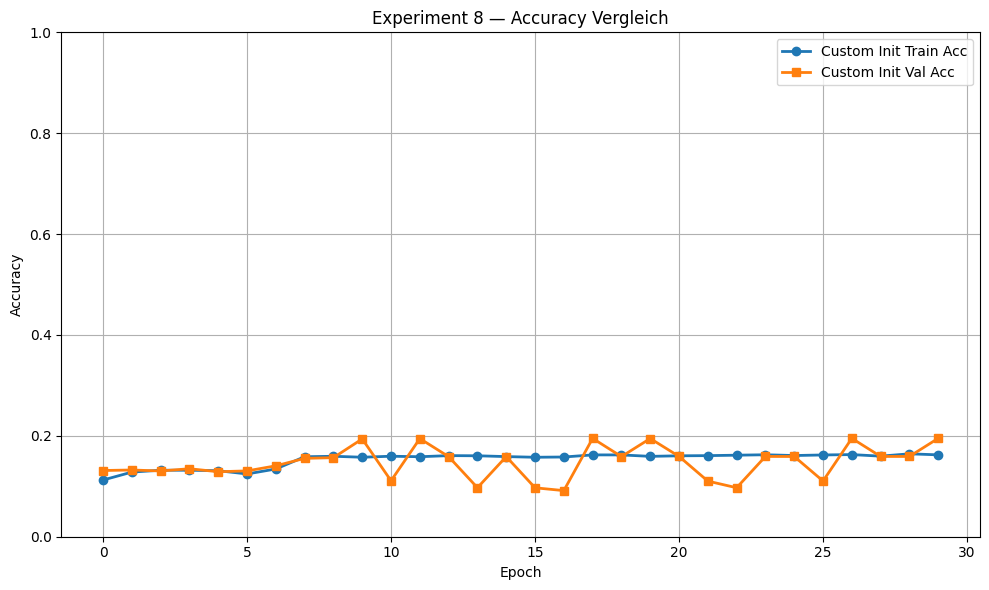

In [65]:
# Experiment 8: Gewichtisinitialisierung verändern
model_weight_init = CustomInitCNN().to(device)
loader_weight_init = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
optimizer_weight_init = optim.SGD(model_weight_init.parameters(), lr=0.01)
criterion_weight_init = nn.CrossEntropyLoss()
device_weight_init = device
writer_weight_init = SummaryWriter(log_dir="./runs/experiment8/weight_init_experiment8")

max_epochs = 30

history_init = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': []
}

for epoch in range(max_epochs):
    train_loss, train_acc = train_epoch(
        model_weight_init,
        loader_weight_init,
        optimizer_weight_init,
        criterion_weight_init,
        device_weight_init,
        writer=writer_weight_init,
        epoch=epoch,
        clip_grad=True
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model_weight_init,
        test_loader,
        criterion_weight_init,
        device_weight_init,
        writer=writer_weight_init,
        epoch=epoch
    )

    history_init['train_loss'].append(train_loss)
    history_init['train_acc'].append(train_acc)
    history_init['val_loss'].append(val_loss)
    history_init['val_acc'].append(val_acc)
    history_init['val_precision'].append(val_precision)
    history_init['val_recall'].append(val_recall)
    history_init['val_f1'].append(val_f1)

    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={val_acc:.4f}, Test Precision={val_precision:.4f}, Test Recall={val_recall:.4f}, Test F1={val_f1:.4f}")

writer_weight_init.close()

results_exp8 = {
    **history_init,
    'final_val_acc':   val_acc,
    'final_precision': val_precision,
    'final_recall':    val_recall,
    'final_f1':        val_f1
}

# Loss Kurven
plt.figure(figsize=(10, 6))
plt.plot(results_exp8['train_loss'], label='Custom Init Train Loss', linewidth=2)
plt.plot(results_exp8['val_loss'],   label='Custom Init Val Loss',   linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Experiment 8 — Loss Vergleich')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('exp8_loss_comparison.png', dpi=150)
plt.show()

# Accuracy Kurven
plt.figure(figsize=(10, 6))
plt.plot(results_exp8['train_acc'], label='Custom Init Train Acc', linewidth=2, marker='o')
plt.plot(results_exp8['val_acc'], label='Custom Init Val Acc', linewidth=2, marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Experiment 8 — Accuracy Vergleich')
plt.legend()
plt.grid()
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('exp8_accuracy_comparison.png', dpi=150)
plt.show()

In [66]:
# Tabelare Zusammenfassung
print("\n" + "=" * 50)
print("EXPERIMENT 8 ERGEBNISSE")
print("=" * 50)
print(f"{'Modell':<20} {'Final Val Acc':<20} {'Final Precision':<20} {'Final Recall':<20} {'Final F1-Score':<20}")
print("-" * 100)
print(f"{'Custom Init':<20} {results_exp8['final_val_acc']:<20.4f} {results_exp8['final_precision']:<20.4f} {results_exp8['final_recall']:<20.4f} {results_exp8['final_f1']:<20.4f}")


EXPERIMENT 8 ERGEBNISSE
Modell               Final Val Acc        Final Precision      Final Recall         Final F1-Score      
----------------------------------------------------------------------------------------------------
Custom Init          0.1951               0.1187               0.1951               0.0650              


### Auswertung Experiment 8:
Es ist zu sehen, dass die Performance des Modells mit der neuen Initialisierung deutlich schlechter ist als mit der Standard Initialisierung. Dies war zu erwarten, da die Bibliothek normalerweise eine optimiertere Initialisierung verwendet, welche dazu führt, dass das Modell schneller und besser konvergiert. Es ist trotzdem spannend zu sehen wie gross der Unterschied ist, da die Performance des Modells mit der zufälligen Initialisierung deutlich schlechter ist als mit der Standard Initialisierung.

## Experiment 9: Optimizer Adam
**Hypothese:**
Durch die Verwendung von einem anderen Optimizer wie Adam könnte die Performance des Modells verbessert werden, da Adam adaptiv die Lernrate anpasst und dadurch schneller konvergieren könnte.

In diesem Experiment soll überprüft werden, ob die Performance des Modells durch die Verwendung von einem Adam Optimizer verbessert werden kann. Im Baselinemodell wurde ein SGD Optimizer verwendet. Adam hat dabei den Vorteil, dass er adaptiv die Lernrate anpasst und dadurch schneller konvergieren könnte. Es soll überprüft werden, ob dies tatsächlich der Fall ist und ob die Performance des Modells durch die Verwendung von Adam verbessert werden kann.

Die Parameter des Adam Optimizers weichen dabei etwas von den Standardparametern ab. Es wird eine Lernrate von 0.001 verwendet, da Adam normalerweise mit einer kleineren Lernrate als SGD trainiert. Die restlichen Parameter wie Beta1, Beta2 und Epsilon werden mit den Standardwerten von Adam gelassen.

Dazu muss folgendes gemacht werden:
- Der optimizer muss zu Adam geändert werden, zudem muss die Lernrate auf 0.001 geändert werden.

Epoch 0: Train Acc=0.7711, Test Acc=0.8536, Test Precision=0.8560, Test Recall=0.8536, Test F1=0.8542
Epoch 2: Train Acc=0.9007, Test Acc=0.8743, Test Precision=0.8781, Test Recall=0.8743, Test F1=0.8750
Epoch 4: Train Acc=0.9235, Test Acc=0.8751, Test Precision=0.8776, Test Recall=0.8751, Test F1=0.8749
Epoch 6: Train Acc=0.9400, Test Acc=0.8841, Test Precision=0.8848, Test Recall=0.8841, Test F1=0.8836
Epoch 8: Train Acc=0.9528, Test Acc=0.8790, Test Precision=0.8808, Test Recall=0.8790, Test F1=0.8792
Epoch 10: Train Acc=0.9620, Test Acc=0.8789, Test Precision=0.8791, Test Recall=0.8789, Test F1=0.8785
Epoch 12: Train Acc=0.9684, Test Acc=0.8725, Test Precision=0.8749, Test Recall=0.8725, Test F1=0.8719
Epoch 14: Train Acc=0.9741, Test Acc=0.8675, Test Precision=0.8708, Test Recall=0.8675, Test F1=0.8683
Epoch 16: Train Acc=0.9777, Test Acc=0.8695, Test Precision=0.8721, Test Recall=0.8695, Test F1=0.8697
Epoch 18: Train Acc=0.9809, Test Acc=0.8684, Test Precision=0.8714, Test Recal

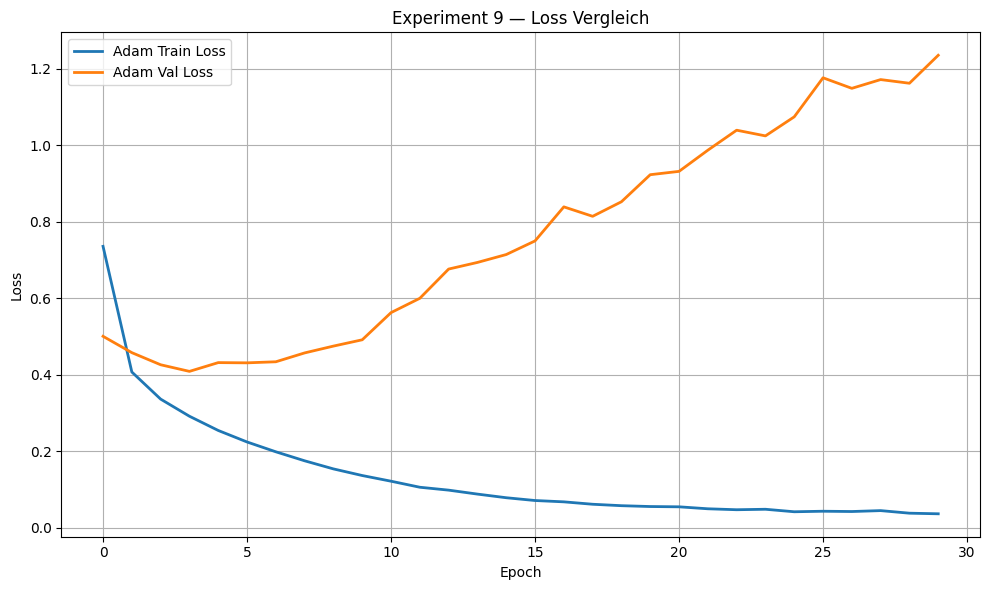

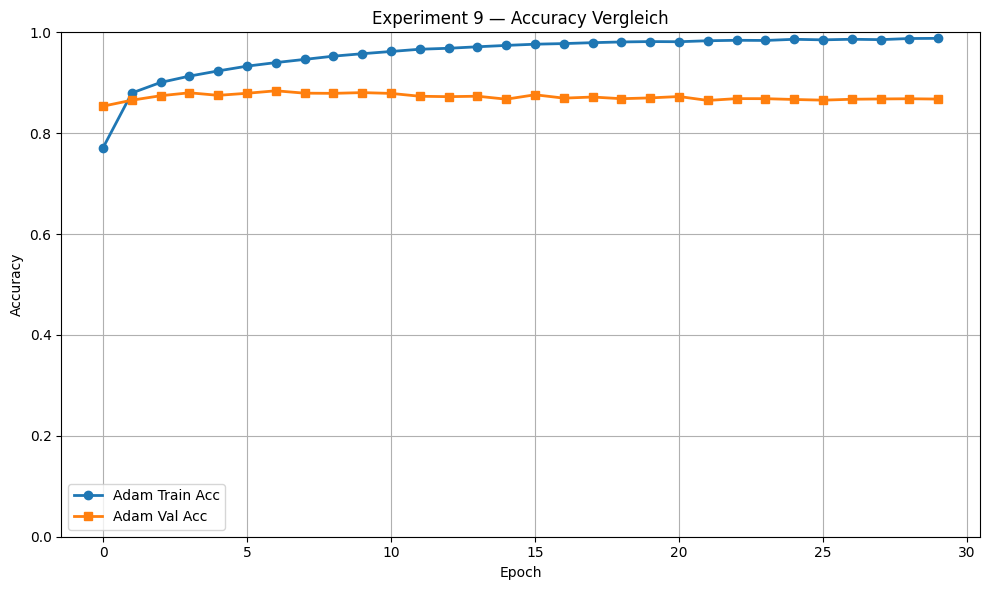

In [67]:
# Experiment 9: Optimizer Adam
model_adam = BaselineCNN().to(device)
loader_adam = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)
criterion_adam = nn.CrossEntropyLoss()
device_adam = device
writer_adam = SummaryWriter(log_dir="./runs/experiment9/adam_experiment9")

max_epochs = 30

history_adam = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': []
}

for epoch in range(max_epochs):
    train_loss, train_acc = train_epoch(
        model_adam,
        loader_adam,
        optimizer_adam,
        criterion_adam,
        device_adam,
        writer=writer_adam,
        epoch=epoch
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model_adam,
        test_loader,
        criterion_adam,
        device_adam,
        writer=writer_adam,
        epoch=epoch
    )

    history_adam['train_loss'].append(train_loss)
    history_adam['train_acc'].append(train_acc)
    history_adam['val_loss'].append(val_loss)
    history_adam['val_acc'].append(val_acc)
    history_adam['val_precision'].append(val_precision)
    history_adam['val_recall'].append(val_recall)
    history_adam['val_f1'].append(val_f1)

    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={val_acc:.4f}, Test Precision={val_precision:.4f}, Test Recall={val_recall:.4f}, Test F1={val_f1:.4f}")

writer_adam.close()

results_exp9 = {
    **history_adam,
    'final_train_loss': train_loss,
    'final_train_acc': train_acc,
    'final_val_loss': val_loss,
    'final_val_acc': val_acc,
    'final_val_precision': val_precision,
    'final_val_recall': val_recall,
    'final_val_f1': val_f1
}

# Loss Kurven
plt.figure(figsize=(10, 6))
plt.plot(results_exp9['train_loss'], label='Adam Train Loss', linewidth=2)
plt.plot(results_exp9['val_loss'],   label='Adam Val Loss',   linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Experiment 9 — Loss Vergleich')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('exp9_loss_comparison.png', dpi=150)
plt.show()

# Accuracy Kurven
plt.figure(figsize=(10, 6))
plt.plot(results_exp9['train_acc'], label='Adam Train Acc', linewidth=2, marker='o')
plt.plot(results_exp9['val_acc'], label='Adam Val Acc', linewidth=2, marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Experiment 9 — Accuracy Vergleich')
plt.legend()
plt.grid()
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('exp9_accuracy_comparison.png', dpi=150)
plt.show()

In [68]:
# Tabelare Zusammenfassung
print("\n" + "=" * 50)
print("EXPERIMENT 9 ERGEBNISSE")
print("=" * 50)
print(f"{'Modell':<20} {'Final Val Acc':<20} {'Final Precision':<20} {'Final Recall':<20} {'Final F1-Score':<20}")
print("-" * 100)
print(f"{'Adam Optimizer':<20} {results_exp9['final_val_acc']:<20.4f} {results_exp9['final_val_precision']:<20.4f} {results_exp9['final_val_recall']:<20.4f} {results_exp9['final_val_f1']:<20.4f}")


EXPERIMENT 9 ERGEBNISSE
Modell               Final Val Acc        Final Precision      Final Recall         Final F1-Score      
----------------------------------------------------------------------------------------------------
Adam Optimizer       0.8677               0.8688               0.8677               0.8679              


### Auswertung Experiment 9:
Durch die verwendung von Adam konnte die Performance nicht verbessert werden. Es ist sogar so, dass die Performance mit Adam deutlich schlechter ist als mit SGD. Dies könnte daran liegen, dass Adam normalerweise mit einer kleineren Lernrate trainiert wird als SGD, weshalb es durchaus sein könnte, dass die Lernrate von 0.001 zu hoch gewählt ist für Adam. Ich verwende deshalb weiterhin den SGD Optimizer für mein finales Modell, da dieser aktuell besser performt als Adam.

## Experiment 10: Focal Loss
**Hypothese:**
Durch die Verwendung von einem anderen Loss wie Focal Loss könnte die Performance des Modells verbessert werden. Da in den Daten eine Klassenimbalance besteht, könnte Focal Loss besser performen, da es die schwer zu klassifizierenden Beispiele stärker gewichtet und dadurch das Modell besser lernt, diese Beispiele korrekt zu klassifizieren.

Die Daten weisen eine klare Klassenimbalance auf, da die Klasse 1 am häufigsten vorkommt und danach absteigend die anderen Klassen. In solchen Fällen könnte die Verwendung von Focal Loss anstelle von Cross Entropy Loss die Performance des Modells verbessern, da Focal Loss die schwer zu klassifizierenden Beispiele stärker gewichtet und dadurch das Modell besser lernt, diese Beispiele korrekt zu klassifizieren.

Um dies umzusetzen kann das Baseline Modell verwendet werden, wobei lediglich die Loss Funktion von Cross Entropy Loss zu Focal Loss geändert wird. Die restliche Architektur sowie die Hyperparameter des Modells sollen gleich bleiben wie im Baseline Modell.

Es gibt beim Focal Loss zwei wichtige Hyperparameter, welche die Performance des Modells beeinflussen können. Zum einen gibt es den Alpha Hyperparameter, welcher die Gewichtung der verschiedenen Klassen steuert. Gamma ist der andere Hyperparameter, welcher die Gewichtung der schwer zu klassifizierenden Beispiele steuert.

Dazu muss folgendes gemacht werden:
- Focal Loss implementieren
- Loss Funktion im Training und in der Evaluation von Cross Entropy Loss zu Focal Loss ändern

In [69]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        """
        Focal Loss für Klassifikationsprobleme

        Args:
            alpha (float): Skalierungsfaktor (Standard: 1.0)
            gamma (float): Fokusparameter (Standard: 2.0)
            reduction (str): 'mean' oder 'sum' (Standard: 'mean')
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, outputs, label):
        ce_loss = self.ce_loss(outputs, label)  # Cross-Entropy Loss pro Sample
        
        # Wahrscheinlichkeit der korrekten Klasse
        p_t = torch.exp(-ce_loss)

        # Focal Loss Formel: - alpha * (1 - p_t)^gamma * log(p_t)
        focal_loss = self.alpha * (1 - p_t) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            raise ValueError("Invalid reduction mode. Choose 'mean' or 'sum'.")

In [70]:
# Experiment 10: Focal Loss
# Hyperparameter
alphas_exp10 = [0.5, 1.0, 2.0]
gammas_exp10 = [0.0, 1.0, 2.0, 5.0]
results_exp10 = {}

max_epochs = 30

for alpha in alphas_exp10:
    for gamma in gammas_exp10:
        torch.manual_seed(42)
        
        model_focal = BaselineCNN().to(device)
        loader_focal = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
        optimizer_focal = optim.SGD(model_focal.parameters(), lr=0.01)
        criterion_focal = FocalLoss(alpha=alpha, gamma=gamma, reduction='mean')
        device_focal = device
        writer_focal = SummaryWriter(log_dir=f"./runs/experiment10/focal_experiment10_a{alpha}_g{gamma}")
        
        print(f"\nTraining mit alpha={alpha}, gamma={gamma}")
        if gamma == 0:
            print("(gamma=0 entspricht gewichtetem Cross-Entropy — Kontrollwert)")
        print("-" * 50)

        history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'val_precision': [],
            'val_recall': [],
            'val_f1': []
        }

        for epoch in range(max_epochs):
            train_loss, train_acc = train_epoch(
                model_focal,
                loader_focal,
                optimizer_focal,
                criterion_focal,
                device_focal,
                writer=writer_focal,
                epoch=epoch
            )

            val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
                model_focal,
                test_loader,
                criterion_focal,
                device_focal,
                writer=writer_focal,
                epoch=epoch
            )

            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['val_precision'].append(val_precision)
            history['val_recall'].append(val_recall)
            history['val_f1'].append(val_f1)

            if epoch % 2 == 0:
                print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, "
                      f"Precision={val_precision:.4f}, Recall={val_recall:.4f}, F1={val_f1:.4f}")

        results_exp10[(alpha, gamma)] = {
            **history,
            'final_val_acc': val_acc,
            'final_precision': val_precision,
            'final_recall': val_recall,
            'final_f1': val_f1
        }

        writer_focal.close()


Training mit alpha=0.5, gamma=0.0
(gamma=0 entspricht gewichtetem Cross-Entropy — Kontrollwert)
--------------------------------------------------
Epoch 0: Train Acc=0.1891, Val Acc=0.1959, Precision=0.0703, Recall=0.1959, F1=0.0643
Epoch 2: Train Acc=0.5845, Val Acc=0.7122, Precision=0.7373, Recall=0.7122, F1=0.7118
Epoch 4: Train Acc=0.8247, Val Acc=0.8177, Precision=0.8314, Recall=0.8177, F1=0.8205
Epoch 6: Train Acc=0.8619, Val Acc=0.7280, Precision=0.8033, Recall=0.7280, F1=0.7398
Epoch 8: Train Acc=0.8813, Val Acc=0.8258, Precision=0.8433, Recall=0.8258, F1=0.8272
Epoch 10: Train Acc=0.8924, Val Acc=0.8527, Precision=0.8563, Recall=0.8527, F1=0.8519
Epoch 12: Train Acc=0.9028, Val Acc=0.8652, Precision=0.8685, Recall=0.8652, F1=0.8656
Epoch 14: Train Acc=0.9105, Val Acc=0.8663, Precision=0.8707, Recall=0.8663, F1=0.8672
Epoch 16: Train Acc=0.9189, Val Acc=0.8445, Precision=0.8662, Recall=0.8445, F1=0.8487
Epoch 18: Train Acc=0.9258, Val Acc=0.8723, Precision=0.8754, Recall=0.872

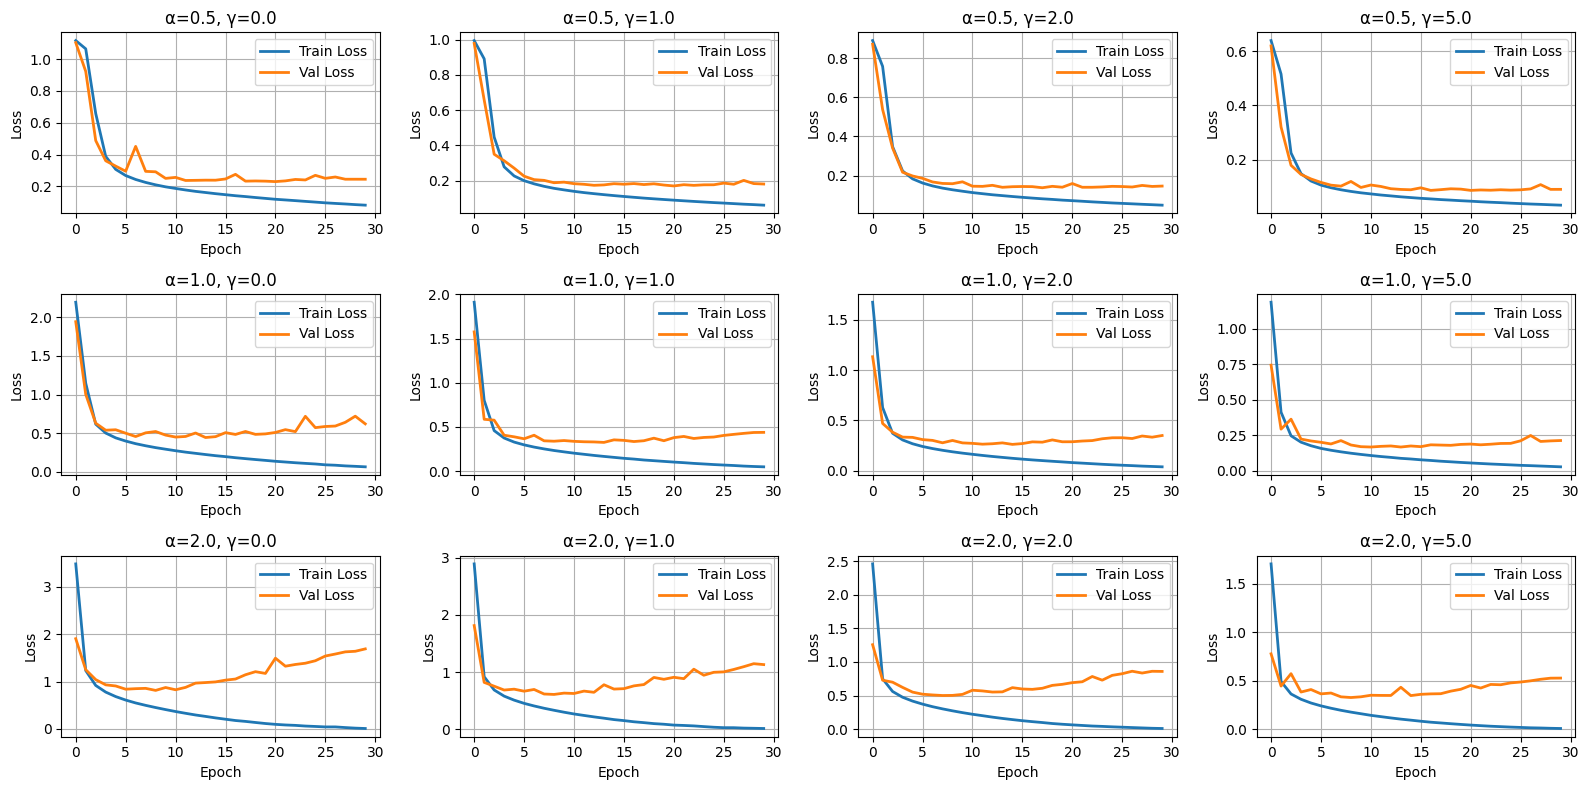

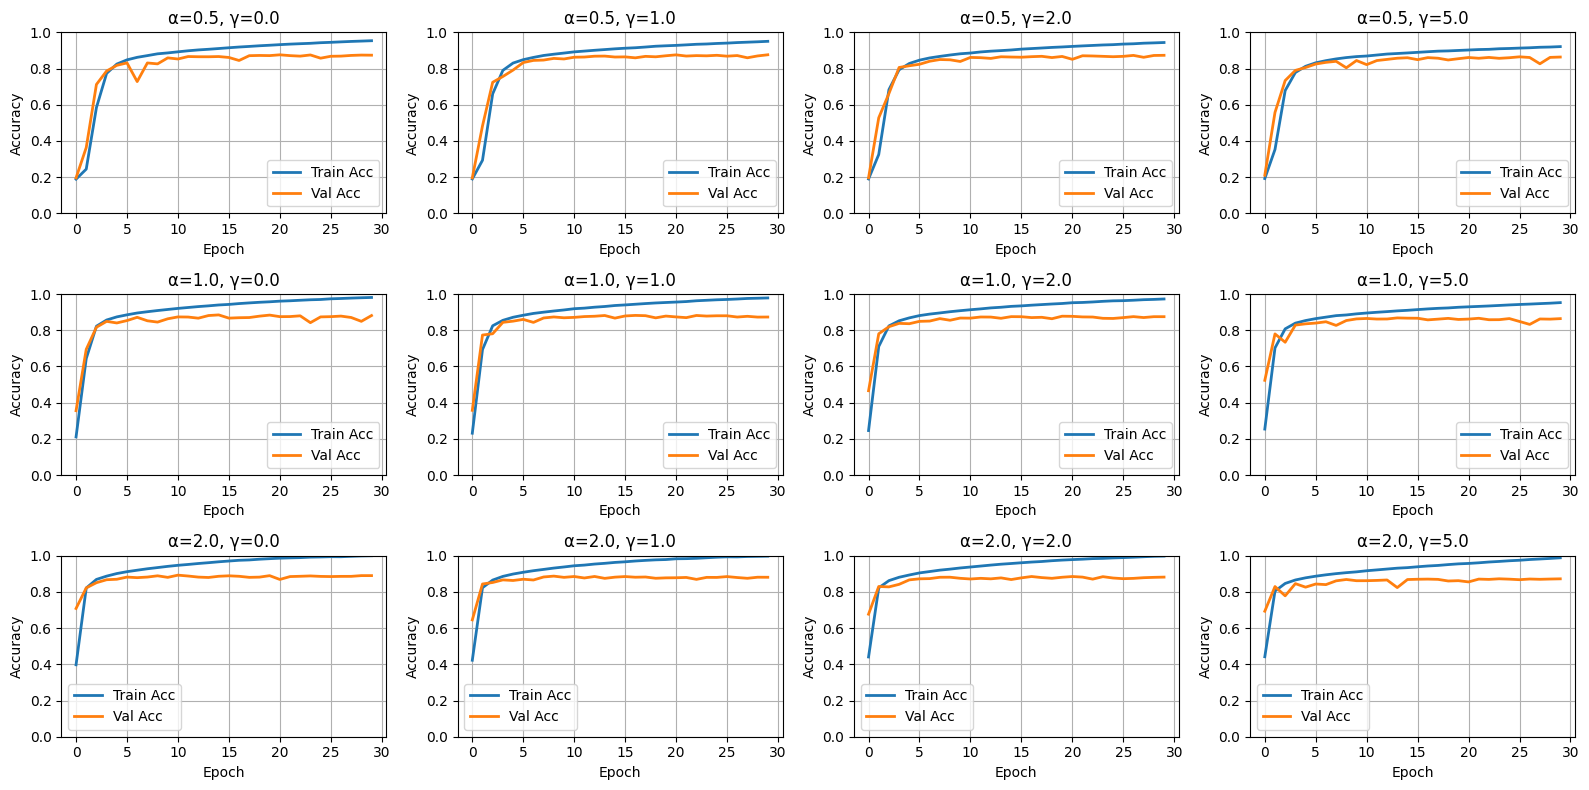

In [71]:
# Loss Kurven
fig, axes = plt.subplots(len(alphas_exp10), len(gammas_exp10), figsize=(16, 8))

for i, alpha in enumerate(alphas_exp10):
    for j, gamma in enumerate(gammas_exp10):
        res = results_exp10[(alpha, gamma)]
        ax = axes[i, j]
        epochs_range = range(len(res['train_loss']))
        
        ax.plot(epochs_range, res['train_loss'], label='Train Loss', linewidth=2)
        ax.plot(epochs_range, res['val_loss'],   label='Val Loss',   linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(f'α={alpha}, γ={gamma}')
        ax.legend()
        ax.grid()

plt.tight_layout()
plt.savefig('exp10_loss_curves.png', dpi=150)
plt.show()

# Accuracy Kurven
fig, axes = plt.subplots(len(alphas_exp10), len(gammas_exp10), figsize=(16, 8))

for i, alpha in enumerate(alphas_exp10):
    for j, gamma in enumerate(gammas_exp10):
        res = results_exp10[(alpha, gamma)]
        ax = axes[i, j]
        epochs_range = range(len(res['train_acc']))
        
        ax.plot(epochs_range, res['train_acc'], label='Train Acc', linewidth=2)
        ax.plot(epochs_range, res['val_acc'],   label='Val Acc',   linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'α={alpha}, γ={gamma}')
        ax.set_ylim([0, 1])
        ax.legend()
        ax.grid()

plt.tight_layout()
plt.savefig('exp10_accuracy_curves.png', dpi=150)
plt.show()

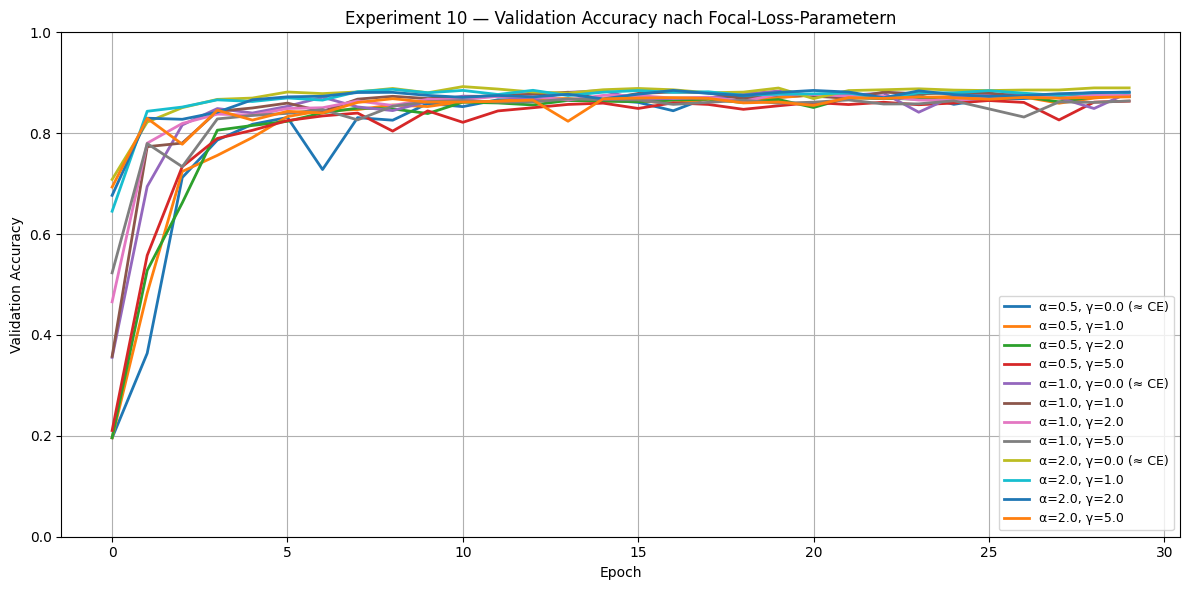

In [72]:
plt.figure(figsize=(12, 6))

for (alpha, gamma), res in results_exp10.items():
    label = f'α={alpha}, γ={gamma}'
    if gamma == 0:
        label += ' (≈ CE)'
    plt.plot(res['val_acc'], label=label, linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Experiment 10 — Validation Accuracy nach Focal-Loss-Parametern')
plt.legend(loc='lower right', fontsize=9)
plt.grid()
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('exp10_val_acc_comparison.png', dpi=150)
plt.show()

In [73]:
# Tabelare Zusammenfassung
print("\n" + "=" * 50)
print("EXPERIMENT 10 ERGEBNISSE")
print("=" * 50)
print(f"{'Alpha':<10} {'Gamma':<10} {'Final Val Acc':<20} {'Final Precision':<20} {'Final Recall':<20} {'Final F1-Score':<20}")
print("-" * 110)
for (alpha, gamma), res in results_exp10.items():
    print(f"{alpha:<10} {gamma:<10} {res['final_val_acc']:<20.4f} {res['final_precision']:<20.4f} "
          f"{res['final_recall']:<20.4f} {res['final_f1']:<20.4f}")



EXPERIMENT 10 ERGEBNISSE
Alpha      Gamma      Final Val Acc        Final Precision      Final Recall         Final F1-Score      
--------------------------------------------------------------------------------------------------------------
0.5        0.0        0.8738               0.8754               0.8738               0.8741              
0.5        1.0        0.8760               0.8772               0.8760               0.8760              
0.5        2.0        0.8731               0.8739               0.8731               0.8726              
0.5        5.0        0.8636               0.8651               0.8636               0.8633              
1.0        0.0        0.8810               0.8815               0.8810               0.8810              
1.0        1.0        0.8728               0.8743               0.8728               0.8727              
1.0        2.0        0.8747               0.8763               0.8747               0.8748              
1.0        5.0 

### Auswertung Experiment 10:
Es ist zu sehen, dass die Performance des Modells mit Focal Loss nicht wirklich besser ist als mit Cross Entropy Loss. Die beste Performance wird mit einem Alpha von 2 und einem Gamma von 0 erzielt. Dies entspricht ungefähr einer normalen Cross Entropy Loss, da der Alpha Hyperparameter die Gewichtung der verschiedenen Klassen steuert und der Gamma Hyperparameter die Gewichtung der schwer zu klassifizierenden Beispiele steuert. Es könnte sein, dass die Klassenimbalance in den Daten nicht stark genug ist, um einen Unterschied zwischen Focal Loss und Cross Entropy Loss zu machen. Ich werde deshalb weiterhin Cross Entropy Loss für mein finales Modell verwenden, da dieser aktuell besser performt als Focal Loss.

# Finales Modell

Hier kommt nun das finale Modell, welches auf den Erkenntnissen der vorherigen Experimente basiert. Es ist zu beachten, dass die Erkenntnisse jeweils unabhängig voneinander durchgeführt wurden, weshalb es durchaus sein könnte, dass es noch bessere Kombinationen der Hyperparameter geben könnte.

Das finale Modell besteht aus:
- Einer Lernrate von 0.01 und einem Early Stopping mit einer Patience von 10 Epochen
- 3 Convolutional Layern mit 32, 64 und 128 Filtern
- 3 Fully Connected Layern mit 128 und 64 Neuronen
- Filterkernels von 5x5
- Dropout mit einer Dropoutrate von 0.5 im Fully Connected Layer und einer Dropoutrate von 0.25 in den Convolutional Layern
- Batch Normalization in den Convolutional Layern
- Standard Initialisierung der Gewichte von der Bibliothek
- SGD Optimizer
- Cross Entropy Loss


In [74]:
class FinalModelCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,5,padding=2),        # 3 Input-Kanäle (RGB), 32 Filter mit 5x5, Padding 2
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),                   # Dropout mit 25% Wahrscheinlichkeit

            nn.Conv2d(32,64,5,padding=2),       # 32 Input-Kanäle (von vorheriger Schicht), 64 Filter mit 5x5, Padding 2
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),                   # Dropout mit 25% Wahrscheinlichkeit

            nn.Conv2d(64,128,5,padding=2),      # 64 Input-Kanäle, 128 Filter mit 5x5, Padding 2
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)                   # Dropout mit 25% Wahrscheinlichkeit
        )

        self.fc = nn.Sequential(
            nn.Flatten(),                       # Flacht 3D-Tensor ab
            nn.Linear(128*4*4,128),              # 128*4*4 Eingabekanäle, 128 Ausgabekanäle   
            nn.ReLU(),
            nn.Dropout(0.5),                    # Dropout mit 50% Wahrscheinlichkeit
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.5),                    # Dropout mit 50% Wahrscheinlichkeit
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Dropout(0.5),                    # Dropout mit 50% Wahrscheinlichkeit
            nn.Linear(64,10)
        )

    def forward(self,x):

        x = self.conv(x)                        # Durchlaufen der Convolutional Layers
        x = self.fc(x)                          # Durchlaufen der Fully Connected Layers

        return x

Epoch 0: Train Acc=0.2203, Val Acc=0.3384, Val Loss=1.8853, F1=0.2069 (best epoch=0, no_improve=0)
Epoch 5: Train Acc=0.7184, Val Acc=0.8410, Val Loss=0.5817, F1=0.8419 (best epoch=5, no_improve=0)
Epoch 10: Train Acc=0.8329, Val Acc=0.8933, Val Loss=0.3933, F1=0.8932 (best epoch=9, no_improve=1)
Epoch 15: Train Acc=0.8675, Val Acc=0.9136, Val Loss=0.3297, F1=0.9136 (best epoch=14, no_improve=1)
Epoch 20: Train Acc=0.8858, Val Acc=0.9177, Val Loss=0.3026, F1=0.9174 (best epoch=19, no_improve=1)
Epoch 25: Train Acc=0.8967, Val Acc=0.9258, Val Loss=0.2871, F1=0.9256 (best epoch=25, no_improve=0)
Epoch 30: Train Acc=0.9063, Val Acc=0.9341, Val Loss=0.2648, F1=0.9341 (best epoch=30, no_improve=0)
Epoch 35: Train Acc=0.9122, Val Acc=0.9382, Val Loss=0.2517, F1=0.9382 (best epoch=35, no_improve=0)
Epoch 40: Train Acc=0.9176, Val Acc=0.9367, Val Loss=0.2587, F1=0.9367 (best epoch=35, no_improve=5)
Epoch 45: Train Acc=0.9227, Val Acc=0.9364, Val Loss=0.2550, F1=0.9364 (best epoch=41, no_improv

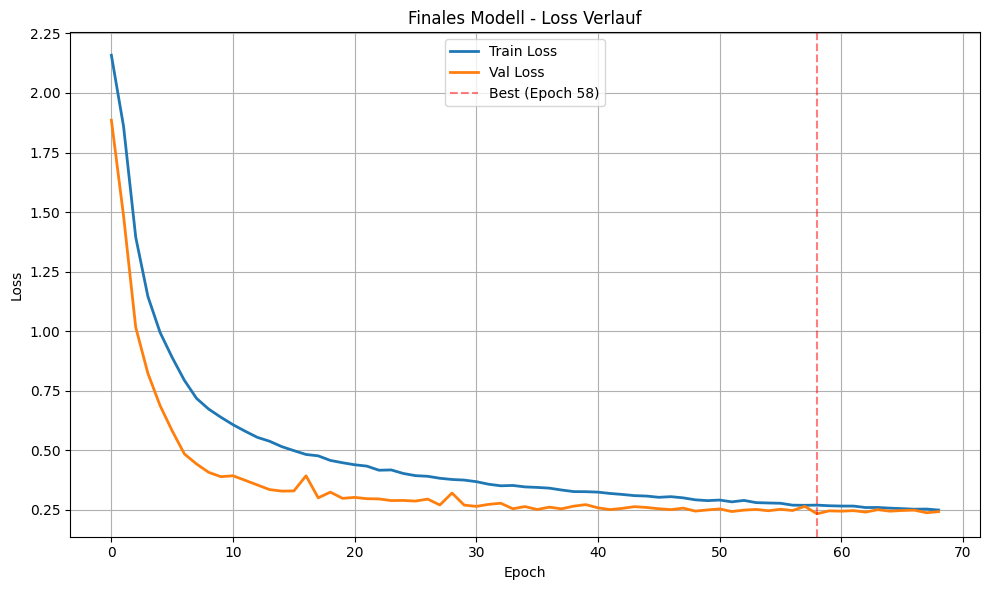

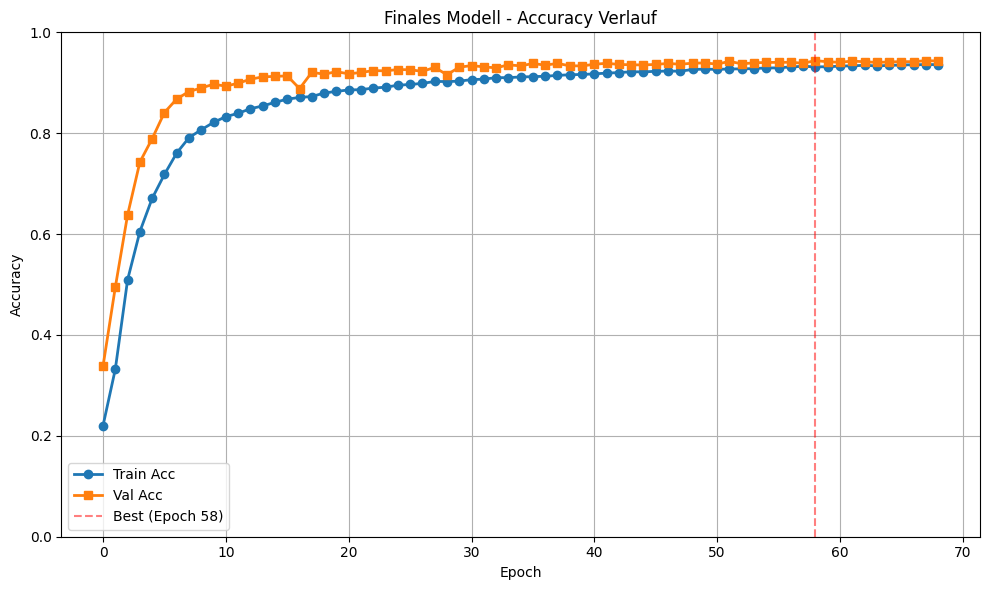

In [75]:
# Trainieren des finalen Modells
model_final = FinalModelCNN().to(device)
loader_final = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)

optimizer_final = optim.SGD(model_final.parameters(), lr=0.01)
criterion_final = nn.CrossEntropyLoss()
writer_final = SummaryWriter(log_dir="./runs/final_model/final_experiment")

max_epochs = 500
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None
best_epoch = -1

history_final = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': []
}

for epoch in range(max_epochs):
    train_loss, train_acc = train_epoch(
        model_final,
        loader_final,
        optimizer_final,
        criterion_final,
        device,
        writer=writer_final,
        epoch=epoch
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model_final,
        test_loader,
        criterion_final,
        device,
        writer=writer_final,
        epoch=epoch
    )

    history_final['train_loss'].append(train_loss)
    history_final['train_acc'].append(train_acc)
    history_final['val_loss'].append(val_loss)
    history_final['val_acc'].append(val_acc)
    history_final['val_precision'].append(val_precision)
    history_final['val_recall'].append(val_recall)
    history_final['val_f1'].append(val_f1)

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model_final.state_dict().items()}
        epochs_no_improve = 0

    else:
        epochs_no_improve += 1

    if epoch % 5 == 0 or epochs_no_improve >= patience:
        print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, F1={val_f1:.4f} "
              f"(best epoch={best_epoch}, no_improve={epochs_no_improve})")

    if epochs_no_improve >= patience:
        print(f"Early Stopping nach Epoche {epoch} (bestes Modell aus Epoche {best_epoch}).")
        break

if best_state is not None:
    model_final.load_state_dict(best_state)
    torch.save(best_state, 'final_model.pt')
writer_final.close()

# Loss Kurven (ohne UTF-8-Artefakte im Titel)
plt.figure(figsize=(10, 6))
plt.plot(history_final['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history_final['val_loss'],   label='Val Loss',   linewidth=2)
plt.axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (Epoch {best_epoch})')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Finales Modell - Loss Verlauf')
plt.legend(); plt.grid(); plt.tight_layout()
plt.savefig('final_model_loss_curve.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_final['train_acc'], label='Train Acc', linewidth=2, marker='o')
plt.plot(history_final['val_acc'],   label='Val Acc',   linewidth=2, marker='s')
plt.axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (Epoch {best_epoch})')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Finales Modell - Accuracy Verlauf')
plt.legend(); plt.grid(); plt.ylim([0, 1]); plt.tight_layout()
plt.savefig('final_model_accuracy_curve.png', dpi=150)
plt.show()

In [76]:
# Tabelare Zusammenfassung
print("\n" + "=" * 60)
print("FINALES MODELL - ERGEBNISSE")
print("=" * 60)
print(f"{'Metrik':<25} {'Wert':<15}")
print("-" * 40)
print(f"{'Best Epoch':<25} {best_epoch:<15}")
print(f"{'Trainierte Epochen':<25} {len(history_final['val_acc']):<15}")
print(f"{'Best Val Loss':<25} {history_final['val_loss'][best_epoch]:<15.4f}")
print(f"{'Best Val Accuracy':<25} {history_final['val_acc'][best_epoch]:<15.4f}")
print(f"{'Best Val Precision':<25} {history_final['val_precision'][best_epoch]:<15.4f}")
print(f"{'Best Val Recall':<25} {history_final['val_recall'][best_epoch]:<15.4f}")
print(f"{'Best Val F1':<25} {history_final['val_f1'][best_epoch]:<15.4f}")
print(f"{'# Parameter':<25} {sum(p.numel() for p in model_final.parameters()):<15,}")


FINALES MODELL - ERGEBNISSE
Metrik                    Wert           
----------------------------------------
Best Epoch                58             
Trainierte Epochen        69             
Best Val Loss             0.2337         
Best Val Accuracy         0.9440         
Best Val Precision        0.9442         
Best Val Recall           0.9440         
Best Val F1               0.9439         
# Parameter               534,410        



Anzahl falsch klassifizierter Bilder: 1459


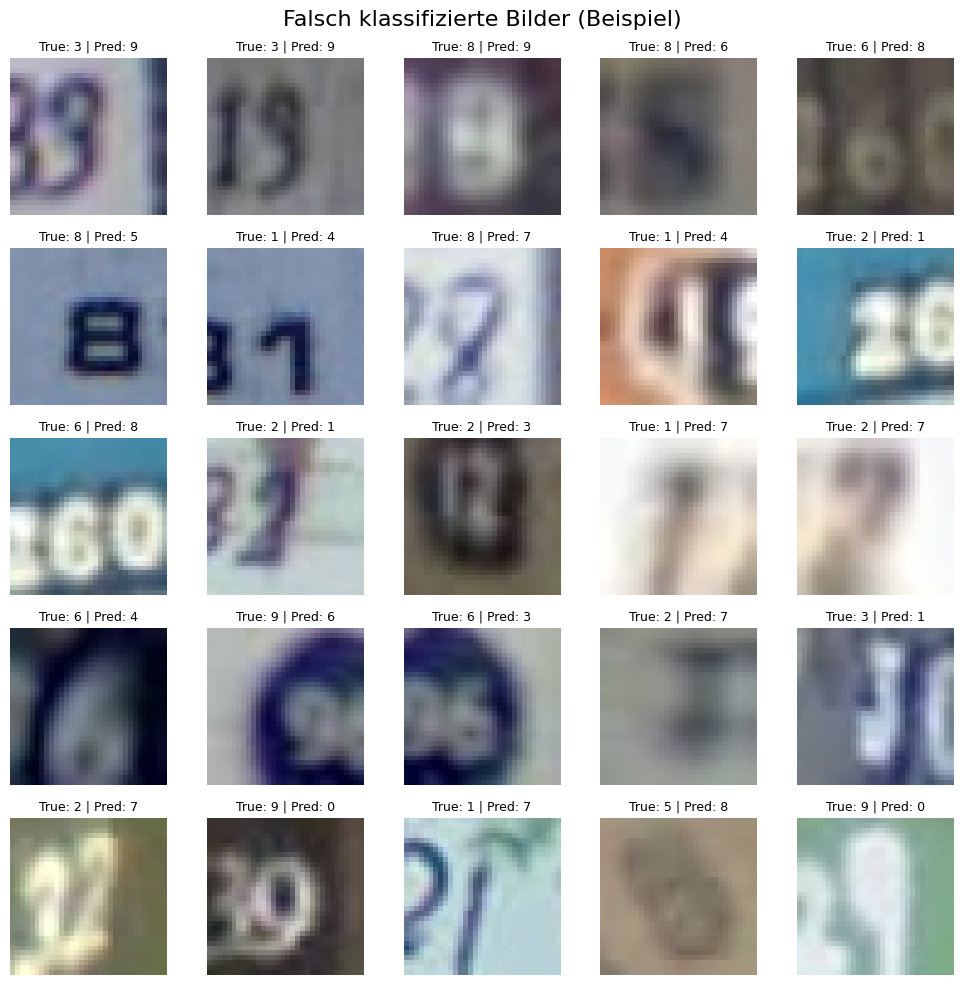

In [77]:
# Ausgabe der falsch klassifizierten Bilder
model_final.eval()
misclassified_images = []
misclassified_labels = []
misclassified_preds = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_final(images)
        _, predicted = torch.max(outputs, 1)
        misclassified_mask = (predicted != labels)
        misclassified_images.append(images[misclassified_mask].cpu())
        misclassified_labels.append(labels[misclassified_mask].cpu())
        misclassified_preds.append(predicted[misclassified_mask].cpu())
misclassified_images = torch.cat(misclassified_images)
misclassified_labels = torch.cat(misclassified_labels)
misclassified_preds  = torch.cat(misclassified_preds)
print(f"\nAnzahl falsch klassifizierter Bilder: {len(misclassified_images)}")

# Visualisierung der falsch klassifizierten Bilder
num_to_show = min(25, len(misclassified_images))
plt.figure(figsize=(10, 10))
for i in range(num_to_show):
    plt.subplot(5, 5, i + 1)
    img = misclassified_images[i].permute(1, 2, 0) * 0.5 + 0.5
    plt.imshow(img)
    plt.title(f"True: {misclassified_labels[i].item()} | Pred: {misclassified_preds[i].item()}",
              fontsize=9)
    plt.axis('off')
plt.suptitle('Falsch klassifizierte Bilder (Beispiel)', fontsize=16)
plt.tight_layout()
plt.show()


### Performance des finalen Modells:
Es ist zu sehen, dass die Performance des finalen Modells deutlich besser ist als die des Baseline Modells. Die Accuracy auf den Testdaten liegt bei etwas über 94%, was eine deutliche Verbesserung gegenüber dem Baseline Modell ist, welches eine Accuracy von etwas über 90% erreicht hat. Erstaunlich ist, dass der Loss und die Accuracy in der Validierung jeweils etwas besser ist als auf den Trainingsdaten. In meinen Augen zeigt das auf, dass die Regularisierungstechniken wie Dropout und Batch Normalization gut funktionieren, da das Modell dadurch weniger overfittet.

Auf den Beispielausgeben der Falsch klassifizierten Bilder ist zu sehen, dass die meisten Bilder, welche falsch klassifiziert wurden, tatsächlich schwer zu klassifizieren sind, da sie teilweise sehr unscharf sind oder die Bilder mehrere Zahlen beinhalten.

Abschliessend ist zu sagen, dass durch die angewendeten experimente die Performance des Modells deutlich verbessert werden konnte. Es ist jedoch durchaus möglich, dass es noch weitere Möglichkeiten gibt, die Performance des Modells zu verbessern, oder die einzelnen Hyperparameter in kombination zu optimieren, um eine noch bessere Performance zu erzielen.

### Zusatz: Versuch mit 5 Convolutional Layern
In den Experimenten hat sich gezeigt, dass die Modelle mit 4 und 5 Convolutional Layern zwar etwas besser performen als die Modelle mit weniger Convolutional Layern, aber gleichzeitig deutlich mehr Parameter haben und auch deutlich länger brauchen um zu trainieren. Ich will nun versuchen, ob mein finales Modell aber mit 5 Convolutional Layern eine bessere Performance erzielt als mit 3 Convolutional Layern. Dazu nehme ich das selbe Modell und die Selben Parameter wie oben und erhöhe lediglich die Anzahl der Convolutional Layer von 3 auf 5 und entferne das letzte Maxpooling Layer, damit die räumlichen Dimensionen der Bilder nicht zu klein werden.

In [78]:
class DeeperFinalModelCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,5,padding=2),        # 3 Input-Kanäle (RGB), 32 Filter mit 5x5, Padding 2
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),                   # Dropout mit 25% Wahrscheinlichkeit

            nn.Conv2d(32,64,5,padding=2),       # 32 Input-Kanäle (von vorheriger Schicht), 64 Filter mit 5x5, Padding 2
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),                   # Dropout mit 25% Wahrscheinlichkeit

            nn.Conv2d(64,128,5,padding=2),      # 64 Input-Kanäle, 128 Filter mit 5x5, Padding 2
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),                   # Dropout mit 25% Wahrscheinlichkeit

            nn.Conv2d(128,256,5,padding=2),     # 128 Input-Kanäle, 256 Filter mit 3x3, Padding 2
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),                   # Dropout mit 25% Wahrscheinlichkeit

            nn.Conv2d(256,512,5,padding=2),     # 256 Input-Kanäle, 512 Filter mit 3x3, Padding 2
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Dropout(0.25),                   # Dropout mit 25% Wahrscheinlichkeit
        )

        self.fc = nn.Sequential(
            nn.Flatten(),                       # Flacht 3D-Tensor ab
            nn.Linear(512*2*2,128),              # 512*2*2 Eingabekanäle, 128 Ausgabekanäle   
            nn.ReLU(),
            nn.Dropout(0.5),                    # Dropout mit 50% Wahrscheinlichkeit
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.5),                    # Dropout mit 50% Wahrscheinlichkeit
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Dropout(0.5),                    # Dropout mit 50% Wahrscheinlichkeit
            nn.Linear(64,10)
        )

    def forward(self,x):

        x = self.conv(x)                        # Durchlaufen der Convolutional Layers
        x = self.fc(x)                          # Durchlaufen der Fully Connected Layers

        return x

Epoch 0: Train Acc=0.2252, Val Acc=0.3266, Val Loss=1.9457, F1=0.2186 (best epoch=0, no_improve=0)
Epoch 5: Train Acc=0.6775, Val Acc=0.7523, Val Loss=0.7591, F1=0.7385 (best epoch=5, no_improve=0)
Epoch 10: Train Acc=0.8555, Val Acc=0.9192, Val Loss=0.3207, F1=0.9191 (best epoch=10, no_improve=0)
Epoch 15: Train Acc=0.8905, Val Acc=0.9245, Val Loss=0.2960, F1=0.9247 (best epoch=15, no_improve=0)
Epoch 20: Train Acc=0.9075, Val Acc=0.9256, Val Loss=0.2966, F1=0.9254 (best epoch=17, no_improve=3)
Epoch 25: Train Acc=0.9175, Val Acc=0.9395, Val Loss=0.2526, F1=0.9394 (best epoch=25, no_improve=0)
Epoch 30: Train Acc=0.9250, Val Acc=0.9444, Val Loss=0.2404, F1=0.9444 (best epoch=30, no_improve=0)
Epoch 35: Train Acc=0.9329, Val Acc=0.9452, Val Loss=0.2414, F1=0.9452 (best epoch=30, no_improve=5)
Epoch 40: Train Acc=0.9369, Val Acc=0.9443, Val Loss=0.2403, F1=0.9443 (best epoch=38, no_improve=2)
Epoch 45: Train Acc=0.9409, Val Acc=0.9430, Val Loss=0.2539, F1=0.9430 (best epoch=38, no_impro

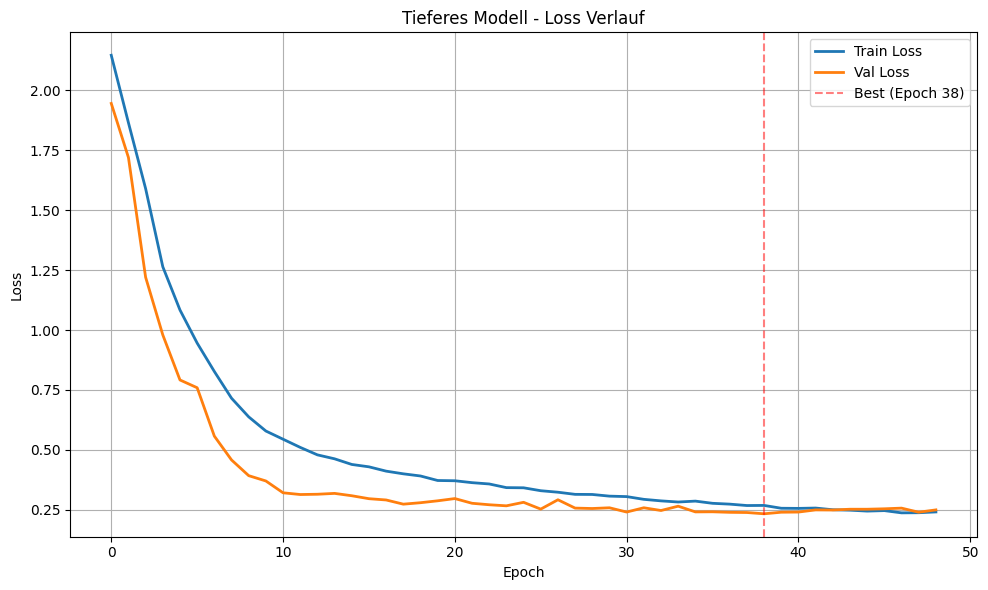

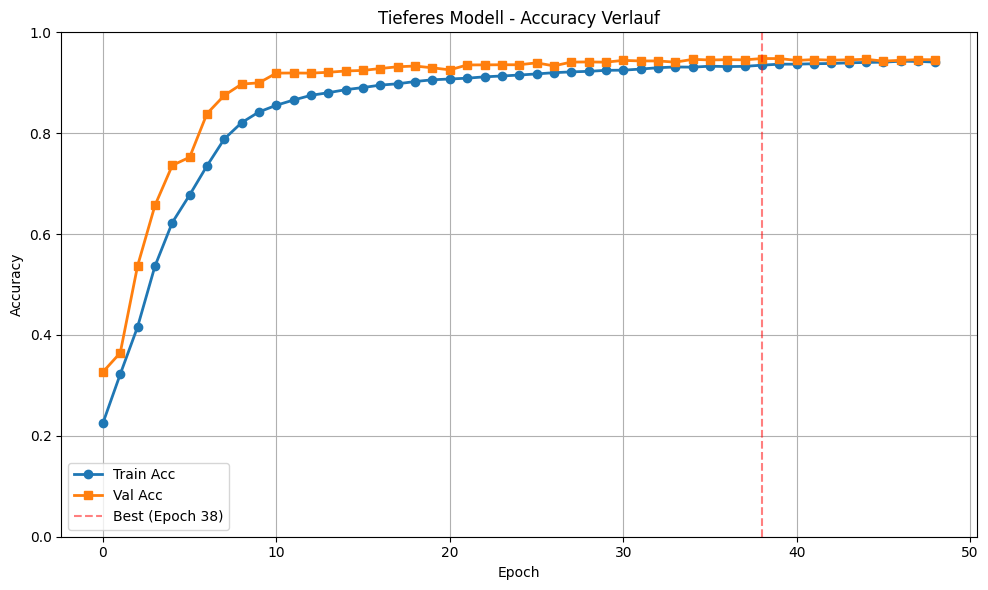

In [79]:
# Trainieren des finalen Modells
model_deepfinal = DeeperFinalModelCNN().to(device)
loader_deepfinal = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)

optimizer_deepfinal = optim.SGD(model_deepfinal.parameters(), lr=0.01)
criterion_deepfinal = nn.CrossEntropyLoss()
writer_deepfinal = SummaryWriter(log_dir="./runs/deeper_final_model/deeper_final_experiment")

max_epochs = 500
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None
best_epoch = -1

history_deepfinal = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': []
}

for epoch in range(max_epochs):
    train_loss, train_acc = train_epoch(
        model_deepfinal,
        loader_deepfinal,
        optimizer_deepfinal,
        criterion_deepfinal,
        device,
        writer=writer_deepfinal,
        epoch=epoch
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model_deepfinal,
        test_loader,
        criterion_deepfinal,
        device,
        writer=writer_deepfinal,
        epoch=epoch
    )

    history_deepfinal['train_loss'].append(train_loss)
    history_deepfinal['train_acc'].append(train_acc)
    history_deepfinal['val_loss'].append(val_loss)
    history_deepfinal['val_acc'].append(val_acc)
    history_deepfinal['val_precision'].append(val_precision)
    history_deepfinal['val_recall'].append(val_recall)
    history_deepfinal['val_f1'].append(val_f1)

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model_deepfinal.state_dict().items()}
        epochs_no_improve = 0

    else:
        epochs_no_improve += 1

    if epoch % 5 == 0 or epochs_no_improve >= patience:
        print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, F1={val_f1:.4f} "
              f"(best epoch={best_epoch}, no_improve={epochs_no_improve})")

    if epochs_no_improve >= patience:
        print(f"Early Stopping nach Epoche {epoch} (bestes Modell aus Epoche {best_epoch}).")
        break

if best_state is not None:
    model_deepfinal.load_state_dict(best_state)
    torch.save(best_state, 'deepfinal_model.pt')
writer_deepfinal.close()

# Loss Kurven (ohne UTF-8-Artefakte im Titel)
plt.figure(figsize=(10, 6))
plt.plot(history_deepfinal['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history_deepfinal['val_loss'],   label='Val Loss',   linewidth=2)
plt.axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (Epoch {best_epoch})')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Tieferes Modell - Loss Verlauf')
plt.legend(); plt.grid(); plt.tight_layout()
plt.savefig('deepfinal_model_loss_curve.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_deepfinal['train_acc'], label='Train Acc', linewidth=2, marker='o')
plt.plot(history_deepfinal['val_acc'],   label='Val Acc',   linewidth=2, marker='s')
plt.axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (Epoch {best_epoch})')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Tieferes Modell - Accuracy Verlauf')
plt.legend(); plt.grid(); plt.ylim([0, 1]); plt.tight_layout()
plt.savefig('deepfinal_model_accuracy_curve.png', dpi=150)
plt.show()

In [80]:
# Tabelare Zusammenfassung
print("\n" + "=" * 60)
print("DEEPER FINALES MODELL - ERGEBNISSE")
print("=" * 60)
print(f"{'Metrik':<25} {'Wert':<15}")
print("-" * 40)
print(f"{'Best Epoch':<25} {best_epoch:<15}")
print(f"{'Trainierte Epochen':<25} {len(history_deepfinal['val_acc']):<15}")
print(f"{'Best Val Loss':<25} {history_deepfinal['val_loss'][best_epoch]:<15.4f}")
print(f"{'Best Val Accuracy':<25} {history_deepfinal['val_acc'][best_epoch]:<15.4f}")
print(f"{'Best Val Precision':<25} {history_deepfinal['val_precision'][best_epoch]:<15.4f}")
print(f"{'Best Val Recall':<25} {history_deepfinal['val_recall'][best_epoch]:<15.4f}")
print(f"{'Best Val F1':<25} {history_deepfinal['val_f1'][best_epoch]:<15.4f}")
print(f"{'# Parameter':<25} {sum(p.numel() for p in model_deepfinal.parameters()):<15,}")


DEEPER FINALES MODELL - ERGEBNISSE
Metrik                    Wert           
----------------------------------------
Best Epoch                38             
Trainierte Epochen        49             
Best Val Loss             0.2330         
Best Val Accuracy         0.9481         
Best Val Precision        0.9484         
Best Val Recall           0.9481         
Best Val F1               0.9480         
# Parameter               4,632,714      


### Fazit: Tieferes Finales Modell
Die Performance bleibt auch auf dem Tieferen Netzwerk etwa ähnlich, jedoch konvergiert das Modell mit 5 Convolutional Layern etwas schneller als das Modell mit 3 Convolutional Layern. Jedoch ist es natürlich auch komplexer und hat deutlich mehr Parameter, weshalb es in meinen Augen nicht gerechtfertigt ist, das Modell mit 5 Convolutional Layern zu verwenden, da die Performance nicht wirklich besser ist als mit 3 Convolutional Layern.

# Tensorboard Logs
Alle Logs alle Experimente sind unter './runs/' gespeichert. In der TensorBoard-UI links kann man die Runs per Regex filtern. Bsp. 'experiment_1' um alle Runs von Experiment 1 zu sehen.

In [84]:
%tensorboard --logdir ./runs --port 6007

In [85]:
print("TensorBoard unter http://localhost:6007/ gestartet. Bitte im Browser öffnen, um die Trainingsverläufe zu visualisieren.")

TensorBoard unter http://localhost:6007/ gestartet. Bitte im Browser öffnen, um die Trainingsverläufe zu visualisieren.
